In [1]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")
#from FASCINATION.src.autoencoder_datamodule_good_split import AEDatamodule

import numpy as np
import xarray as xr
from pathlib import Path
import pickle
import torch
import torch.nn as nn
from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.utils import Config
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import convolve
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import math

import geopy.distance

from joblib import Parallel, delayed
from dtaidistance import dtw

from scipy.signal import welch, coherence, csd
#from pyinterp.geodetic import coordinate_distances

from FASCINATION.src.utils import unorm_ssp_arr_3D

from sklearn.decomposition import PCA

import pandas as pd


from scipy.stats import pearsonr


# Functions

In [2]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None




In [3]:


def get_min_max_idx(arr: np.ndarray, axs: int = 1, pad: bool = True) -> np.ndarray:
    grad = np.diff(arr, axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.abs(np.sign(np.diff(grad_sign, axis=axs)))
    if pad:
        # pad for 4D arrays (t, z, lat, lon)
        pad_width = [(0, 0)] * arr.ndim
        pad_width[axs] = (1, 1)
        min_max = np.pad(min_max, pad_width, 'constant', constant_values=1)
    return min_max


def get_f1_score(min_max_idx_truth: np.ndarray, min_max_idx_ae: np.ndarray, axs: int = 1, kernel_size: int = 10) -> np.ndarray:
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size
    kernel = np.ones(kernel_shape)
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives
    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
    return f1_score


In [4]:
def compute_total_bits(out_net) -> float:
    return sum(torch.log(likelihoods).sum() / (-math.log(2)) for likelihoods in out_net['likelihoods'].values()).item()

In [5]:

def compute_bpe(out_net, num_pixels) -> float:
    return sum(
        (torch.log(likelihoods).sum() / (-math.log(2) * num_pixels))
        for likelihoods in out_net["likelihoods"].values()
    ).item()


# Load data 

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_enatl_natl_unorm_ck_train.pkl", "rb") as f:
#     model_metrics = pickle.load(f)

# with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_enatl_natl_unorm_ck_train.pkl", "rb") as f:
#     data_dict = pickle.load(f)


FileNotFoundError: [Errno 2] No such file or directory: '/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_enatl_natl_unorm_ck_train.pkl'

In [8]:
data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256_norm_per_split.pkl"  #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_128_192_good_split.pkl" #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
with open(data_path, 'rb') as f:
    dm = pickle.load(f)

In [9]:
ssp_da = dm.test_ds.input
depth_array = ssp_da.z.values
test_norm = ssp_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data


In [10]:
ssp_da.coords['lon']

<xarray.DataArray 'lon' (lon: 256)> Size: 2kB
array([-65.95    , -65.903137, -65.856275, ..., -54.093725, -54.046863,
       -54.      ], shape=(256,))
Coordinates:
  * lon      (lon) float64 2kB -65.95 -65.9 -65.86 ... -54.09 -54.05 -54.0

In [11]:
# Select profile near source location
ssp_truth = ssp_da.values
ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)



In [14]:
cr = "10000"
#ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_crop/fixed_weight_loss_64_96_1.0_CR_10000.0_good_split_enatl_min_max/20260314_200535")  
#ckpt_file = list(Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_enatl_natl/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_along_depth/20260323_190527/checkpoints").glob(f"**/*_bpp_loss.pth.tar"))[0]
ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_enatl_natl_mean_std/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std/20260323_191653/checkpoints/best_checkpoint_ecs.pth.tar")
#ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_enatl_natl_mse/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std/20260402_154931/checkpoints/best_checkpoint_bpp_loss.pth.tar")
#ckpt_file = list(Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/Tensorboard/test_loss/fixed_weight_loss_64_96_1.0_CR_10000.0_good_split_enatl_mean_std_along_depth/20260311_010114").glob(f"fixed_weight_loss_64_96_1.0_CR_{cr}.0*/**/*_rmse.pth.tar"))[0]
cfg = parse_experiment_config(ckpt_file)
N = cfg.get('N', 192)
M = cfg.get('M', 320)
ssp_config = Config({
    'N': N, 'M': M, 'slice_num': cfg.get('slice_num', 10),
    'context_window': cfg.get('context_window', 5), 'act': cfg.get('act', nn.GELU),
    'in_channels': cfg.get('in_channels', 157), 'out_channels': cfg.get('in_channels', 157), 
    "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
    "add_sst": cfg.get("add_sst", False)
})

try:
    cr = str(ckpt_file).split("CR_")[-1].split("_")[0]
except:
    cr = ""



        

In [15]:
try:
    net = MLICPlusPlus(config=ssp_config).eval().to(device)
    ck = torch.load(ckpt_file, map_location=device)

    net.load_state_dict(ck['state_dict'])


    test_norm = ck.get('train_norm_stats', None)
    
    #test_norm_method =   #test_norm['method']
    test_norm['method'] = ck.get('train_norm_stats', None)['method']
    #test_norm_method = "mean_std" #"mean_std_along_depth" #"mean_std"

    
    if test_norm['method'] == "min_max":
        x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
        x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
        ssp_truth_tens = (ssp_truth - x_min) / (x_max - x_min)
    elif test_norm['method'] == "mean_std":
        mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
        std = test_norm['params']["std"].astype(ssp_truth.dtype)
        ssp_truth_tens = (ssp_truth - mean) / std
    elif test_norm['method'] == "mean_std_along_depth":
        mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
        std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
        ssp_truth_tens = (ssp_truth - mean) / std

except Exception as e:
    print(f"Error loading model or normalizing data: {e}")



/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_1376431/4020206483.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mod

In [16]:
ck.get('train_norm_stats', None)['params']['mean'], ck.get('test_norm_stats', None)['params']['mean'], dm.test_ds.input.attrs['norm_stats']['params']['mean']

(np.float64(1510.072869113682),
 np.float64(1507.9905796290636),
 np.float64(1507.9905796290639))

In [17]:
ck.get('train_norm_stats', None)['params']['std'], ck.get('test_norm_stats', None)['params']['std'], dm.test_ds.input.attrs['norm_stats']['params']['std']

(np.float64(15.509582715930257),
 np.float64(15.030565168037237),
 np.float64(15.030565168037153))

In [18]:

ssp_truth_tens = torch.tensor(ssp_truth_tens).to(device=device, dtype=getattr(torch,dm.dtype_str))
with torch.no_grad():
    rv_batch = net(ssp_truth_tens, season_idx, sst_test_norm)

ssp_ae = rv_batch['x_hat'].detach().cpu().numpy()

ssp_ae = unorm_ssp_arr_3D(ssp_ae, test_norm)
#ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)

bits = compute_total_bits(rv_batch)
total_original_bits = rv_batch['x_hat'].numel() * rv_batch['x_hat'].element_size() * 8

cr = total_original_bits / bits


In [19]:
cr

12940.369348867616

In [20]:
ssp_truth_da = ssp_da.copy(data=ssp_truth)
ssp_ae_da = ssp_da.copy(data=ssp_ae)

In [21]:
k = str(ckpt_file).split('.pth')[0].split('outputs/')[-1].split("experiments/")[-1].replace('/','_').replace('_checkpoints','')
k

'test_enatl_natl_mean_std_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260323_191653_best_checkpoint_ecs'

In [22]:
test_coords = dm.test_ds.input.attrs["original_space_coords"]


# ssp_truth_da = ssp_truth_da.interp(
#             lat=test_coords['lat'],
#             lon=test_coords['lon'],
#             method="nearest"
#             )


# ssp_ae_da = ssp_ae_da.interp(
#             lat=test_coords['lat'],
#             lon=test_coords['lon'],
#             method="nearest"
#             )

# Metrics

100%|██████████| 49/49 [03:14<00:00,  3.98s/it]


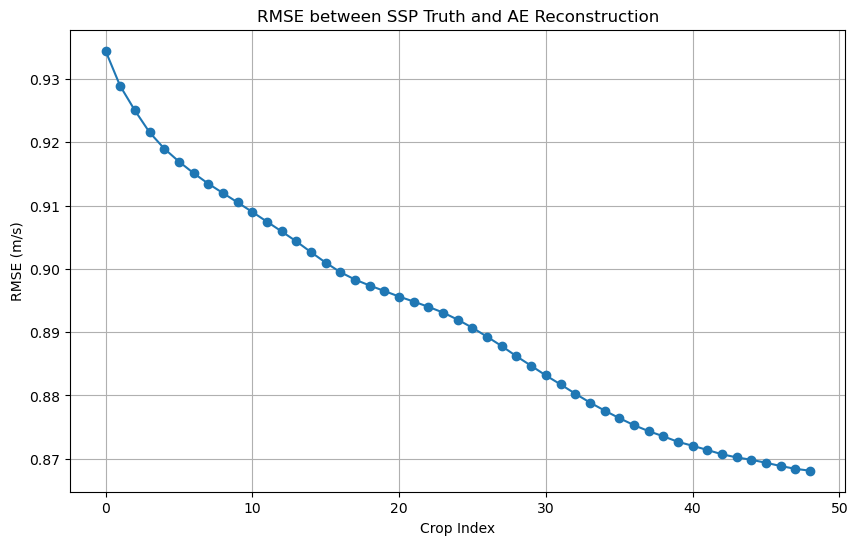

In [22]:


rmse_list = []
for i in tqdm(range(1,50,1)):
    slice_crop = slice(i, -i)
    ssp_truth_crop = ssp_truth_da.isel(lat=slice_crop, lon=slice_crop)
    ssp_ae_crop = ssp_ae_da.isel(lat=slice_crop, lon=slice_crop)
    rmse = np.sqrt(np.mean((ssp_truth_crop - ssp_ae_crop) ** 2))
    rmse_list.append(rmse)

plt.figure(figsize=(10,6))
plt.plot(rmse_list, marker='o')
plt.title('RMSE between SSP Truth and AE Reconstruction')
plt.xlabel('Crop Index')
plt.ylabel('RMSE (m/s)')
plt.grid()
plt.show()

100%|██████████| 49/49 [01:45<00:00,  2.15s/it]


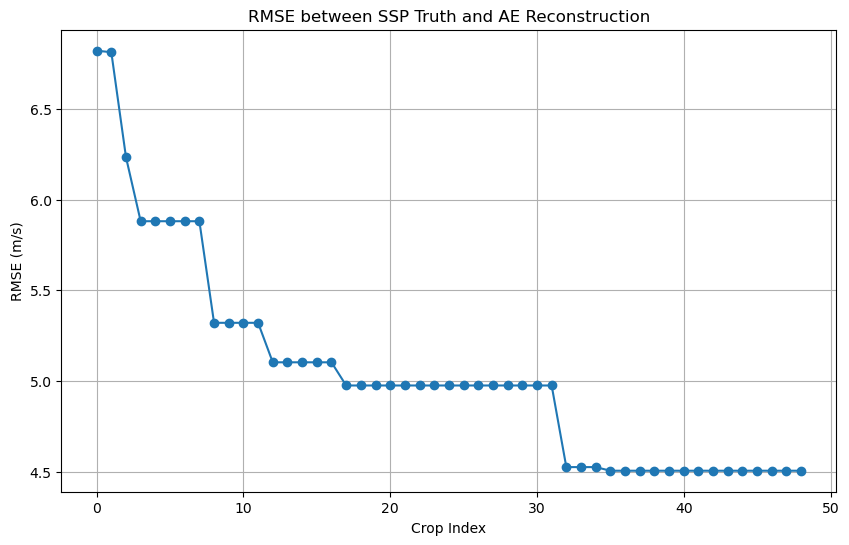

In [23]:


max_rmse_list = []
for i in tqdm(range(1,50,1)):
    slice_crop = slice(i, -i)
    ssp_truth_crop = ssp_truth_da.isel(lat=slice_crop, lon=slice_crop)
    ssp_ae_crop = ssp_ae_da.isel(lat=slice_crop, lon=slice_crop)
    rmse = np.sqrt(np.mean((ssp_truth_crop - ssp_ae_crop) ** 2,axis=1)).max()
    max_rmse_list.append(rmse)

plt.figure(figsize=(10,6))
plt.plot(max_rmse_list, marker='o')
plt.title('RMSE between SSP Truth and AE Reconstruction')
plt.xlabel('Crop Index')
plt.ylabel('RMSE (m/s)')
plt.grid()
plt.show()

In [23]:
crop_idx = slice(20,-20)


ssp_truth_da = ssp_truth_da.isel(lat=crop_idx,lon=crop_idx)

In [ ]:

ssp_ae_da = ssp_ae_da.isel(lat=crop_idx,lon=crop_idx)


rmse_z = np.sqrt(((ssp_ae_da - ssp_truth_da) ** 2).mean(dim="z", skipna=True))


ssp_truth_std = ssp_truth_da.std(dim="z", skipna=True)


ssp_truth = ssp_truth_da.data
ssp_ae = ssp_ae_da.data

In [24]:
ssp_train = dm.train_ds.input
ssp_train = unorm_ssp_arr_3D(ssp_train, ssp_train.attrs['norm_stats']).isel(lat=crop_idx,lon=crop_idx).data

In [ ]:


# Flatten rmse_z and get valid (non-NaN) values with indices
rmse_flat = rmse_z.values.ravel()
valid_mask = np.isfinite(rmse_flat)
valid_values = rmse_flat[valid_mask]
valid_indices = np.where(valid_mask)[0]

# Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
percentiles = np.linspace(0, 100, 11)
thresholds = np.percentile(valid_values, percentiles)

# For each threshold, find the closest actual data point
selected_flat_indices = []
for thresh in thresholds:
    idx_in_valid = np.argmin(np.abs(valid_values - thresh))
    selected_flat_indices.append(valid_indices[idx_in_valid])

# Convert flat indices back to multi-dimensional coordinates
shape = rmse_z.shape
dim_names = rmse_z.dims
selected_points = []

for i, flat_idx in enumerate(selected_flat_indices):
    multi_idx = np.unravel_index(flat_idx, shape)
    point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
    point['rmse_value'] = rmse_flat[flat_idx]
    point['percentile'] = percentiles[i]
    selected_points.append(point)

# Display results
df_deciles = pd.DataFrame(selected_points)
print(df_deciles)

: 

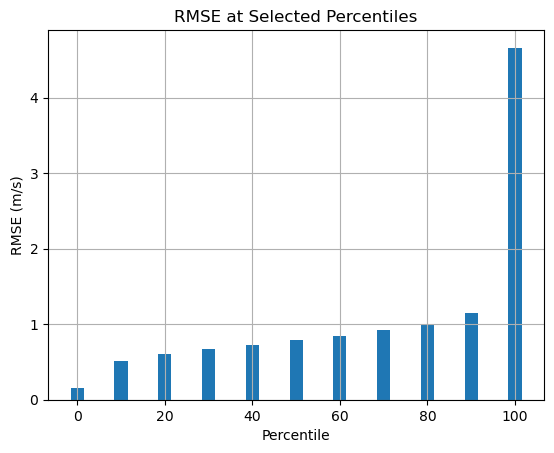

In [85]:
plt.bar(percentiles, df_deciles['rmse_value'], width=3)
plt.title('RMSE at Selected Percentiles')
plt.xlabel('Percentile')
plt.ylabel('RMSE (m/s)')
plt.grid()
plt.show()

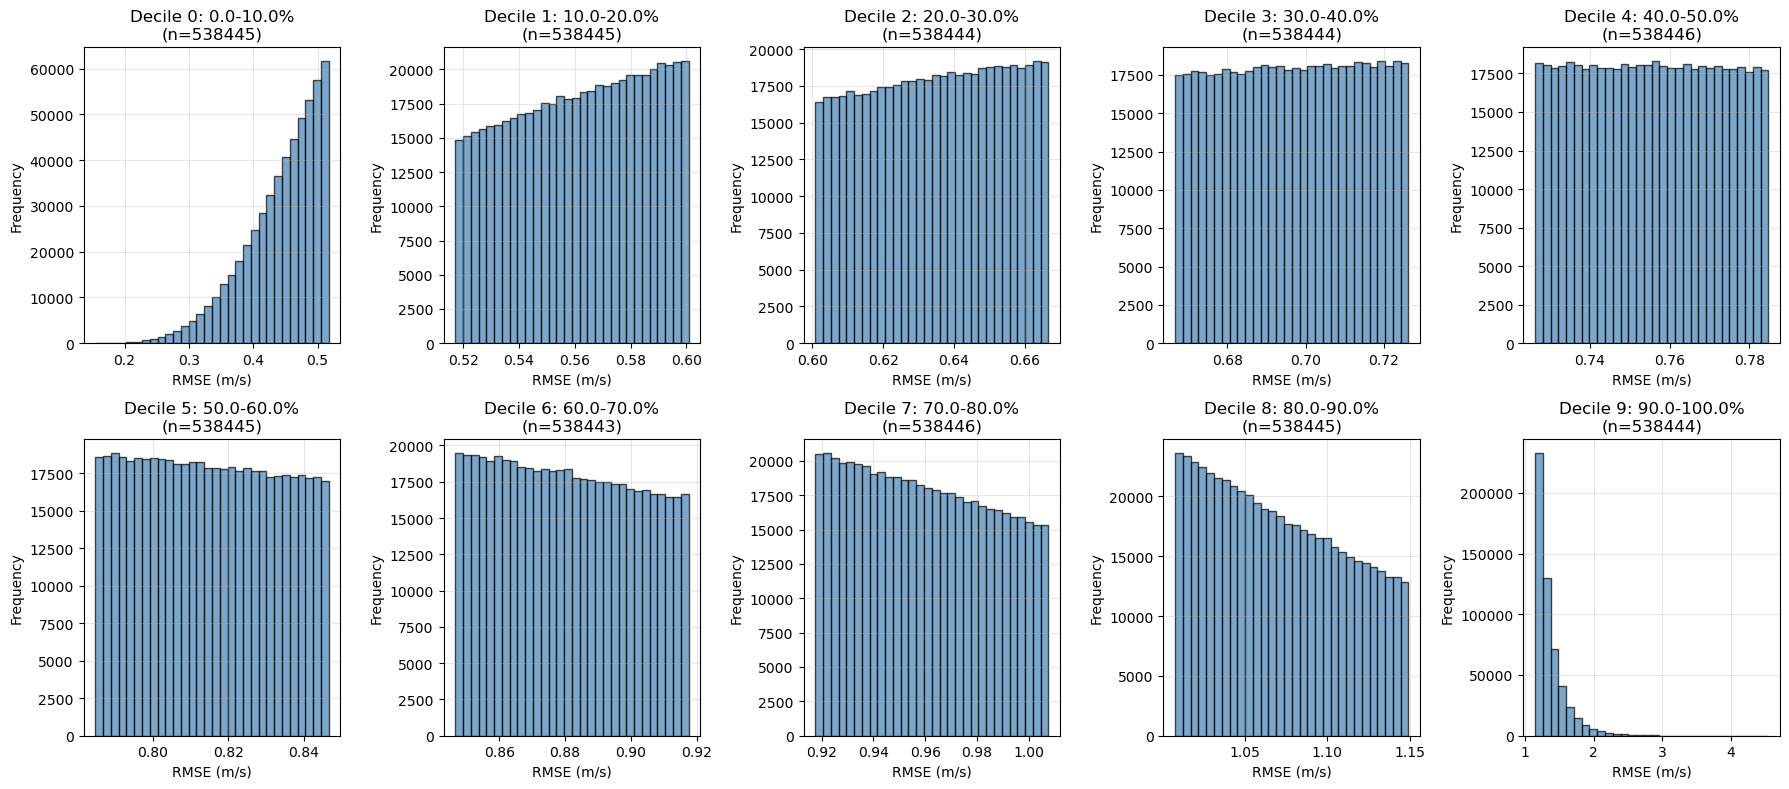


=== RMSE Summary Statistics by Decile ===
Decile 0 (0.0-10.0%): min=0.1546, max=0.5172, mean=0.4429, std=0.0581
Decile 1 (10.0-20.0%): min=0.5172, max=0.6008, mean=0.5613, std=0.0240
Decile 2 (20.0-30.0%): min=0.6008, max=0.6667, mean=0.6346, std=0.0190
Decile 3 (30.0-40.0%): min=0.6667, max=0.7262, mean=0.6967, std=0.0172
Decile 4 (40.0-50.0%): min=0.7262, max=0.7848, mean=0.7554, std=0.0169
Decile 5 (50.0-60.0%): min=0.7848, max=0.8466, mean=0.8152, std=0.0178
Decile 6 (60.0-70.0%): min=0.8466, max=0.9175, mean=0.8810, std=0.0204
Decile 7 (70.0-80.0%): min=0.9175, max=1.0076, mean=0.9602, std=0.0259
Decile 8 (80.0-90.0%): min=1.0076, max=1.1492, mean=1.0709, std=0.0404
Decile 9 (90.0-100.0%): min=1.1492, max=4.5389, mean=1.3616, std=0.2332


In [86]:
# Create histograms for RMSE by deciles
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for i in range(len(percentiles) - 1):
    lower_perc = percentiles[i]
    upper_perc = percentiles[i + 1]
    
    # Get RMSE values in this decile range
    mask = (rmse_flat >= thresholds[i]) & (rmse_flat < thresholds[i + 1])
    decile_rmse = rmse_flat[mask]
    
    # Plot histogram
    axes[i].hist(decile_rmse, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Decile {i}: {lower_perc:.1f}-{upper_perc:.1f}%\n(n={len(decile_rmse)})')
    axes[i].set_xlabel('RMSE (m/s)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics per decile
print("\n=== RMSE Summary Statistics by Decile ===")
for i in range(len(percentiles) - 1):
    mask = (rmse_flat >= thresholds[i]) & (rmse_flat < thresholds[i + 1])
    decile_rmse = rmse_flat[mask]
    print(f"Decile {i} ({percentiles[i]:.1f}-{percentiles[i+1]:.1f}%): "
          f"min={decile_rmse.min():.4f}, max={decile_rmse.max():.4f}, "
          f"mean={decile_rmse.mean():.4f}, std={decile_rmse.std():.4f}")

In [87]:


# All indices where rmse-score is above or equal to a threshold
rmse_threshold = 1
rmse_flat = np.asarray(rmse_z).ravel()
rmse_valid_mask = np.isfinite(rmse_flat)

# Keep every valid point with high rmse
high_rmse_mask = rmse_valid_mask & (rmse_flat >= rmse_threshold)
high_flat_idx_rmse = np.where(high_rmse_mask)[0]
high_multi_idx_rmse = np.array(np.unravel_index(high_flat_idx_rmse, np.asarray(rmse_z).shape)).T

# Build a table with indices + values (+ coordinates if shape matches rmse_z: time, lat, lon)
high_rmse_points = []
for flat_idx, multi_idx in zip(high_flat_idx_rmse, high_multi_idx_rmse):
    row = {
        "rmse_value": float(rmse_flat[flat_idx]),
    }

    if np.asarray(rmse_z).shape == rmse_z.shape and len(multi_idx) == 3:
        t_i, lat_i, lon_i = map(int, multi_idx)
        row.update({
            "time_idx": t_i,
            "lat_idx": lat_i,
            "lon_idx": lon_i,
        })

    high_rmse_points.append(row)

df_high_rmse = pd.DataFrame(high_rmse_points).sort_values("rmse_value", ascending=False)
print(f"Number of points with rmse >= {rmse_threshold}: {len(df_high_rmse)}")
df_high_rmse

Number of points with rmse >= 1: 1115658


,rmse_value,time_idx,lat_idx,lon_idx
461886,4.661482,86,143,91
452667,4.538862,85,144,90
452666,4.520017,85,144,89
452540,4.444864,85,143,90
461885,4.369940,86,143,90
...,...,...,...,...
798128,1.000001,126,39,59
987049,1.000001,148,65,63
741744,1.000000,119,130,140
970814,1.000000,145,138,208


In [31]:
rmse = np.sqrt(np.mean((ssp_truth - ssp_ae)**2))


min_max_idx_truth = get_min_max_idx(ssp_truth, axs=1, pad=False)
min_max_idx_ae = get_min_max_idx(ssp_ae, axs=1, pad=False)
F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10)
f1_score = np.mean(F1_score)

b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
filt_ae = filtfilt(b, a, ssp_ae, axis=1).astype(ssp_ae_da.dtype)

filt_rmse = np.sqrt(np.mean((ssp_truth - filt_ae)**2))

min_max_idx_ae = get_min_max_idx(filt_ae, axs=1, pad=False)
filt_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10)
filt_f1_score = np.mean(filt_F1_score)

In [32]:
print(f"Model: {k} \n CR:{cr} \n RMSE: {rmse:.4f} \n F1 Score: {f1_score:.4f} \n Filtered RMSE: {filt_rmse:.4f} \n Filtered F1 Score: {filt_f1_score:.4f}")

Model: test_enatl_natl_mean_std_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260323_191653_best_checkpoint_ecs 
 CR:12939.941407116821 
 RMSE: 0.8964 
 F1 Score: 0.7580 
 Filtered RMSE: 0.8854 
 Filtered F1 Score: 0.7294


In [103]:
f1_da = xr.DataArray(F1_score, coords=rmse_z.coords, dims=rmse_z.dims)
f1_da

<xarray.DataArray (time: 164, lat: 152, lon: 216)> Size: 43MB
array([[[0.32      , 0.26666667, 0.4       , ..., 0.5       ,
         0.625     , 0.63636364],
        [0.57142857, 0.60869565, 0.36363636, ..., 0.5       ,
         0.7       , 0.75      ],
        [0.625     , 0.61538462, 0.48      , ..., 0.81818182,
         0.57142857, 0.7       ],
        ...,
        [0.51612903, 0.69565217, 0.48      , ..., 0.625     ,
         0.62857143, 0.34782609],
        [0.5       , 0.61538462, 0.5       , ..., 0.28571429,
         0.27272727, 0.57142857],
        [0.52173913, 0.44444444, 0.5       , ..., 0.0952381 ,
         0.43478261, 0.48      ]],

       [[0.27272727, 0.4       , 0.4       , ..., 0.19047619,
         0.52173913, 0.26666667],
        [0.44444444, 0.72727273, 0.36363636, ..., 0.69230769,
         0.38095238, 0.42857143],
        [0.25      , 0.26666667, 0.57142857, ..., 0.42857143,
         0.14285714, 0.375     ],
...
        [0.57142857, 0.54545455, 0.72727273, ..., 0.47058824,
         0.4       , 0.47619048],
        [0.28571429, 0.46153846, 0.66666667, ..., 0.55555556,
         0.4       , 0.47619048],
        [0.76923077, 0.73684211, 0.28571429, ..., 0.5       ,
         0.4       , 0.46153846]],

       [[0.58823529, 0.18181818, 0.42857143, ..., 0.93333333,
         0.66666667, 0.52631579],
        [0.22222222, 0.18181818, 0.22222222, ..., 0.93333333,
         0.88888889, 0.52631579],
        [0.18181818, 0.63157895, 0.46153846, ..., 0.92307692,
         0.9       , 0.76190476],
        ...,
        [0.5       , 0.75      , 0.8       , ..., 0.15384615,
         0.35294118, 0.28571429],
        [0.46153846, 0.6       , 0.8       , ..., 0.47619048,
         0.5       , 0.47619048],
        [0.46153846, 0.56      , 0.54545455, ..., 0.        ,
         0.31578947, 0.35294118]]], shape=(164, 152, 216))
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-03-21T12:00:00 ... 2013-09-30T12:...
  * lat      (lat) float64 1kB 33.5 33.54 33.58 33.63 ... 40.17 40.21 40.25
  * lon      (lon) float64 2kB -65.01 -64.97 -64.92 ... -55.03 -54.98 -54.94

In [104]:

flat_f1 = filt_F1_score.reshape(-1)
best_idx = np.argmax(flat_f1)
worst_idx = np.argmin(flat_f1)

def unravel(idx):
    return np.unravel_index(idx, filt_F1_score.shape)

unravel_best = unravel(best_idx)
unravel_worst = unravel(worst_idx)

print(f"Best F1 Score at index {unravel_best} with value {filt_F1_score[unravel_best]:.4f}")
print(f"Worst F1 Score at index {unravel_worst} with value {filt_F1_score[unravel_worst]:.4f}")


Best F1 Score at index (np.int64(0), np.int64(0), np.int64(102)) with value 1.0000
Worst F1 Score at index (np.int64(0), np.int64(5), np.int64(118)) with value 0.0000


In [105]:
flat_rmse = np.sqrt(np.mean((ssp_truth - filt_ae)**2, axis=1)).reshape(-1)
best_idx_rmse = np.argmin(flat_rmse)
worst_idx_rmse = np.argmax(flat_rmse)
unravel_best_rmse = unravel(best_idx_rmse)
unravel_worst_rmse = unravel(worst_idx_rmse)

print(f"Best RMSE at index {unravel_best_rmse} with value {flat_rmse[best_idx_rmse]:.4f}")
print(f"Worst RMSE at index {unravel_worst_rmse} with value {flat_rmse[worst_idx_rmse]:.4f}")

Best RMSE at index (np.int64(57), np.int64(55), np.int64(149)) with value 0.1347
Worst RMSE at index (np.int64(86), np.int64(143), np.int64(90)) with value 5.2359


# Gradient analysis

In [78]:
rmse = np.sqrt(np.mean((ssp_truth - ssp_ae)**2))


min_max_idx_truth = get_min_max_idx(ssp_truth, axs=1, pad=False)
min_max_idx_ae = get_min_max_idx(ssp_ae, axs=1, pad=False)
F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10)
f1_score = np.mean(F1_score)


In [ ]:
ssp_truth_filt = ssp_da.data
ssp_truth_filt = unorm_ssp_arr_3D(ssp_truth_filt, ssp_da.attrs['norm_stats'])

b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
ssp_truth_filt = filtfilt(b, a, ssp_truth_filt, axis=1).astype(ssp_da.dtype)

net = MLICPlusPlus(config=ssp_config).eval().to(device)
ck = torch.load(ckpt_file, map_location=device)

net.load_state_dict(ck['state_dict'])


test_norm = ck.get('train_norm_stats', None)

#test_norm_method =   #test_norm['method']
test_norm['method'] = ck.get('train_norm_stats', None)['method']
#test_norm_method = "mean_std" #"mean_std_along_depth" #"mean_std"


if test_norm['method'] == "min_max":
    x_min = test_norm["params"]["x_min"].astype(ssp_truth.dtype)
    x_max = test_norm["params"]["x_max"].astype(ssp_truth.dtype)    
    ssp_truth_tens_filt = (ssp_truth_filt - x_min) / (x_max - x_min)
elif test_norm['method'] == "mean_std":
    mean = test_norm['params']["mean"].astype(ssp_truth.dtype)
    std = test_norm['params']["std"].astype(ssp_truth.dtype)
    ssp_truth_tens_filt = (ssp_truth_filt - mean) / std
elif test_norm['method'] == "mean_std_along_depth":
    mean = test_norm['params']["mean_along_depth"].astype(ssp_truth.dtype)
    std = test_norm['params']["std_along_depth"].astype(ssp_truth.dtype)
    ssp_truth_tens_filt = (ssp_truth_filt - mean) / std

In [85]:


ssp_truth_tens_filt = torch.tensor(ssp_truth_filt).to(device=device, dtype=getattr(torch,dm.dtype_str))

with torch.no_grad():
    rv_batch = net(ssp_truth_tens_filt, season_idx, sst_test_norm)

ssp_ae_filt = rv_batch['x_hat'].detach().cpu().numpy()

ssp_ae_filt = unorm_ssp_arr_3D(ssp_ae_filt, test_norm)
#ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)

bits = compute_total_bits(rv_batch)
total_original_bits = rv_batch['x_hat'].numel() * rv_batch['x_hat'].element_size() * 8

cr = total_original_bits / bits


In [88]:
ssp_truth_filt_da = ssp_da.copy(data=ssp_truth_filt)
ssp_ae_filt_da = ssp_da.copy(data=ssp_ae_filt)

crop_idx = slice(20,-20)


ssp_truth_filt_da = ssp_truth_filt_da.isel(lat=crop_idx,lon=crop_idx)
ssp_ae_filt_da = ssp_ae_filt_da.isel(lat=crop_idx,lon=crop_idx)


rmse_filt = np.sqrt(np.mean((ssp_truth_filt_da - ssp_ae_filt_da)**2))

ssp_truth_filt = ssp_truth_filt_da.data
ssp_ae_filt = ssp_ae_filt_da.data

In [96]:
min_max_idx_filt_truth = get_min_max_idx(ssp_truth_filt, axs=1, pad=False)
min_max_idx_filt_ae = get_min_max_idx(ssp_ae_filt, axs=1, pad=False)

filt_F1_score = get_f1_score(min_max_idx_filt_truth, min_max_idx_filt_ae, axs=1, kernel_size=10)
filt_f1_score = np.mean(filt_F1_score)

In [90]:
print(f"Model: {k} \n CR:{cr} \n RMSE: {rmse:.4f} \n F1 Score: {f1_score:.4f} \n Filtered RMSE: {filt_rmse:.4f} \n Filtered F1 Score: {filt_f1_score:.4f}")

Model: test_enatl_natl_mean_std_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260323_191653_best_checkpoint_ecs 
 CR:483.49310929146816 
 RMSE: 0.8964 
 F1 Score: 0.7580 
 Filtered RMSE: 0.8854 
 Filtered F1 Score: 0.4159


In [93]:
dssp_dz_truth = ssp_truth_da.differentiate("z")
dssp_dz_ae = ssp_ae_da.differentiate("z")

dssp_dz_filt_truth = ssp_truth_filt_da.differentiate("z")
dssp_dz_filt_ae = ssp_ae_filt_da.differentiate("z")

# gradient_error_da = dssp_dz_ae - dssp_dz_truth
# gradient_rmse_da = np.sqrt((gradient_error_da ** 2).mean(dim="z", skipna=True))

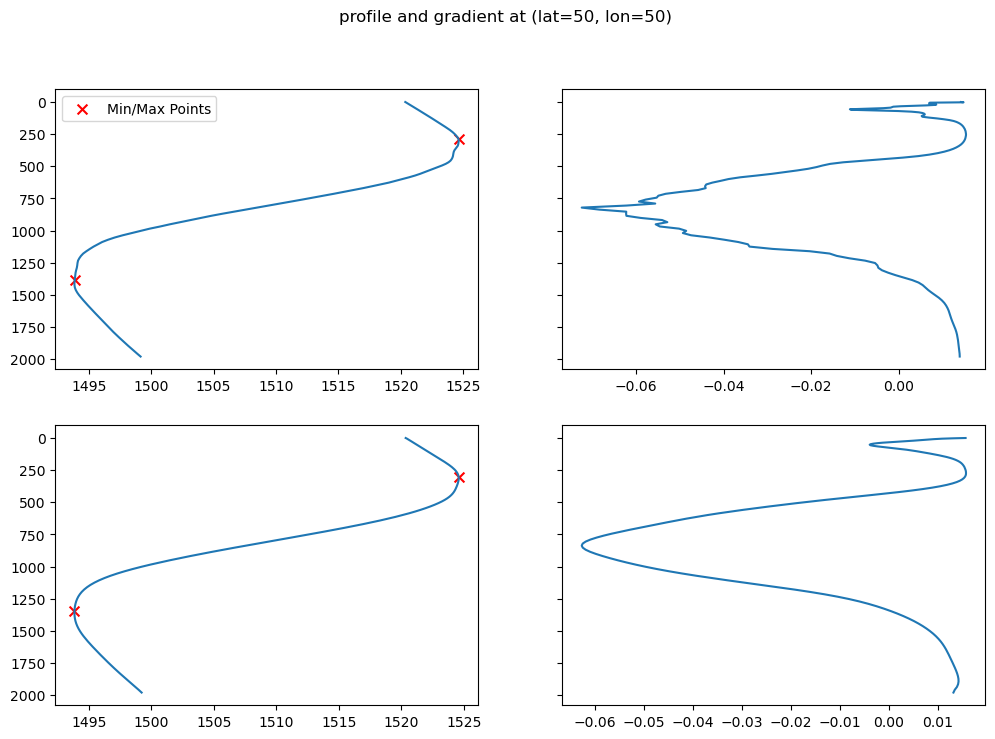

In [97]:
idx_truth = np.where(min_max_idx_truth[0,:,50,50] != 0)[0]
idx_truth_filt = np.where(min_max_idx_filt_truth[0,:,50,50] != 0)[0]

f,axs=plt.subplots(2,2,sharey=True, figsize=(12,8))
axs[0,0].plot(ssp_truth[0, :, 50, 50],depth_array)
axs[0,0].scatter(ssp_truth[0, idx_truth, 50, 50] , depth_array[idx_truth], s=50, marker='x', color='red', label='Min/Max Points')
axs[0,1].plot(dssp_dz_truth[50, :, 50, 50],depth_array)

axs[1,0].plot(ssp_truth_filt[0, :, 50, 50],depth_array)
axs[1,0].scatter(ssp_truth_filt[0, idx_truth_filt, 50, 50] , depth_array[idx_truth_filt], s=50, marker='x', color='red', label='Min/Max Points')
axs[1,1].plot(dssp_dz_filt_truth[50, :, 50, 50],depth_array)
f.gca().invert_yaxis()
f.suptitle("profile and gradient at (lat=50, lon=50)")
axs[0,0].legend()

Text(0.5, 0.98, 'profile and gradient at (lat=50, lon=50)')

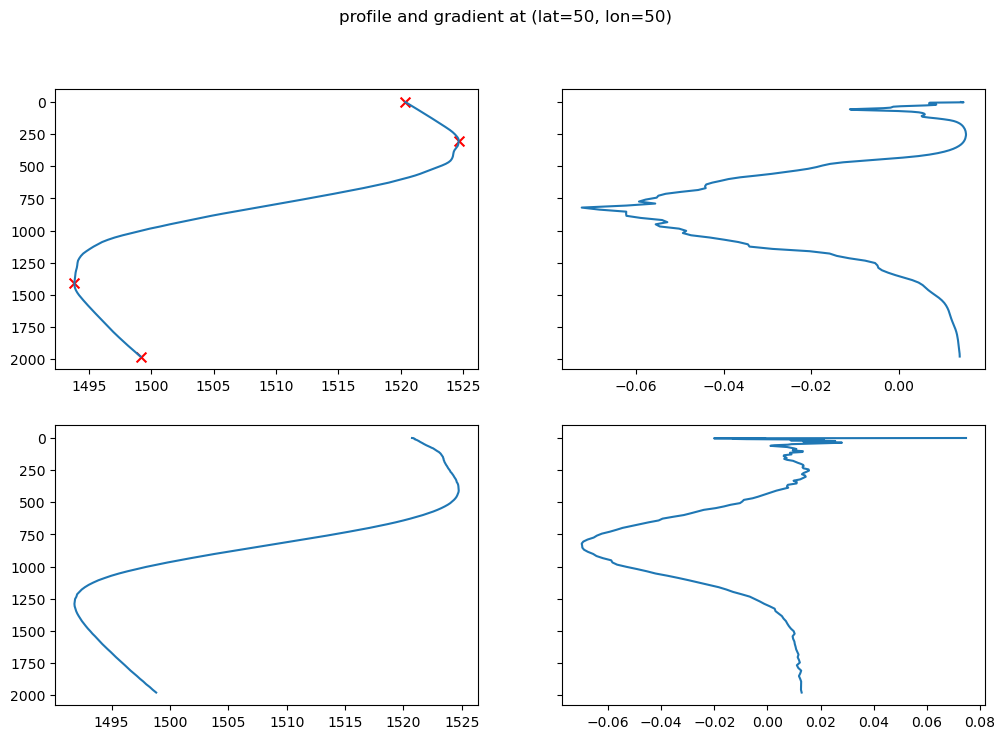

In [ ]:
idx_truth = np.where(min_max_idx_truth[0,:,50,50] != 0)[0]

f,axs=plt.subplots(2,2,sharey=True, figsize=(12,8))
axs[0,0].plot(ssp_truth[0, :, 50, 50],depth_array)
axs[0,0].scatter(ssp_truth[0, idx_truth, 50, 50] , depth_array[idx_truth], s=50, marker='x', color='red', label='Min/Max Points')

axs[0,1].plot(dssp_dz_truth[50, :, 50, 50],depth_array)
axs[1,0].plot(truth_filt_da[0, :, 50, 50],depth_array)
axs[1,1].plot(dssp_dz_ae[50, :, 50, 50],depth_array)
f.gca().invert_yaxis()
f.suptitle("profile and gradient at (lat=50, lon=50)")

In [34]:
dssp_dz_truth.shape

(164, 157, 152, 216)

In [ ]:
rmse = np.sqrt(np.mean((ssp_truth - ssp_ae)**2))


min_max_idx_truth = get_min_max_idx(ssp_truth, axs=1, pad=False)
min_max_idx_ae = get_min_max_idx(ssp_ae, axs=1, pad=False)
F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10)
f1_score = np.mean(F1_score)

b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
filt_ae = filtfilt(b, a, ssp_ae, axis=1).astype(ssp_ae_da.dtype)

filt_rmse = np.sqrt(np.mean((ssp_truth - filt_ae)**2))

min_max_idx_ae = get_min_max_idx(filt_ae, axs=1, pad=False)
filt_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10)
filt_f1_score = np.mean(filt_F1_score)

In [ ]:
print(f"Model: {k} \n CR:{cr} \n RMSE: {rmse:.4f} \n F1 Score: {f1_score:.4f} \n Filtered RMSE: {filt_rmse:.4f} \n Filtered F1 Score: {filt_f1_score:.4f}")

Model: test_enatl_natl_mean_std_fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std_20260323_191653_best_checkpoint_ecs 
 CR:12939.941407116821 
 RMSE: 0.8964 
 F1 Score: 0.7580 
 Filtered RMSE: 0.8854 
 Filtered F1 Score: 0.7294


## RMSE/Std

In [27]:
ssp_truth_std.shape, rmse_z.shape

((164, 152, 216), (164, 152, 216))

/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


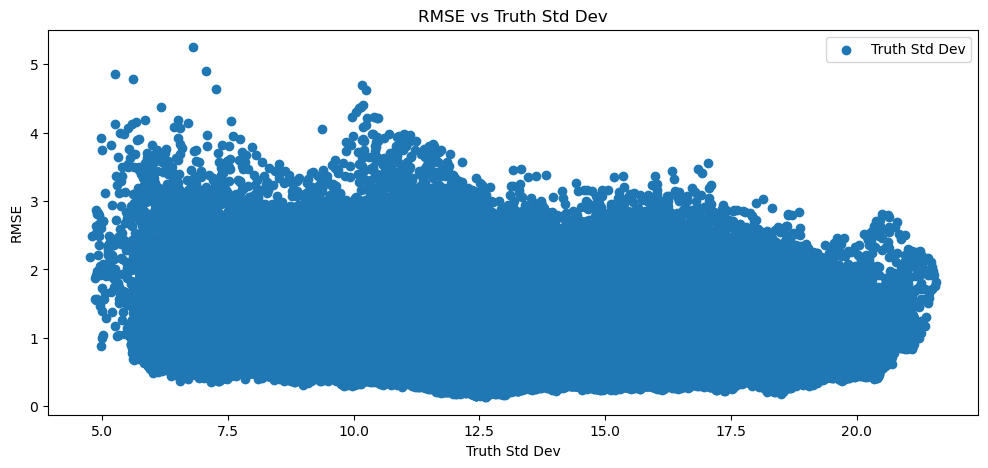

In [28]:
plt.figure(figsize=(12, 5))
plt.scatter(ssp_truth_std.data.ravel(), rmse_z.data.ravel(), label="Truth Std Dev")
plt.xlabel("Truth Std Dev")
plt.ylabel("RMSE")
plt.title("RMSE vs Truth Std Dev")
plt.legend()
plt.show()

# extermum idx

In [38]:

# Get extrema masks
ext_truth = get_min_max_idx(ssp_truth, axs=1, pad=True).astype(bool)
ext_recon = get_min_max_idx(ssp_ae, axs=1, pad=True).astype(bool)


# Convert masks into depth-valued masks
truth_depth_masked = ext_truth * depth_array[None,:,None,None]
recon_depth_masked = ext_recon * depth_array[None,:,None,None]

# Sum of extremum depths for each profile
truth_ext_depth_sum = truth_depth_masked.sum(axis=1)
recon_ext_depth_sum = recon_depth_masked.sum(axis=1)

# Difference in meters
depth_diff = abs(recon_ext_depth_sum - truth_ext_depth_sum)

# Put into DataArray
depth_diff_da = xr.DataArray(
    depth_diff,
    dims=('time','lat','lon'),
    coords={
        'time': ssp_truth_da.time,
        'lat': ssp_truth_da.lat,
        'lon': ssp_truth_da.lon
    },
    name='extremum_depth_difference'
)

In [42]:
truth_depth_masked

array([[[[4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01],
         [4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01],
         [4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01],
         ...,
         [4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01],
         [4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01],
         [4.80454775e-01, 4.80454775e-01, 4.80454775e-01, ...,
          4.80454775e-01, 4.80454775e-01, 4.80454775e-01]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 1.55879158e+00, 1.55879158e+00],
        

In [47]:
from scipy.spatial.distance import cdist

truth_mask = ext_truth[0, :, 0, 0]   # shape (depth,)
recon_mask = ext_recon[0, :, 0, 0]   # shape (depth,)

# Get depth indices of extrema
truth_idx = np.where(truth_mask)[0]
recon_idx = np.where(recon_mask)[0]

truth_depths = depth_array[truth_idx][:,None]
recon_depths = depth_array[recon_idx][:,None]

print("Truth extremum depths:", truth_depths.flatten())
print("Reconstructed extremum depths:", recon_depths.flatten())

D = cdist(truth_depths, recon_depths)

nearest_error = D.min(axis=1)   # error per truth extremum
mean_error = nearest_error.mean()

mean_error 

Truth extremum depths: [4.80454775e-01 3.86812942e+02 1.34685126e+03 1.97989642e+03]
Reconstructed extremum depths: [4.80454775e-01 1.55879158e+00 2.79421042e+00 4.21237901e+02
 1.27123182e+03 1.97989642e+03]


np.float64(27.511099046836094)

In [49]:
import numpy as np
import xarray as xr
from scipy.spatial.distance import cdist
from joblib import Parallel, delayed
from tqdm import tqdm

# Compute extrema masks
ext_truth = get_min_max_idx(ssp_truth, axs=1, pad=False).astype(bool)
ext_ae = get_min_max_idx(ssp_ae, axs=1, pad=False).astype(bool)

# Flatten exactly like your DTW code
flat_truth_ext = ext_truth.transpose(0,2,3,1).reshape(-1, ext_truth.shape[1])
flat_ae_ext = ext_ae.transpose(0,2,3,1).reshape(-1, ext_ae.shape[1])

depth = depth_array


def extremum_position_error(profile_idx):

    truth_idx = np.where(flat_truth_ext[profile_idx])[0]
    ae_idx = np.where(flat_ae_ext[profile_idx])[0]

    if len(truth_idx) == 0 or len(ae_idx) == 0:
        return np.nan

    D = cdist(
        depth[truth_idx][:,None],
        depth[ae_idx][:,None]
    )

    return D.min(axis=1).mean()


# Parallel computation
error_arr = Parallel(n_jobs=-1)(
    delayed(extremum_position_error)(prof)
    for prof in tqdm(range(flat_truth_ext.shape[0]))
)

# Reshape back to original geometry
error_arr = np.array(error_arr).reshape(
    ssp_truth.shape[0],
    ssp_truth.shape[2],
    ssp_truth.shape[3]
)

error_da = xr.DataArray(
    error_arr,
    coords=rmse_z.coords,
    dims=rmse_z.dims,
    name="extremum_position_error_m"
)

error_da

100%|██████████| 5384448/5384448 [00:27<00:00, 193676.75it/s]


<xarray.DataArray 'extremum_position_error_m' (time: 164, lat: 152, lon: 216)> Size: 43MB
array([[[ 54.59553106,  44.8866183 ,  44.8866183 , ..., 151.93989214,
         113.87600832, 111.35854641],
        [ 42.39677012,  40.88605733,  35.22540227, ..., 151.93989214,
         111.21294871, 100.61059956],
        [ 40.88605733,  40.57490858,  45.84583759, ..., 110.94336451,
         116.0879678 , 100.05816454],
        ...,
        [ 28.16443788,  23.98659103,  24.0533324 , ...,  12.06639938,
          51.07790311,  49.4089472 ],
        [ 24.46823745,  20.83473261,  13.43780018, ...,  22.21864529,
          20.14384538,  28.98518934],
        [  0.        ,   3.64953844,  24.40149608, ...,  23.19009654,
          22.14829159,  23.4333672 ]],

       [[ 66.68319296,  66.30020771,  62.32890453, ...,  28.29183208,
          46.05714206,  40.85798501],
        [ 50.35447425,  47.01010524,  55.90283755, ...,  31.48275911,
           9.22841679,  35.31598429],
        [ 52.43788147,  57.78738778,  57.24410223, ...,  26.00708411,
          13.7285637 ,   4.55141903],
...
        [ 37.55762718,  37.55762718,  17.27068838, ...,  26.45158479,
          28.22072924,  30.01688988],
        [ 36.02192865,  28.62499622,  36.02192865, ...,  28.5518708 ,
          19.58397252,  34.53504362],
        [ 43.35163393,  36.02192865,  27.20693663, ...,  19.69330405,
          37.19072564,  25.89933631]],

       [[139.61774157, 182.45300558, 198.81092724, ...,  21.00452978,
          23.08645395,  10.20067647],
        [140.57206142, 140.57206142, 145.21164674, ...,  24.75241047,
          69.55003561,  15.10576306],
        [145.21164674, 145.21164674, 145.21164674, ...,  16.92621898,
          20.22812884,  10.14927033],
        ...,
        [ 35.5666727 ,  28.4245514 ,  16.41165911, ...,  37.19072564,
          28.33215889,  15.21617264],
        [ 36.02192865,  28.62499622,  25.3079676 , ...,  36.77797241,
          32.71202068,  34.53504362],
        [ 36.02192865,  27.20693663,  17.68605643, ...,  34.86933271,
          34.70297515,  34.53504362]]], shape=(164, 152, 216))
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-03-21T12:00:00 ... 2013-09-30T12:...
  * lat      (lat) float64 1kB 33.5 33.54 33.58 33.63 ... 40.17 40.21 40.25
  * lon      (lon) float64 2kB -65.01 -64.97 -64.92 ... -55.03 -54.98 -54.94

# Echelles résolues

In [23]:
from FASCINATION.src.compression_nsr_analysis import *


In [24]:
z_uniform = np.linspace(float(ssp_truth_da.z.min()), float(ssp_truth_da.z.max()), ssp_truth_da.sizes["z"])
ssp_truth_uni = ssp_truth_da.interp(z=z_uniform).data
ssp_ae_uni = ssp_ae_da.interp(z=z_uniform).data

In [30]:
nsr_depth = compute_nsr_along_depth(ssp_truth_da,ssp_ae_da, target_ratio=0.1)

Computing NSR along depth axis...
Non-uniform z-axis detected. Interpolating to uniform grid...
Effective resolution: 25.52 m (at NSR=0.1)


NSR range: 0.0082 to 0.1519


In [26]:
nsr_depth['resolution']

0.0

In [27]:
nsr_map = compute_nsr_spatial_map(ssp_truth_da, ssp_ae_da, target_ratio=0.5)

Computing NSR over spatial (lat/lon) dimensions...
Grid spacing: delta_x=4354.8 m, delta_y=4967.7 m
Effective spatial resolution: 0.0 m (at NSR=0.5)


NSR range: 0.0004 to 0.0127


In [28]:
import geopy.distance
lat,lon = ssp_ae_da.coords['lat'], ssp_ae_da.coords['lon']
geopy.distance.geodesic((lat[0],lon[0]), (lat[-1],lon[-1]),ellipsoid='WGS-84').meters



1168919.615985092

In [29]:
geopy.distance.geodesic((lat[0],lon[0]), (lat[0],lon[1]),ellipsoid='WGS-84').meters

4354.84136081497

In [25]:
def lon_distance_meters(lat, lon1, lon2):
    """
    Compute distance in meters between two longitudes at a given latitude.
    
    Args:
        lat: latitude in degrees
        lon1, lon2: longitudes in degrees
        
    Returns:
        Distance in meters
    """
    R = 6_371_000  # Earth radius in meters
    lat_rad = np.radians(lat)
    dlon_rad = np.radians(lon2 - lon1)
    
    distance = R * np.cos(lat_rad) * np.abs(dlon_rad)
    return distance


In [28]:
compute_nsr_1d_profiles(
    truth_profiles=ssp_truth_uni.transpose(0,2,3,1).reshape(-1, ssp_truth_uni.shape[1]) ,
    reconstructed_profiles=ssp_ae_uni.transpose(0,2,3,1).reshape(-1, ssp_ae_uni.shape[1]) ,
    depth_array=z_uniform,
    delta_x = 1.0,
    nperseg= 128,
) 

(array([0.       , 0.0078125, 0.015625 , 0.0234375, 0.03125  , 0.0390625,
        0.046875 , 0.0546875, 0.0625   , 0.0703125, 0.078125 , 0.0859375,
        0.09375  , 0.1015625, 0.109375 , 0.1171875, 0.125    , 0.1328125,
        0.140625 , 0.1484375, 0.15625  , 0.1640625, 0.171875 , 0.1796875,
        0.1875   , 0.1953125, 0.203125 , 0.2109375, 0.21875  , 0.2265625,
        0.234375 , 0.2421875, 0.25     , 0.2578125, 0.265625 , 0.2734375,
        0.28125  , 0.2890625, 0.296875 , 0.3046875, 0.3125   , 0.3203125,
        0.328125 , 0.3359375, 0.34375  , 0.3515625, 0.359375 , 0.3671875,
        0.375    , 0.3828125, 0.390625 , 0.3984375, 0.40625  , 0.4140625,
        0.421875 , 0.4296875, 0.4375   , 0.4453125, 0.453125 , 0.4609375,
        0.46875  , 0.4765625, 0.484375 , 0.4921875, 0.5      ]),
 array([0.00319762, 0.00376781, 0.00887996, 0.0119898 , 0.00754081,
        0.00702592, 0.00679707, 0.00622584, 0.00609651, 0.00637523,
        0.00680047, 0.00710436, 0.00726781, 0.00731309, 0.0

In [28]:
results = compute_nsr_scores_ssp(
    truth_ssp=ssp_truth_uni.transpose(0,2,3,1),
    reconstructed_ssp=ssp_ae_uni.transpose(0,2,3,1),
    depth_array=z_uniform,  # IMPORTANT: pass depth_array for non-uniform handling
    output_filename=None,
    target_ratio=0.0033,  # NSR threshold for resolution
    method_name=None,# Automatically handles non-uniform sampling (default)
    debug=True
)

INFO:root:Computing NSR scores for SSP data...
INFO:root:Computed delta_x: 12.688564
INFO:root:find_resolution_crossing - target_ratio=0.0033
INFO:root:  NSR range: [0.003233, 0.013610]
INFO:root:  NSR mean: 0.006048, NSR median: 0.005097
INFO:root:  Wavenumber range: [0.000000e+00, 3.940556e-02]
INFO:root:  Number of crossings found: 1
INFO:root:    Crossing 0: idx=0, NSR[0]=0.003233, NSR[1]=0.003822
INFO:root:  Interpolation: wavenumber[0]=0.000000e+00, wavenumber[1]=6.157119e-04
INFO:root:  Result: wavenumber_crossing=5.856124e-10, wavelength=1458550014.400556
INFO:root:Effective resolution: 1458550014.4006 km (at NSR=0.0033)


In [30]:

compute_nsr_2d_field(
    truth_field = ssp_truth_uni.reshape(-1, ssp_truth_uni.shape[2], ssp_truth_uni.shape[3]),
    reconstructed_field = ssp_ae_uni.reshape(-1, ssp_ae_uni.shape[2], ssp_ae_uni.shape[3]),
    delta_x= 1.0,
    delta_y = 1.0,
    nperseg= None,
    axis = -1,
)

In [24]:
compute_nsr_spatial_map(
    truth_field= ssp_truth_uni.reshape(-1, ssp_truth_uni.shape[2], ssp_truth_uni.shape[3]),
    reconstructed_field= ssp_ae_uni.reshape(-1, ssp_ae_uni.shape[2], ssp_ae_uni.shape[3]),
    delta_x= 1.0,
    delta_y= 1.0,
    grid_lat= None,
    grid_lon= None,
    output_filename = None,
    target_ratio = 0.1,
    method_name= '',
    debug=True
)

INFO:root:Computing NSR spatial resolution map...
INFO:root:find_resolution_crossing - target_ratio=0.1
INFO:root:  NSR range: [0.003786, 69.070110]
INFO:root:  NSR mean: 0.502689, NSR median: 0.416311
INFO:root:  Wavenumber range: [0.000000e+00, 5.000000e-01]
INFO:root:  Number of crossings found: 273
INFO:root:    Crossing 0: idx=86, NSR[86]=0.086463, NSR[87]=0.107761
INFO:root:    Crossing 1: idx=94, NSR[94]=0.105621, NSR[95]=0.067201
INFO:root:    Crossing 2: idx=107, NSR[107]=0.078320, NSR[108]=0.100212
INFO:root:    Crossing 3: idx=112, NSR[112]=0.102918, NSR[113]=0.091404
INFO:root:    Crossing 4: idx=185, NSR[185]=0.093038, NSR[186]=0.109595
INFO:root:  Interpolation: wavenumber[12775]=4.961550e-01, wavenumber[12776]=4.961939e-01
INFO:root:  Result: wavenumber_crossing=4.961574e-01, wavelength=2.015489
INFO:root:Mean effective resolution: 2.0155 km (at NSR=0.1)


{'wavenumber': array([0.00000000e+00, 3.88379680e-05, 7.76759360e-05, ...,
        4.99922324e-01, 4.99961162e-01, 5.00000000e-01], shape=(12875,)),
 'wavelength': array([1.00000000e+10, 2.57479337e+04, 1.28739834e+04, ...,
        2.00031075e+00, 2.00015536e+00, 2.00000000e+00], shape=(12875,)),
 'nsr': array([0.00378586, 0.00388821, 0.00427475, ..., 0.22546115, 0.12010009,
        0.12083808], shape=(12875,)),
 'coherence': array([0.99682658, 0.99673041, 0.99621772, ..., 0.80868108, 0.89181743,
        0.89055307], shape=(12875,)),
 'resolution': np.float64(2.0154893365333835),
 'grid_lat': None,
 'grid_lon': None}

## Pearson

In [29]:
pears = pearsonr(ssp_truth.transpose(1,0,2,3).reshape(ssp_truth.shape[1], -1), ssp_ae.transpose(1,0,2,3).reshape(ssp_ae.shape[1], -1))

In [30]:
pears.statistic.min(), pears.statistic.max(), pears.statistic.mean(), pears.statistic.shape

(np.float32(0.8804749),
 np.float32(0.99996746),
 np.float32(0.99868363),
 (5384448,))

In [31]:
pearson_da = xr.DataArray(pears.statistic.reshape(rmse_z.shape), coords=rmse_z.coords, dims=rmse_z.dims)
pearson_da


<xarray.DataArray (time: 164, lat: 152, lon: 216)> Size: 22MB
array([[[0.9990749 , 0.9991068 , 0.9991175 , ..., 0.9992899 ,
         0.9993468 , 0.9993664 ],
        [0.99914354, 0.9992028 , 0.9992293 , ..., 0.999225  ,
         0.9992756 , 0.999299  ],
        [0.9991809 , 0.9992573 , 0.99930215, ..., 0.9991801 ,
         0.99922526, 0.999249  ],
        ...,
        [0.9976947 , 0.9975204 , 0.99721104, ..., 0.998056  ,
         0.99817276, 0.9981023 ],
        [0.99653465, 0.9974358 , 0.9974541 , ..., 0.99652207,
         0.9972533 , 0.99816453],
        [0.9864557 , 0.9945187 , 0.9964337 , ..., 0.99635905,
         0.99812454, 0.9989498 ]],

       [[0.9988908 , 0.99895805, 0.9989924 , ..., 0.9993132 ,
         0.9993522 , 0.99935293],
        [0.9990422 , 0.99912125, 0.99919206, ..., 0.99909246,
         0.9991563 , 0.99917775],
        [0.99916935, 0.99926746, 0.99936426, ..., 0.99891645,
         0.9990502 , 0.99910384],
...
        [0.99639714, 0.9968191 , 0.9973104 , ..., 0.9997565 ,
         0.9995773 , 0.99921834],
        [0.9962339 , 0.9964066 , 0.99670404, ..., 0.9997732 ,
         0.99974614, 0.9995457 ],
        [0.99602735, 0.99618846, 0.9962329 , ..., 0.99972886,
         0.9997614 , 0.99966764]],

       [[0.99864465, 0.9986664 , 0.99867463, ..., 0.99941057,
         0.99944323, 0.99945664],
        [0.9988169 , 0.99888974, 0.9989275 , ..., 0.99944127,
         0.99948627, 0.999495  ],
        [0.99895436, 0.9989975 , 0.9990295 , ..., 0.99943477,
         0.9994572 , 0.9994763 ],
        ...,
        [0.99720895, 0.9976953 , 0.9980946 , ..., 0.9995371 ,
         0.99948174, 0.9992502 ],
        [0.9964322 , 0.9968468 , 0.9975276 , ..., 0.9994546 ,
         0.99944365, 0.99933636],
        [0.9960318 , 0.99633837, 0.9968713 , ..., 0.9993744 ,
         0.9993783 , 0.9993026 ]]], shape=(164, 152, 216), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-03-21T12:00:00 ... 2013-09-30T12:...
  * lat      (lat) float64 1kB 33.5 33.54 33.58 33.63 ... 40.17 40.21 40.25
  * lon      (lon) float64 2kB -65.01 -64.97 -64.92 ... -55.03 -54.98 -54.94

## DTW

In [32]:

from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvisx

def plot_dtw_alignment(x, y, title="DTW Alignment"):
    """
    x, y: 1D numpy arrays
    """

    # Compute DTW
    d, paths = dtw.warping_paths(x, y)
    best_path = dtw.best_path(paths)

    #print(f"DTW distance: {d:.4f}")

    # =========================
    # 1. Plot signals + alignment
    # =========================
    plt.figure(figsize=(10, 6))

    offset = 10 #max(x.min(), y.min())

    plt.plot(x, label="Signal 1")
    plt.plot(y + offset, label="Signal 2 (offset)")

    # draw alignment lines
    for (i, j) in best_path[::len(best_path)//100 + 1]:  # subsample for clarity
        plt.plot([i, j], [x[i], y[j] + offset], color="gray", alpha=0.3)

    plt.title(f"{title} (DTW distance = {d:.3f})")
    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")

    plt.tight_layout()
    plt.show()

    # # =========================
    # # 2. Warping path heatmap
    # # =========================
    # plt.figure(figsize=(6, 6))

    # plt.imshow(paths.T, origin="lower", cmap="viridis", aspect="auto")
    
    # path_i, path_j = zip(*best_path)
    # plt.plot(path_i, path_j, color="red")

    # plt.title("DTW Cost Matrix + Optimal Path")
    # plt.xlabel("Signal 1 index")
    # plt.ylabel("Signal 2 index")

    # plt.colorbar(label="Accumulated cost")
    # plt.tight_layout()
    # plt.show()

    return d, best_path

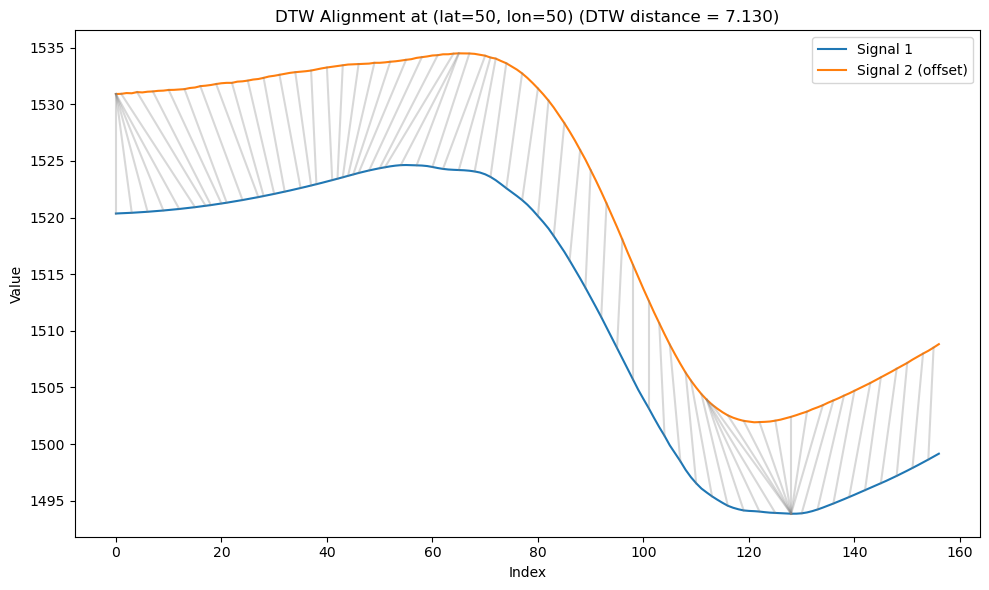

In [33]:
d,best_path = plot_dtw_alignment(ssp_truth[0, :, 50, 50], ssp_ae[0, :, 50, 50], title="DTW Alignment at (lat=50, lon=50)")

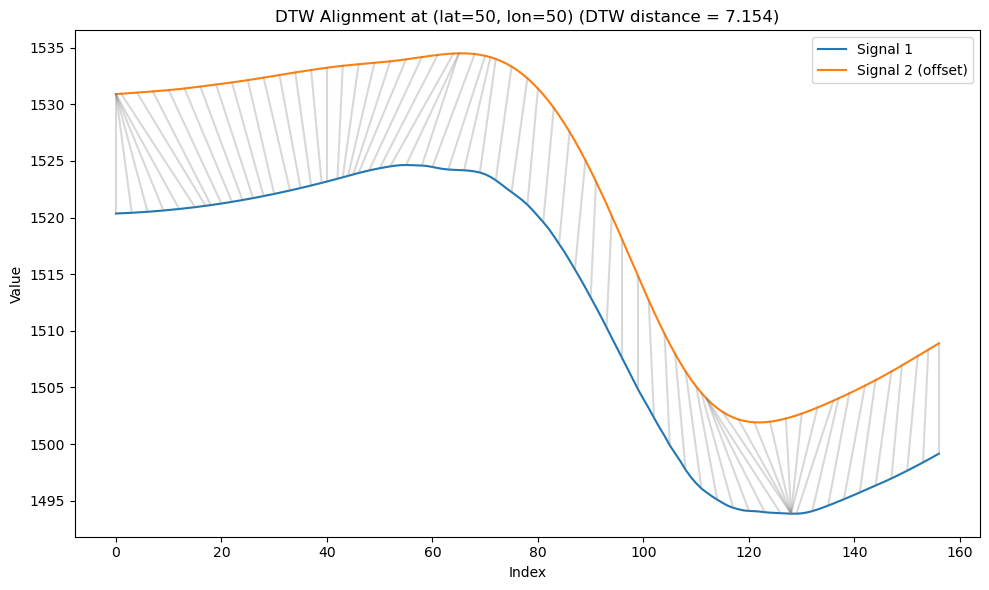

In [34]:
d,best_path = plot_dtw_alignment(ssp_truth[0, :, 50, 50], filt_ae[0, :, 50, 50], title="DTW Alignment at (lat=50, lon=50)")

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

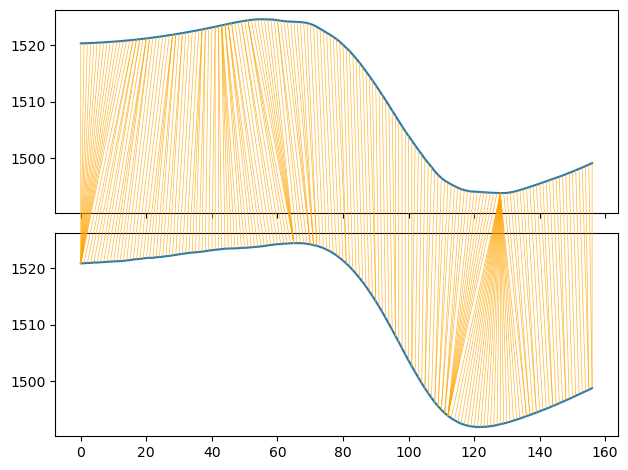

In [35]:
path = dtw.warping_path(ssp_truth[0, :, 50, 50], ssp_ae[0, :, 50, 50])
dtwvisx.plot_warping(ssp_truth[0, :, 50, 50], ssp_ae[0, :, 50, 50],path)

(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

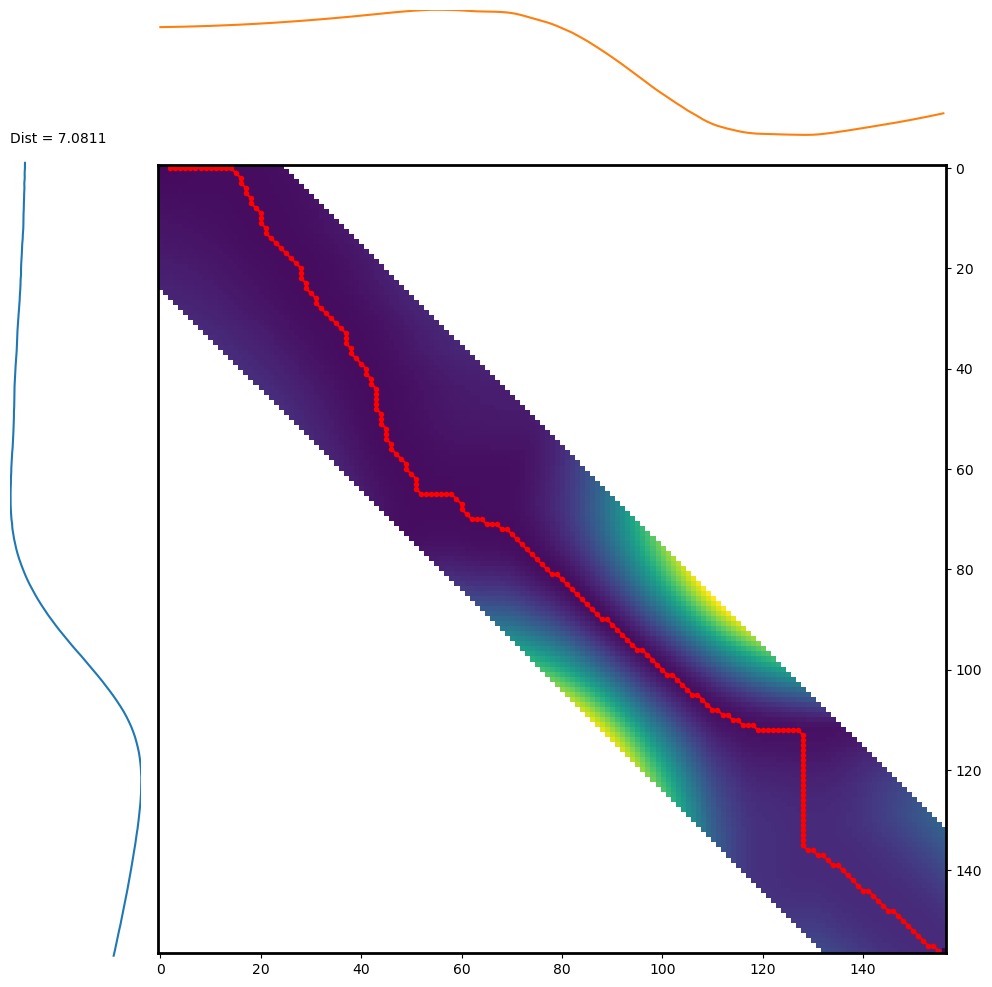

In [36]:
d, paths = dtw.warping_paths(ssp_ae[0, :, 50, 50], ssp_truth[0, :, 50, 50], window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvisx.plot_warpingpaths(ssp_ae[0, :, 50, 50], ssp_truth[0, :, 50, 50], paths)

In [37]:
d, paths = dtw.warping_paths(ssp_ae[0, :, 50, 50], ssp_truth[0, :, 50, 50])
best_path = dtw.best_path(paths)

In [38]:
import os


print("SLURM_CPUS_PER_TASK:", os.environ.get("SLURM_CPUS_PER_TASK"))
print("SLURM_NTASKS:", os.environ.get("SLURM_NTASKS"))
len(os.sched_getaffinity(0))

SLURM_CPUS_PER_TASK: None
SLURM_NTASKS: None


80

In [39]:


flatten_truth = ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1])
flatten_ae = ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1])
dtw_arr = np.zeros(flatten_truth.shape[0])


dtw_arr = Parallel(n_jobs=-1)(
    delayed(dtw.distance)(flatten_ae[prof], flatten_truth[prof]) 
    for prof in tqdm(range(flatten_truth.shape[0]))
)
dtw_arr = np.array(dtw_arr).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3])
dtw_da = xr.DataArray(dtw_arr, coords=rmse_z.coords, dims=rmse_z.dims)
dtw_da

100%|██████████| 5384448/5384448 [39:44<00:00, 2258.04it/s]


<xarray.DataArray (time: 164, lat: 152, lon: 216)> Size: 43MB
array([[[ 4.26371661,  4.49157137,  4.77775835, ...,  1.84545903,
          1.80314253,  1.5988568 ],
        [ 4.20732684,  4.28384744,  4.39074837, ...,  2.16877624,
          1.93690777,  1.6422367 ],
        [ 3.83423149,  3.7767259 ,  3.7529011 , ...,  1.97408673,
          1.82533998,  1.63638113],
        ...,
        [ 4.10140043,  2.71342631,  1.90631685, ...,  3.36241275,
          5.85027777,  9.66489298],
        [ 3.92776812,  3.49278551,  2.66122214, ..., 13.39207894,
         14.01033293, 11.17641202],
        [ 7.82867734,  3.92126168,  2.68386542, ..., 16.48008127,
         10.73267583,  4.52788277]],

       [[ 4.41781808,  4.50664559,  4.69038485, ...,  2.09228328,
          2.0112163 ,  1.87522842],
        [ 4.19497833,  4.16754909,  4.20298069, ...,  1.93131715,
          1.87703016,  1.89134846],
        [ 3.64274136,  3.54051155,  3.48434941, ...,  2.27221993,
          2.29334668,  2.0628797 ],
...
        [ 5.78128299,  8.0080745 , 10.20032915, ...,  4.65206701,
          4.35393313,  4.71049272],
        [ 7.56054057,  8.9193922 , 11.51153119, ...,  4.47629257,
          3.98482951,  4.92886234],
        [10.0983623 , 10.72339336, 12.97360425, ...,  4.06419666,
          3.80389496,  4.24292615]],

       [[ 5.36014313,  5.09402072,  4.92807304, ...,  3.63039654,
          3.78233763,  3.96806726],
        [ 5.32550647,  4.9990367 ,  4.84825388, ...,  3.66355258,
          3.85011249,  4.064371  ],
        [ 5.25952284,  5.31970606,  5.28160302, ...,  3.77187086,
          4.01024151,  4.12567457],
        ...,
        [ 9.57231962, 10.70846874, 10.81368218, ...,  4.96141922,
          4.74221565,  5.52812667],
        [ 8.51082998, 11.15765697, 12.86844683, ...,  5.11206917,
          5.54506875,  6.06915893],
        [ 8.04897291, 11.14761454, 14.16031735, ...,  5.17155119,
          5.81355752,  6.18581236]]], shape=(164, 152, 216))
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-03-21T12:00:00 ... 2013-09-30T12:...
  * lat      (lat) float64 1kB 33.5 33.54 33.58 33.63 ... 40.17 40.21 40.25
  * lon      (lon) float64 2kB -65.01 -64.97 -64.92 ... -55.03 -54.98 -54.94

In [40]:
from fastdtw import fastdtw



flatten_truth = ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1])
flatten_ae = ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1])
dtw_arr = np.zeros(flatten_truth.shape[0])


dtw_arr = Parallel(n_jobs=-1)(
    delayed(fastdtw)(flatten_ae[prof], flatten_truth[prof])[0] 
    for prof in tqdm(range(flatten_truth.shape[0]))
)
dtw_arr = np.array(dtw_arr).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3])
dtw_da = xr.DataArray(dtw_arr, coords=rmse_z.coords, dims=rmse_z.dims)
dtw_da

  0%|          | 0/5384448 [00:00<?, ?it/s]

TypeError: cannot unpack non-iterable function object

In [ ]:
dtw.distance(flatten_ae[prof], flatten_truth[prof]) 

3.258613615997493

In [ ]:
from fastdtw import fastdtw
fastdtw(flatten_ae[prof], flatten_truth[prof],radius=10)  

(np.float64(29.6278076171875),
 [(0, 0),
  (0, 1),
  (0, 2),
  (0, 3),
  (0, 4),
  (0, 5),
  (0, 6),
  (0, 7),
  (0, 8),
  (0, 9),
  (0, 10),
  (0, 11),
  (0, 12),
  (0, 13),
  (0, 14),
  (0, 15),
  (0, 16),
  (0, 17),
  (0, 18),
  (0, 19),
  (1, 20),
  (2, 21),
  (3, 21),
  (4, 21),
  (5, 22),
  (6, 22),
  (7, 22),
  (8, 23),
  (9, 23),
  (10, 24),
  (11, 25),
  (12, 25),
  (13, 25),
  (14, 26),
  (15, 27),
  (16, 28),
  (17, 29),
  (18, 29),
  (19, 30),
  (20, 30),
  (21, 30),
  (22, 31),
  (23, 31),
  (24, 32),
  (25, 33),
  (26, 34),
  (27, 35),
  (28, 35),
  (29, 36),
  (30, 37),
  (31, 37),
  (32, 38),
  (33, 38),
  (34, 39),
  (35, 40),
  (36, 41),
  (37, 41),
  (38, 42),
  (39, 43),
  (40, 44),
  (41, 45),
  (42, 46),
  (43, 47),
  (44, 48),
  (45, 49),
  (46, 50),
  (47, 51),
  (48, 52),
  (49, 53),
  (50, 53),
  (51, 53),
  (52, 53),
  (53, 53),
  (54, 53),
  (55, 53),
  (56, 53),
  (57, 53),
  (58, 53),
  (59, 53),
  (60, 54),
  (61, 55),
  (62, 56),
  (63, 57),
  (64, 58),


### dtw gradient

Text(0.5, 0.98, 'profile and gradient at (lat=50, lon=50)')

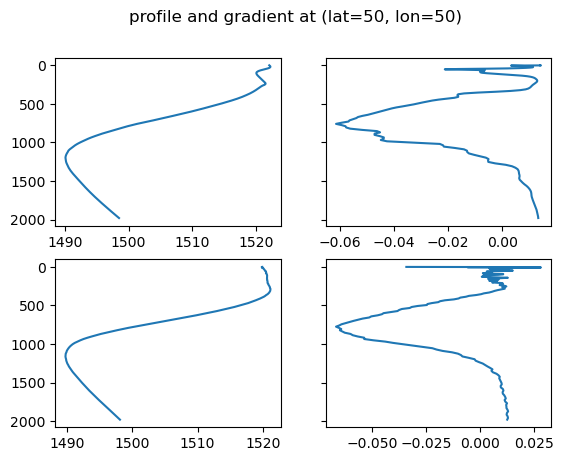

In [ ]:
f,axs=plt.subplots(2,2,sharey=True)
axs[0,0].plot(ssp_truth[0, :, 50, 50],depth_array)
axs[0,1].plot(dssp_dz_truth[50, :, 50, 50],depth_array)
axs[1,0].plot(ssp_ae[0, :, 50, 50],depth_array)
axs[1,1].plot(dssp_dz_ae[50, :, 50, 50],depth_array)
f.gca().invert_yaxis()
f.suptitle("profile and gradient at (lat=50, lon=50)")

Text(0.5, 0.98, 'profile and gradient at (lat=50, lon=50)')

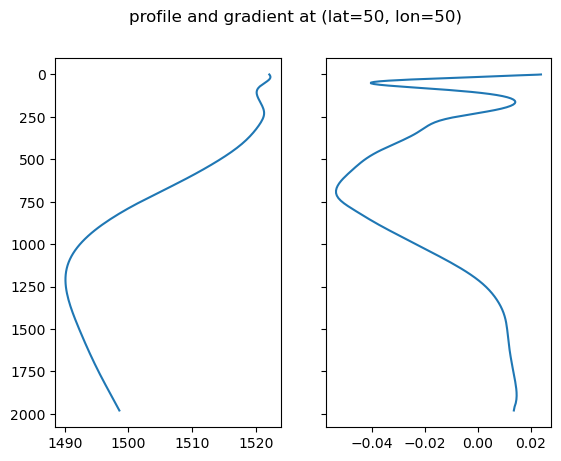

In [ ]:
prof = ssp_truth[0, :, 50, 50]
b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
filt_prof = filtfilt(b, a, prof, axis=0)
grad_prof = np.gradient(filt_prof, depth_array)

f,axs=plt.subplots(1,2,sharey=True)
axs[0].plot(filt_prof,depth_array)
axs[1].plot(grad_prof,depth_array)
f.gca().invert_yaxis()
f.suptitle("profile and gradient at (lat=50, lon=50)")

In [ ]:


flatten_truth = ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1])
flatten_ae = ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1])
dtw_arr = np.zeros(flatten_truth.shape[0])


dtw_arr = Parallel(n_jobs=-1)(
    delayed(dtw.distance)(flatten_ae[prof], flatten_truth[prof]) 
    for prof in tqdm(range(flatten_truth.shape[0]))
)
dtw_arr = np.array(dtw_arr).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3])
dtw_da = xr.DataArray(dtw_arr, coords=rmse_z.coords, dims=rmse_z.dims)
dtw_da

In [ ]:


flatten_truth = dssp_dz_truth.data.transpose(0,2,3,1).reshape(-1, dssp_dz_truth.shape[1])
flatten_ae = dssp_dz_ae.data.transpose(0,2,3,1).reshape(-1, dssp_dz_ae.shape[1])
dtw_dz_arr = np.zeros(flatten_truth.shape[0])


dtw_dz_arr = Parallel(n_jobs=-1)(
    delayed(dtw.distance)(flatten_ae[prof], flatten_truth[prof]) 
    for prof in tqdm(range(flatten_truth.shape[0]))
)
dtw_dz_arr = np.array(dtw_dz_arr).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3])
dtw_dz_da = xr.DataArray(dtw_dz_arr, coords=rmse_z.coords, dims=rmse_z.dims)
dtw_dz_da

100%|██████████| 8060928/8060928 [59:36<00:00, 2253.97it/s]  


NameError: name 'rmse_z' is not defined

# Fournier analysis

Depth sampling dz: 12.689 m
Dominant vertical frequency: 0.000502 cycles/m
Dominant vertical wavelength: 1992.10 m


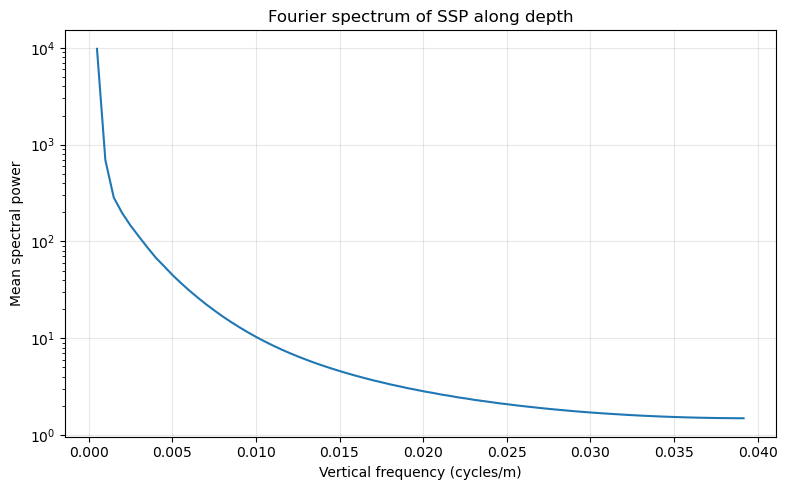

In [ ]:
# Fourier analysis of SSP along depth (2nd dimension: z)
# Uses ssp_truth_da (time, z, lat, lon) and depth_array (meters)


# FFT assumes regular spacing -> interpolate to uniform depth grid
z_uniform = np.linspace(float(ssp_truth_da.z.min()), float(ssp_truth_da.z.max()), ssp_truth_da.sizes["z"])
da_u = ssp_truth_da.interp(z=z_uniform)

ssp_u = da_u.data  # shape: (time, z, lat, lon)
ssp_anom = ssp_u - np.nanmean(ssp_u, axis=1, keepdims=True)  # remove depth-mean per profile

dz = float(np.mean(np.diff(z_uniform)))  # meters
n_z = ssp_anom.shape[1]

fft_z = np.fft.rfft(ssp_anom, axis=1)
power_z = (np.abs(fft_z) ** 2) / n_z  # relative power spectrum

freq_cpm = np.fft.rfftfreq(n_z, d=dz)  # cycles per meter
mean_power = np.nanmean(power_z, axis=(0, 2, 3))  # average over time/lat/lon

# dominant non-zero frequency
valid = freq_cpm > 0
dom_idx = np.argmax(mean_power[valid])
dom_freq = freq_cpm[valid][dom_idx]
dom_wavelength = 1.0 / dom_freq

print(f"Depth sampling dz: {dz:.3f} m")
print(f"Dominant vertical frequency: {dom_freq:.6f} cycles/m")
print(f"Dominant vertical wavelength: {dom_wavelength:.2f} m")

plt.figure(figsize=(8, 5))
plt.semilogy(freq_cpm[valid], mean_power[valid])
plt.xlabel("Vertical frequency (cycles/m)")
plt.ylabel("Mean spectral power")
plt.title("Fourier spectrum of SSP along depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

def compute_power_spectrum(da, dim="z", detrend=True, window=True):
    """
    Compute power spectrum along a given dimension (default: z)
    """

    # --- Get axis index
    axis = da.get_axis_num(dim)
    n = da.sizes[dim]

    z_uniform = np.linspace(float(da.z.min()), float(da.z.max()), da.sizes["z"])
    da = da.interp(z=z_uniform)

    # --- Grid spacing
    coords = da[dim].values
    d = float(coords[1] - coords[0])

    data = da.values

    # --- Detrend (remove mean along z)
    if detrend:
        data = data - np.mean(data, axis=axis, keepdims=True)

    # --- Windowing (Hanning)
    if window:
        win = np.hanning(n)

        # reshape window for broadcasting
        shape = [1] * data.ndim
        shape[axis] = n
        win = win.reshape(shape)

        data = data * win

    # --- FFT
    fft_vals = np.fft.rfft(data, axis=axis)

    # --- Power spectrum
    power = (np.abs(fft_vals) ** 2) / n

    # --- Frequencies
    freqs = np.fft.rfftfreq(n, d=d)

    # --- Build xarray
    dims = list(da.dims)
    dims[axis] = "freq"

    coords = dict(da.coords)
    coords["freq"] = freqs
    coords.pop(dim)

    power_da = xr.DataArray(
        power,
        dims=dims,
        coords=coords,
        name="power_spectrum"
    )

    return power_da, freqs



power_truth, freqs = compute_power_spectrum(ssp_truth_da)
# optional
power_ae, _ = compute_power_spectrum(ssp_ae_da)

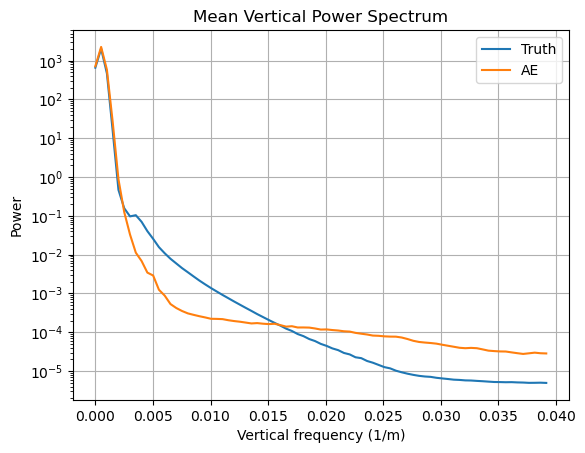

In [ ]:
mean_power_truth = power_truth.mean(dim=("time", "lat", "lon"))

plt.figure()
plt.plot(mean_power_truth.freq, mean_power_truth, label="Truth")

# optional AE
if 'power_ae' in locals():
    mean_power_ae = power_ae.mean(dim=("time", "lat", "lon"))
    plt.plot(mean_power_ae.freq, mean_power_ae, label="AE")

plt.yscale("log")
plt.xlabel("Vertical frequency (1/m)")
plt.ylabel("Power")
plt.title("Mean Vertical Power Spectrum")
plt.legend()
plt.grid()
plt.show()

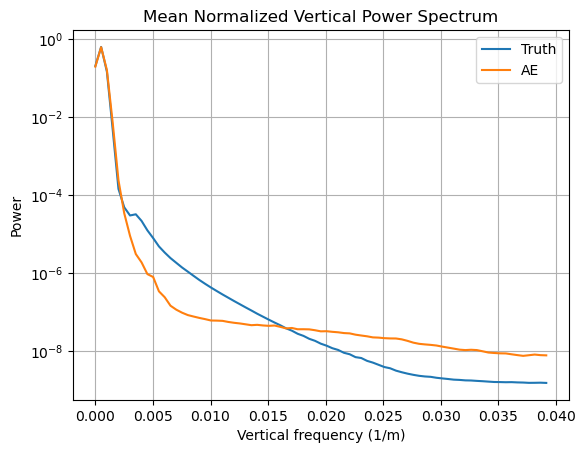

In [ ]:
mean_norm_power_truth = mean_power_truth / (mean_power_truth.sum() + 1e-12)

mean_norm_power_ae = mean_power_ae / (mean_power_ae.sum() + 1e-12)

plt.figure()
plt.plot(mean_norm_power_truth.freq, mean_norm_power_truth, label="Truth")

plt.plot(mean_norm_power_ae.freq, mean_norm_power_ae, label="AE")

plt.yscale("log")
plt.xlabel("Vertical frequency (1/m)")
plt.ylabel("Power")
plt.title("Mean Normalized Vertical Power Spectrum")
plt.legend()
plt.grid()
plt.show()

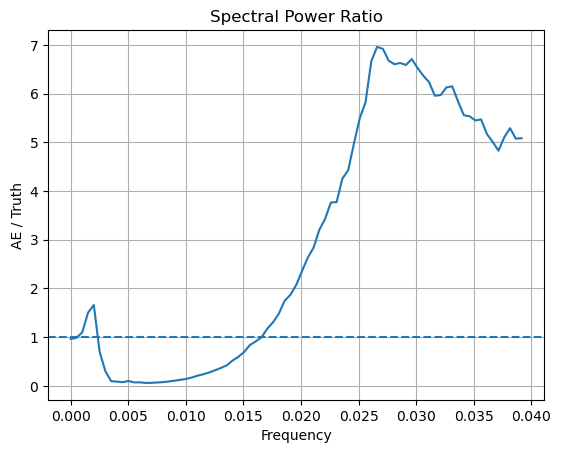

In [ ]:
ratio = mean_norm_power_ae / (mean_norm_power_truth + 1e-12)

plt.figure()
plt.plot(mean_norm_power_truth.freq, ratio)
plt.axhline(1, linestyle="--")
plt.xlabel("Frequency")
plt.ylabel("AE / Truth")
plt.title("Spectral Power Ratio")
plt.grid()
plt.show()

In [ ]:
eps = 1e-12
log_truth = np.log(mean_norm_power_truth + eps)
log_rec   = np.log(mean_norm_power_ae + eps)

lsd = np.sqrt(np.mean((log_truth - log_rec)**2, axis=-1))
print(f"LSD: {lsd.values:.4f}")

peak_truth = np.argmax(mean_norm_power_truth.data, axis=-1)
peak_rec   = np.argmax(mean_norm_power_ae.data, axis=-1)

peak_freq_error = np.abs(freqs[peak_truth] - freqs[peak_rec])
print(f"Peak frequency error: {peak_freq_error:.6f} 1/m")

LSD: 1.6290
Peak frequency error: 0.000000 1/m


### warseinstein

In [ ]:
mean_norm_power_truth.data.shape

(79,)

In [ ]:
from scipy.stats import wasserstein_distance

wd = wasserstein_distance(freqs, freqs,
                          mean_norm_power_truth.data,
                          mean_norm_power_ae.data)

wd

np.float64(1.4002686261246398e-05)

## MS-SSIM


In [ ]:
from skimage.metrics import structural_similarity as ssim

msim = ssim(ssp_truth[50,:,50,50], ssp_ae[50,:,50,50], data_range=ssp_ae[50,:,50,50].max() - ssp_ae[50,:,50,50].min())
msim

np.float64(1.017273094085668)

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def ssim_1d(x, y, sigma=1.5, C1=1e-4, C2=1e-4):
    x = x.astype(np.float64)
    y = y.astype(np.float64)

    mu_x = gaussian_filter1d(x, sigma)
    mu_y = gaussian_filter1d(y, sigma)

    sigma_x = gaussian_filter1d(x**2, sigma) - mu_x**2
    sigma_y = gaussian_filter1d(y**2, sigma) - mu_y**2
    sigma_xy = gaussian_filter1d(x*y, sigma) - mu_x*mu_y

    numerator = (2 * mu_x * mu_y + C1) * (2 * sigma_xy + C2)
    denominator = (mu_x**2 + mu_y**2 + C1) * (sigma_x + sigma_y + C2)

    return np.mean(numerator / (denominator + 1e-12))


ssim_score = ssim_1d(ssp_truth[50,:,50,50], ssp_ae[50,:,50,50])
print(f"1D SSIM: {ssim_score:.4f}")

1D SSIM: 0.8524


In [ ]:
def ms_ssim_1d(x, y, scales=5):
    weights = np.array([0.0448, 0.2856, 0.3001, 0.2363, 0.1333])
    weights = weights[:scales]

    mssim = []
    x_s, y_s = x.copy(), y.copy()

    for i in range(scales):
        ssim_val = ssim_1d(x_s, y_s)
        mssim.append(ssim_val)

        # Downsample (low-pass + decimate)
        x_s = gaussian_filter1d(x_s, sigma=1)[::2]
        y_s = gaussian_filter1d(y_s, sigma=1)[::2]

    mssim = np.array(mssim)

    return np.prod(mssim ** weights)

mssim_score = ms_ssim_1d(ssp_truth[50,:,50,50], ssp_ae[50,:,50,50])
print(f"1D MS-SSIM: {mssim_score:.4f}")

1D MS-SSIM: 0.9396


In [ ]:

flatten_truth = ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1])
flatten_ae = ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1])
mssim_arr = []
# mssim_arr = Parallel(n_jobs=-1)(
#     delayed(ms_ssim_1d)(flatten_truth[prof], flatten_ae[prof]) 
#     for prof in tqdm(range(flatten_truth.shape[0]))
# )

for prof in tqdm(range(flatten_truth.shape[0])):
    mssim_score = ms_ssim_1d(flatten_truth[prof], flatten_ae[prof])
    mssim_arr.append(mssim_score)

mssim_arr = np.array(mssim_arr).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3])
mssim_da = xr.DataArray(mssim_arr, coords=rmse_z.coords, dims=rmse_z.dims)
mssim_da

100%|██████████| 5384448/5384448 [1:11:38<00:00, 1252.69it/s]


<xarray.DataArray (time: 164, lat: 152, lon: 216)> Size: 43MB
array([[[0.92790615, 0.92770497, 0.93243686, ..., 0.9238512 ,
         0.90858166, 0.90997466],
        [0.93283294, 0.93414366, 0.9297958 , ..., 0.91912106,
         0.9090484 , 0.90969496],
        [0.92888195, 0.93699948, 0.93239746, ..., 0.93010953,
         0.91180186, 0.90276658],
        ...,
        [0.94690856, 0.93453971, 0.94889097, ..., 0.8007678 ,
         0.81391828, 0.8297643 ],
        [0.95636358, 0.94759844, 0.94914205, ..., 0.7847895 ,
         0.83647307, 0.8849754 ],
        [0.95969875, 0.95885802, 0.94710222, ..., 0.79921983,
         0.88987683, 0.91967115]],

       [[0.92941627, 0.92887917, 0.92734971, ..., 0.91197717,
         0.88945099, 0.88182297],
        [0.93718803, 0.93475989, 0.92967268, ..., 0.88294071,
         0.89520407, 0.8834771 ],
        [0.9333391 , 0.94532289, 0.93188433, ..., 0.87003157,
         0.8947938 , 0.87384918],
...
        [0.90142397, 0.90285011, 0.91587096, ..., 0.94987123,
         0.95304371, 0.94331185],
        [0.90345176, 0.90432865, 0.90939878, ..., 0.95096963,
         0.9503883 , 0.95647303],
        [0.90136408, 0.90553025, 0.90693223, ..., 0.94403218,
         0.95179355, 0.96608755]],

       [[0.88207804, 0.88539216, 0.8868266 , ..., 0.94644666,
         0.94717439, 0.95388613],
        [0.86474323, 0.87057536, 0.87648755, ..., 0.9411707 ,
         0.94792699, 0.95241982],
        [0.85186057, 0.85357337, 0.85806014, ..., 0.93792347,
         0.94143754, 0.94593003],
        ...,
        [0.91267766, 0.92362018, 0.93219555, ..., 0.91140235,
         0.91842287, 0.92923698],
        [0.90870973, 0.9154308 , 0.92576101, ..., 0.90401601,
         0.89778412, 0.92580441],
        [0.90639042, 0.90930906, 0.91815664, ..., 0.89705369,
         0.90846633, 0.92579412]]], shape=(164, 152, 216))
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-03-21T12:00:00 ... 2013-09-30T12:...
  * lat      (lat) float64 1kB 33.5 33.54 33.58 33.63 ... 40.17 40.21 40.25
  * lon      (lon) float64 2kB -65.01 -64.97 -64.92 ... -55.03 -54.98 -54.94

## mixing layer mse/gradient

In [ ]:
max_mixing_layer_depth = 60  #cf rd_loss #ssp_truth_da.argmax(dim="z").max().values

mse_mixing_layer = ((ssp_ae_da - ssp_truth_da)**2).isel(z=slice(0, max_mixing_layer_depth)).mean().data

In [ ]:
mse_mixing_layer

array(1.1883411, dtype=float32)

Gradient MAE  : 0.011703
Gradient RMSE : 0.027772
Gradient Bias : 0.000309


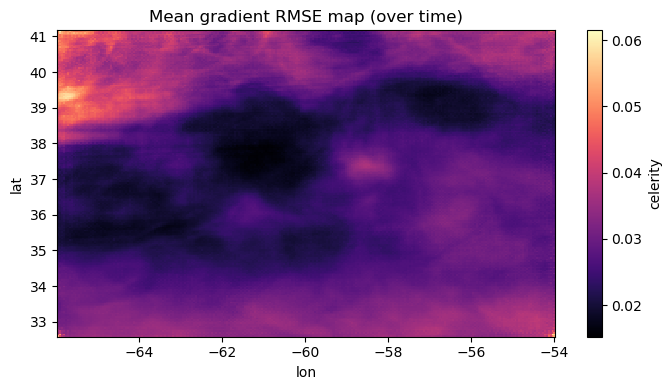

In [ ]:
# Gradient error d(SSP)/dz between AE and truth
dssp_dz_truth = ssp_truth_da.differentiate("z")
dssp_dz_ae = ssp_ae_da.differentiate("z")

gradient_error_da = dssp_dz_ae - dssp_dz_truth
gradient_rmse_da = np.sqrt((gradient_error_da ** 2).mean(dim="z", skipna=True))
# Global metrics
gradient_mae = np.abs(gradient_error_da).mean(skipna=True).item()
gradient_rmse = gradient_rmse_da.data.mean()  # average over time/lat/lon
gradient_bias = gradient_error_da.mean(skipna=True).item()

print(f"Gradient MAE  : {gradient_mae:.6f}")
print(f"Gradient RMSE : {gradient_rmse:.6f}")
print(f"Gradient Bias : {gradient_bias:.6f}")

# Optional: map of gradient RMSE averaged over depth
gradient_rmse_map = np.sqrt((gradient_error_da ** 2).mean(dim="z", skipna=True))

plt.figure(figsize=(7, 4))
gradient_rmse_map.mean(dim="time", skipna=True).plot(cmap="magma")
plt.title("Mean gradient RMSE map (over time)")
plt.tight_layout()
plt.show()

## PCA

In [22]:
ssp_truth.shape, ssp_ae.shape

((164, 157, 152, 216), (164, 157, 152, 216))

In [23]:
grad_truth = ssp_truth_da.differentiate("z").data
grad_ae = ssp_ae_da.differentiate("z").data


In [ ]:
n_components = 3
pca = PCA(n_components=n_components, svd_solver="randomized", random_state=42)
truth_pca = pca.fit_transform(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ae_pca = pca.transform(ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1]))

# truth_pca = pca.fit_transform(grad_truth.transpose(0,2,3,1).reshape(-1, grad_truth.shape[1]))
# ae_pca = pca.transform(grad_ae.transpose(0,2,3,1).reshape(-1, grad_ae.shape[1]))



PCA reconstruction RMSE: 1.4908


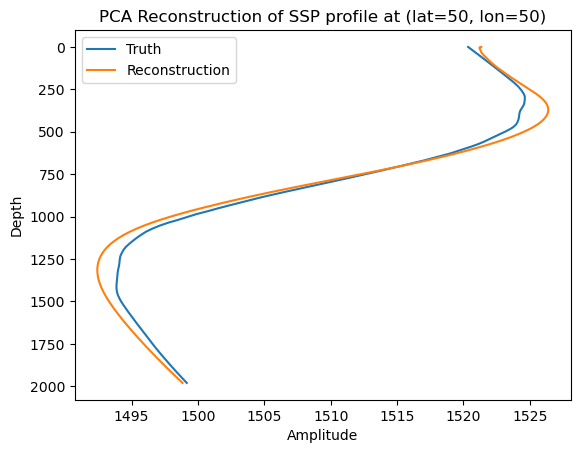

In [33]:
pca = PCA(n_components=3, svd_solver="randomized", random_state=42)
pca.fit(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ae_pca = pca.transform(ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1]))
rec_ae = pca.inverse_transform(ae_pca).reshape(ssp_ae.shape[0], ssp_ae.shape[2], ssp_ae.shape[3], ssp_ae.shape[1]).transpose(0,3,1,2)
rmse_pca = np.sqrt(np.mean((ssp_truth - rec_ae)**2))
print(f"PCA reconstruction RMSE: {rmse_pca:.4f}")
plt.plot(ssp_truth[0, :, 50, 50], depth_array, label="Truth")
plt.plot(rec_ae[0, :, 50, 50], depth_array, label="Reconstruction")
plt.xlabel("Amplitude")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
plt.title("PCA Reconstruction of SSP profile at (lat=50, lon=50)")
plt.legend()
plt.show()

In [26]:
vars(pca)

{'n_components': 6,
 'copy': True,
 'whiten': False,
 'svd_solver': 'randomized',
 'tol': 0.0,
 'iterated_power': 'auto',
 'n_oversamples': 10,
 'power_iteration_normalizer': 'auto',
 'random_state': 42,
 'n_features_in_': 157,
 '_fit_svd_solver': 'randomized',
 'mean_': array([1534.5422, 1534.5449, 1534.5485, 1534.5521, 1534.5565, 1534.5614,
        1534.5671, 1534.5734, 1534.5795, 1534.5867, 1534.5944, 1534.6029,
        1534.6128, 1534.6239, 1534.6351, 1534.648 , 1534.661 , 1534.6744,
        1534.6892, 1534.704 , 1534.7181, 1534.7314, 1534.7445, 1534.7582,
        1534.7722, 1534.7866, 1534.8052, 1534.826 , 1534.8505, 1534.8772,
        1534.9058, 1534.9359, 1534.9697, 1535.012 , 1535.0627, 1535.1036,
        1535.1252, 1535.1344, 1535.1338, 1535.1287, 1535.1179, 1535.1064,
        1535.0947, 1535.0813, 1535.0663, 1535.0503, 1535.0319, 1535.0122,
        1534.9888, 1534.9608, 1534.9293, 1534.8962, 1534.8636, 1534.8295,
        1534.7972, 1534.7635, 1534.7305, 1534.6984, 1534.6671, 

PCA reconstruction RMSE: 0.8587


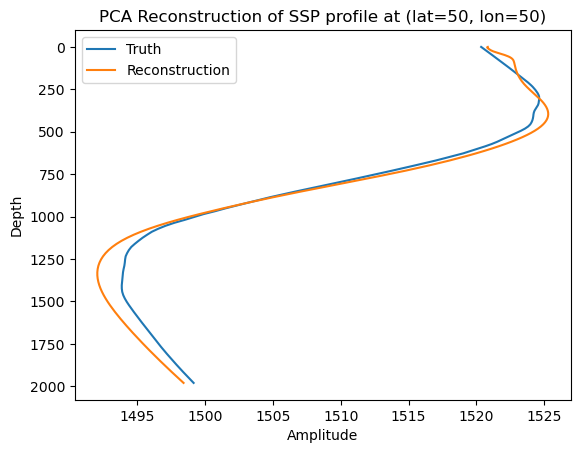

In [25]:
pca = PCA(n_components=6, svd_solver="randomized", random_state=42)
pca.fit(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ae_pca = pca.transform(ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1]))
rec_ae = pca.inverse_transform(ae_pca).reshape(ssp_ae.shape[0], ssp_ae.shape[2], ssp_ae.shape[3], ssp_ae.shape[1]).transpose(0,3,1,2)
rmse_pca = np.sqrt(np.mean((ssp_truth - rec_ae)**2))
print(f"PCA reconstruction RMSE: {rmse_pca:.4f}")
plt.plot(ssp_truth[0, :, 50, 50], depth_array, label="Truth")
plt.plot(rec_ae[0, :, 50, 50], depth_array, label="Reconstruction")
plt.xlabel("Amplitude")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
plt.title("PCA Reconstruction of SSP profile at (lat=50, lon=50)")
plt.legend()
plt.show()

PCA reconstruction RMSE: 1.8347


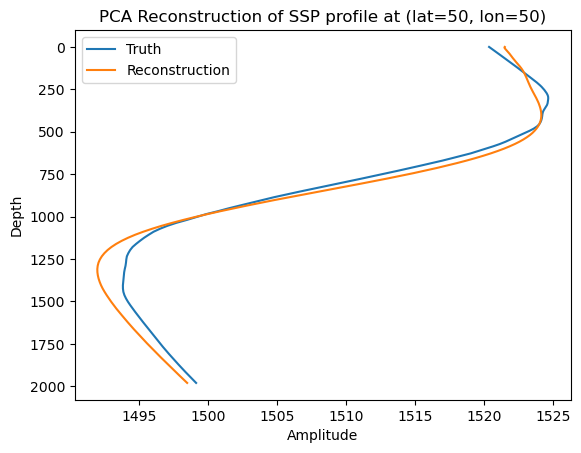

In [34]:
pca = PCA(n_components=3, svd_solver="randomized", random_state=42)
pca.fit(ssp_train.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ae_pca = pca.transform(ssp_ae.transpose(0,2,3,1).reshape(-1, ssp_ae.shape[1]))
rec_ae = pca.inverse_transform(ae_pca).reshape(ssp_ae.shape[0], ssp_ae.shape[2], ssp_ae.shape[3], ssp_ae.shape[1]).transpose(0,3,1,2)
rmse_pca = np.sqrt(np.mean((ssp_truth - rec_ae)**2))
print(f"PCA reconstruction RMSE: {rmse_pca:.4f}")
plt.plot(ssp_truth[0, :, 50, 50], depth_array, label="Truth")
plt.plot(rec_ae[0, :, 50, 50], depth_array, label="Reconstruction")
plt.xlabel("Amplitude")
plt.ylabel("Depth")
plt.gca().invert_yaxis()
plt.title("PCA Reconstruction of SSP profile at (lat=50, lon=50)")
plt.legend()
plt.show()

In [28]:
ssp_train.mean(), ssp_truth.mean(), ssp_ae.mean()

(np.float32(1510.9314), np.float32(1509.4363), np.float32(1509.604))

In [29]:
ssp_train.shape, ssp_truth.shape, ssp_ae.shape

((365, 157, 152, 216), (164, 157, 152, 216), (164, 157, 152, 216))

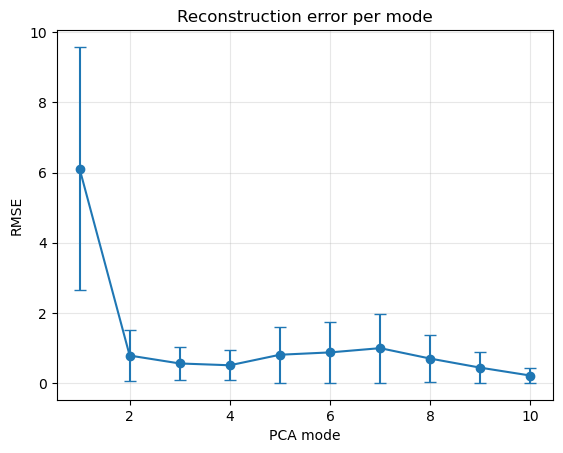

In [ ]:
rmse_per_mode = np.sqrt(((ae_pca - truth_pca) ** 2).mean(axis=0))
std_per_mode = (ae_pca - truth_pca).std(axis=0)

plt.errorbar(
    np.arange(1, len(rmse_per_mode) + 1),
    rmse_per_mode,
    yerr=std_per_mode,
    marker='o',
    capsize=4,
    linewidth=1.5
)
plt.xlabel("PCA mode")
plt.ylabel("RMSE")
plt.title("Reconstruction error per mode")
plt.grid(alpha=0.3)
plt.show()

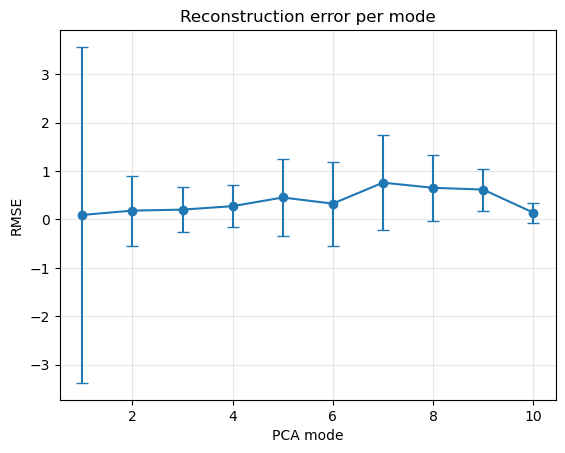

In [ ]:
rmse_per_mode = np.sqrt(((ae_pca - truth_pca) ** 2).mean(axis=0))/np.mean(np.abs(truth_pca), axis=0)
std_per_mode = (ae_pca - truth_pca).std(axis=0)

plt.errorbar(
    np.arange(1, len(rmse_per_mode) + 1),
    rmse_per_mode,
    yerr=std_per_mode,
    marker='o',
    capsize=4,
    linewidth=1.5
)
plt.xlabel("PCA mode")
plt.ylabel("RMSE")
plt.title("Reconstruction error per mode")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_493052/2544146534.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


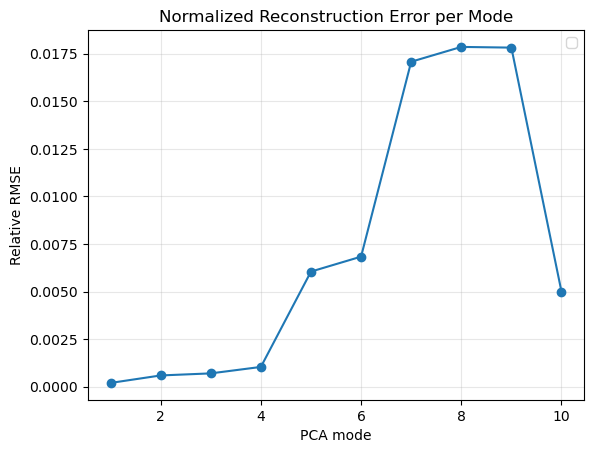

In [ ]:
explained_var = pca.explained_variance_

relative_error = rmse_per_mode / np.sqrt(explained_var)

plt.figure()

x = np.arange(1, n_components+1)

plt.plot(x, relative_error, marker='o')


plt.xlabel("PCA mode")
plt.ylabel("Relative RMSE")
plt.title("Normalized Reconstruction Error per Mode")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
weighted_error = np.sum(relative_error * explained_var) / np.sum(explained_var)
weighted_error

np.float32(0.0007607456)

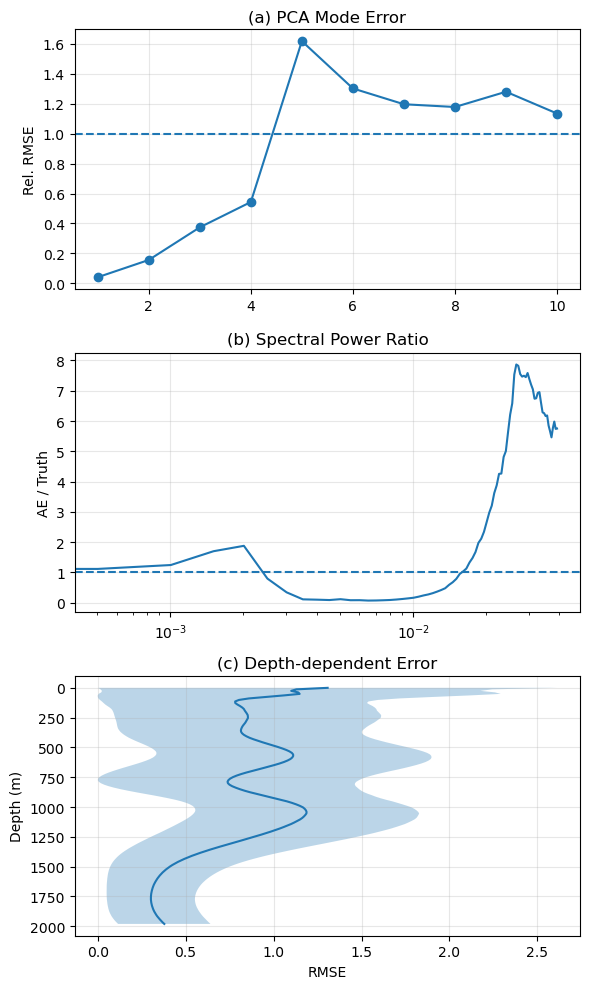

In [ ]:

# =========================
# 1. PREPARE DATA
# =========================
# reshape: (time, z, lat, lon) → (samples, z)
def reshape_profiles(arr):
    return arr.transpose(0,2,3,1).reshape(-1, arr.shape[1])

z = ssp_truth_da.z.values

z_min, z_max = z.min(), z.max()
n_z = len(z)

# uniform grid
z_uniform = np.linspace(z_min, z_max, n_z)

ssp_truth_uniform = ssp_truth_da.interp(z=z_uniform)
ssp_ae_uniform    = ssp_ae_da.interp(z=z_uniform)


truth_flat = reshape_profiles(ssp_truth_uniform.data)
ae_flat    = reshape_profiles(ssp_ae_uniform.data)


# =========================
# 2. PCA ERROR
# =========================
n_components = 10
pca = PCA(n_components=n_components)

truth_pca = pca.fit_transform(truth_flat)
ae_pca    = pca.transform(ae_flat)

error_pca = ae_pca - truth_pca

rmse_pca = np.sqrt((error_pca**2).mean(axis=0))
std_truth = truth_pca.std(axis=0)

relative_pca_error = rmse_pca / (std_truth + 1e-12)

# =========================
# 3. FOURIER SPECTRUM ERROR
# =========================
def compute_spectrum(data, dz):



    data = data - data.mean(axis=1, keepdims=True)
    window = np.hanning(data.shape[1])
    data = data * window[None, :]

    fft_vals = np.fft.rfft(data, axis=1)
    power = (np.abs(fft_vals)**2) / (data.shape[1]*dz)

    freqs = np.fft.rfftfreq(data.shape[1], d=dz)
    return freqs, power

dz = float(z_uniform[1] - z_uniform[0])

freqs, power_truth = compute_spectrum(truth_flat, dz)
_,     power_ae    = compute_spectrum(ae_flat, dz)

mean_truth_spec = power_truth.mean(axis=0)
mean_ae_spec    = power_ae.mean(axis=0)

spectral_ratio = mean_ae_spec / (mean_truth_spec + 1e-12)



# =========================
# 3bis. GRADIENT SPECTRUM
# =========================
# compute vertical gradients
grad_truth = np.gradient(truth_flat, dz, axis=1)
grad_ae    = np.gradient(ae_flat, dz, axis=1)

# compute spectra on gradients
_, grad_power_truth = compute_spectrum(grad_truth, dz)
_, grad_power_ae    = compute_spectrum(grad_ae, dz)

mean_grad_truth = grad_power_truth.mean(axis=0)
mean_grad_ae    = grad_power_ae.mean(axis=0)

grad_spectral_ratio = mean_grad_ae / (mean_grad_truth + 1e-12)



# =========================
# 4. DEPTH-DEPENDENT ERROR
# =========================
rmse_depth = np.sqrt(((ssp_ae_uniform - ssp_truth_uniform)**2).mean(axis=(0,2,3)))
std_depth  = ((ssp_ae_uniform - ssp_truth_uniform)).std(axis=(0,2,3))

depth = ssp_truth_uniform.z.values

# =========================
# 5. PLOT (IEEE STYLE)
# =========================
fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=False)

# ---- (a) PCA error
ax = axes[0]
x = np.arange(1, n_components+1)

ax.plot(x, relative_pca_error, marker='o')
ax.axhline(1, linestyle='--')

ax.set_ylabel("Rel. RMSE")
ax.set_title("(a) PCA Mode Error")
ax.grid(alpha=0.3)

# ---- (b) Fourier spectrum
ax = axes[1]

ax.plot(freqs, spectral_ratio)
ax.axhline(1, linestyle='--')

ax.set_xscale("log")
ax.set_ylabel("AE / Truth")
ax.set_title("(b) Spectral Power Ratio")
ax.grid(alpha=0.3)

# ---- (c) Depth RMSE
ax = axes[2]

ax.plot(rmse_depth, depth)
ax.fill_betweenx(depth,
                 rmse_depth - std_depth,
                 rmse_depth + std_depth,
                 alpha=0.3)

ax.invert_yaxis()
ax.set_xlabel("RMSE")
ax.set_ylabel("Depth (m)")
ax.set_title("(c) Depth-dependent Error")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

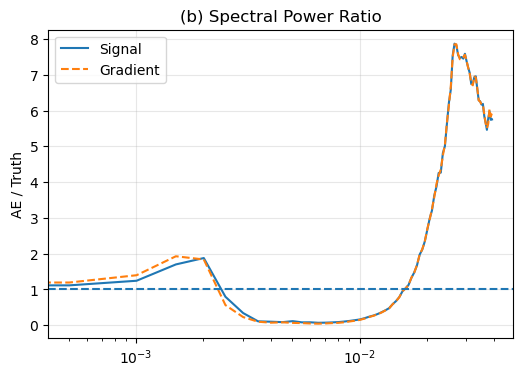

In [ ]:
plt.figure(figsize=(6, 4))

plt.plot(freqs, spectral_ratio, label="Signal")
plt.plot(freqs, grad_spectral_ratio, linestyle='--', label="Gradient")

plt.axhline(1, linestyle='--')

plt.xscale("log")
plt.ylabel("AE / Truth")
plt.title("(b) Spectral Power Ratio")
plt.legend()
plt.grid(alpha=0.3)

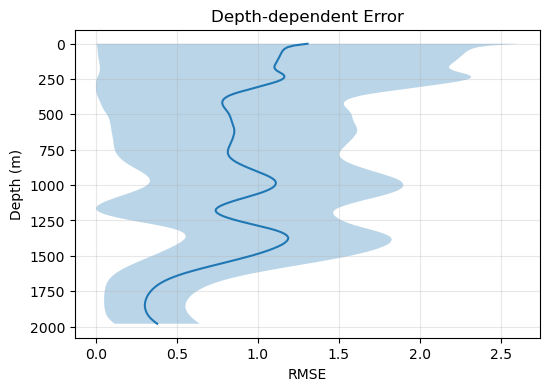

In [ ]:
rmse_depth = np.sqrt(((ssp_ae - ssp_truth)**2).mean(axis=(0,2,3)))
std_depth  = ((ssp_ae - ssp_truth)).std(axis=(0,2,3))

plt.figure(figsize=(6, 4))
plt.plot(rmse_depth, depth)
plt.fill_betweenx(depth,
                 rmse_depth - std_depth,
                 rmse_depth + std_depth,
                 alpha=0.3) 
plt.gca().invert_yaxis()
plt.xlabel("RMSE")
plt.ylabel("Depth (m)")
plt.title("Depth-dependent Error")
plt.grid(alpha=0.3)
plt.show()

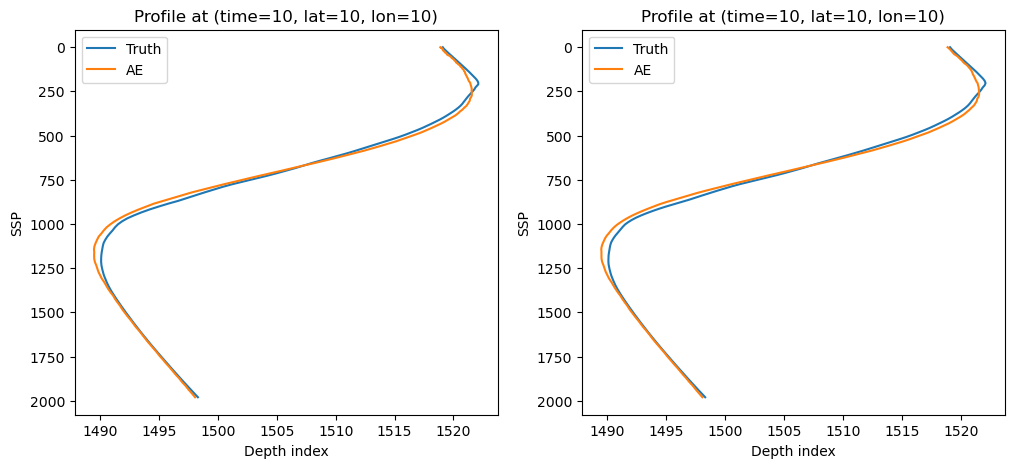

In [ ]:
fig,axs = plt.subplots(1,2, figsize=(12,5))
axs[0].plot(ssp_truth[10,:,10,10], depth_array,label="Truth")
axs[0].plot(ssp_ae[10,:,10,10], depth_array, label="AE")
axs[0].invert_yaxis()
axs[0].set_title("Profile at (time=10, lat=10, lon=10)")
axs[0].set_xlabel("Depth index")
axs[0].set_ylabel("SSP")
axs[0].legend()


axs[1].plot(ssp_truth_uniform.data[10,:,10,10], depth, label="Truth")
axs[1].plot(ssp_ae_uniform.data[10,:,10,10], depth, label="AE")
axs[1].invert_yaxis()
axs[1].set_title("Profile at (time=10, lat=10, lon=10)")
axs[1].set_xlabel("Depth index")
axs[1].set_ylabel("SSP")
axs[1].legend()

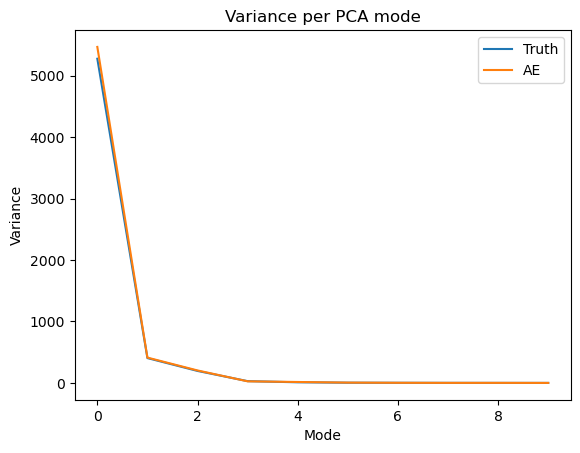

In [ ]:
var_truth = np.var(truth_pca, axis=0)
var_ae    = np.var(ae_pca, axis=0)

plt.plot(var_truth, label="Truth")
plt.plot(var_ae, label="AE")

plt.legend()
plt.title("Variance per PCA mode")
plt.xlabel("Mode")
plt.ylabel("Variance")
plt.show()

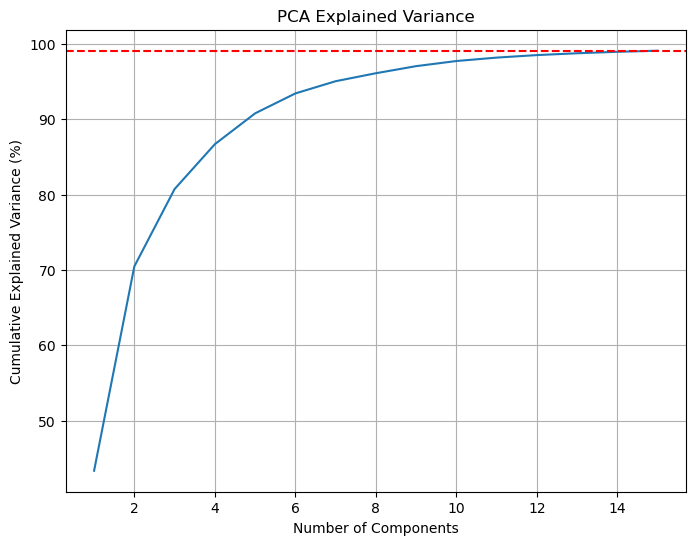

In [30]:
plt.figure(figsize=(8,6))
plt.plot(np.linspace(1, len(pca.explained_variance_ratio_), len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_)*100)
plt.axhline(y=99, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')
plt.grid()


In [ ]:
truth_pca.shape, pca.components_.shape

((5384448, 10), (10, 157))

In [ ]:
pears_pca = pearsonr(truth_pca, ae_pca)
pears_pca.statistic.min(), pears_pca.statistic.max(), pears_pca.statistic.mean(), pears_pca.statistic.shape

(np.float64(0.20913502358208041),
 np.float64(0.9995251636070374),
 np.float64(0.6050805181875158),
 (10,))

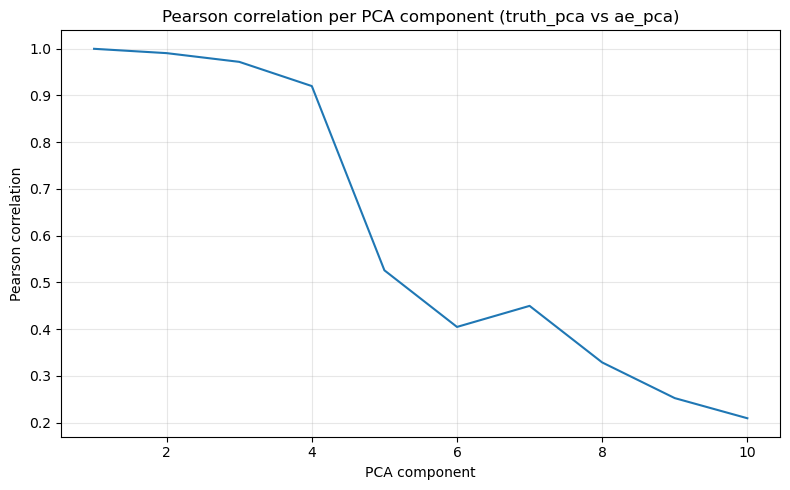

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(pears_pca.statistic)+1), pears_pca.statistic)
plt.xlabel("PCA component")
plt.ylabel("Pearson correlation")
plt.title("Pearson correlation per PCA component (truth_pca vs ae_pca)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

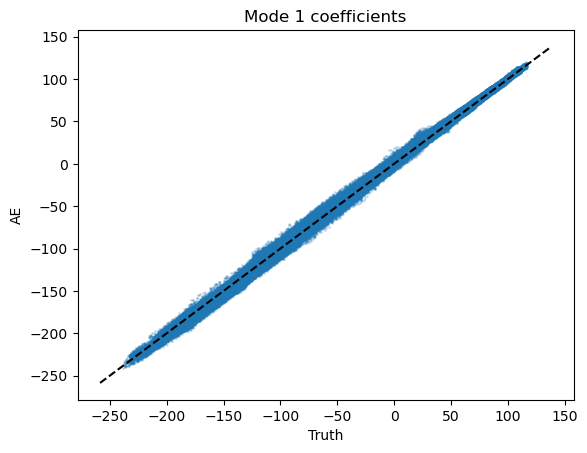

In [ ]:
i = 0  # mode index

plt.scatter(truth_pca[:, i], ae_pca[:, i], s=1, alpha=0.2)
plt.xlabel("Truth")
plt.ylabel("AE")
plt.title(f"Mode {i+1} coefficients")

# ideal line
lims = [
    np.min([plt.xlim(), plt.ylim()]),
    np.max([plt.xlim(), plt.ylim()]),
]
plt.plot(lims, lims, 'k--')
plt.show()

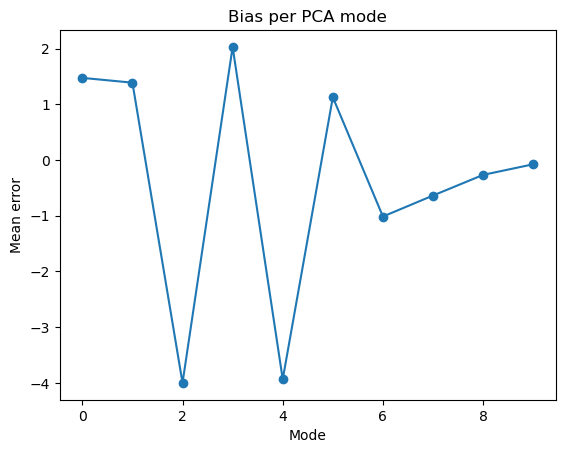

In [ ]:
bias_per_mode = (ae_pca - truth_pca).mean(axis=0)

plt.plot(bias_per_mode, marker='o')
plt.title("Bias per PCA mode")
plt.xlabel("Mode")
plt.ylabel("Mean error")
plt.show()

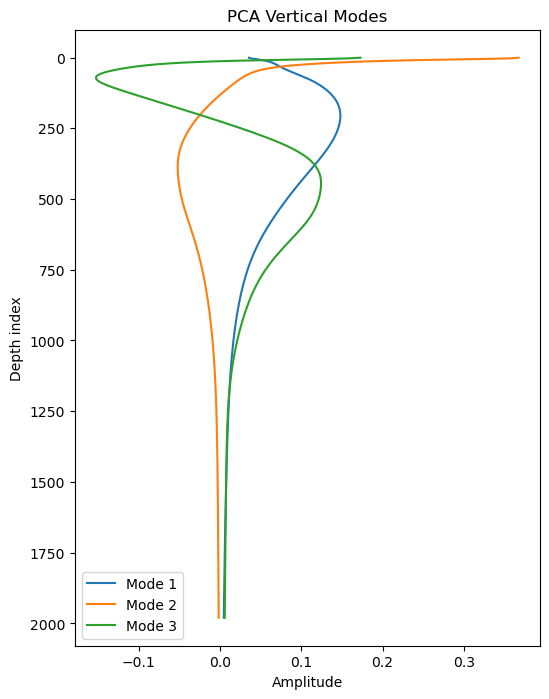

In [ ]:

modes = pca.components_  # (n_components, depth)

plt.figure(figsize=(6,8))

for i in range(3):
    plt.plot(modes[i], depth_array, label=f"Mode {i+1}")

plt.gca().invert_yaxis()
plt.xlabel("Amplitude")
plt.ylabel("Depth index")
plt.legend()
plt.title("PCA Vertical Modes")
plt.show()

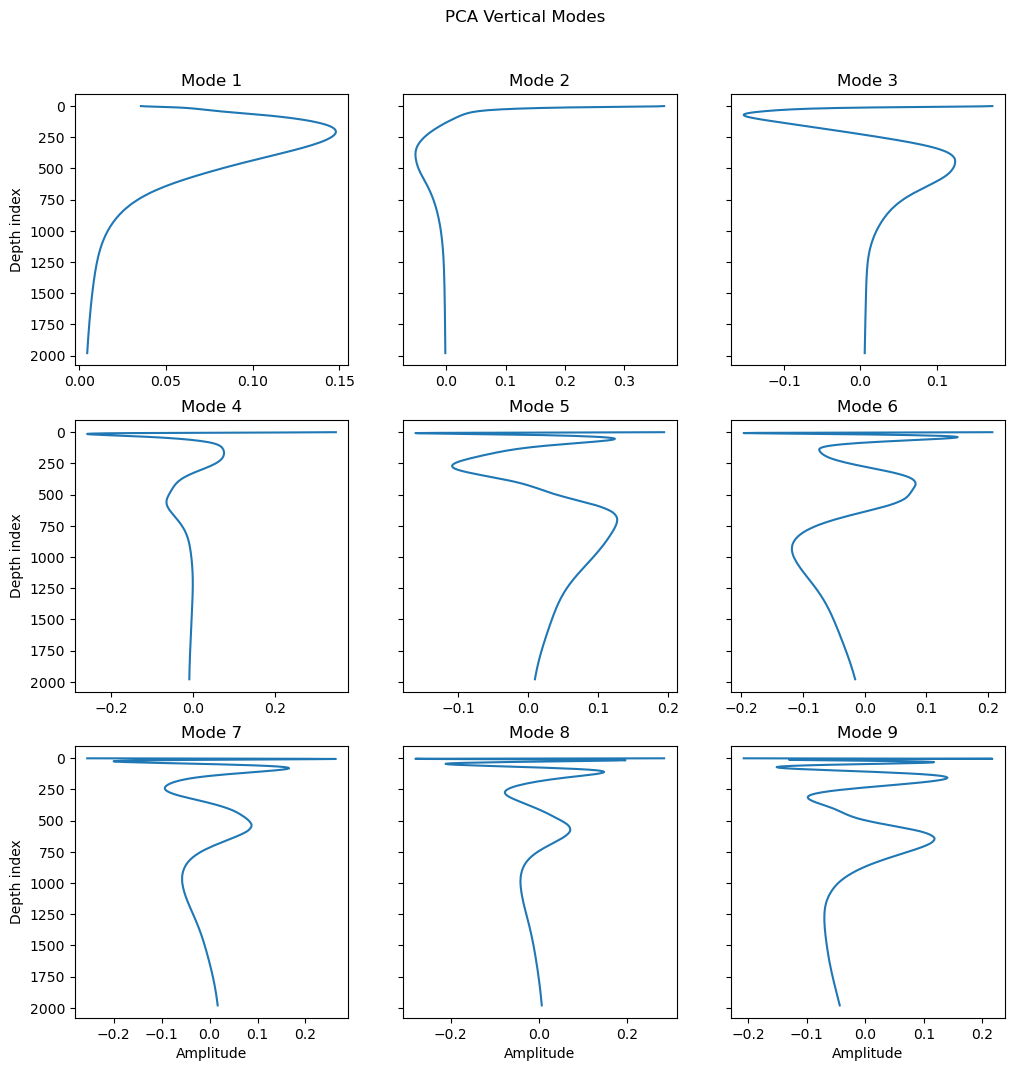

In [ ]:

modes = pca.components_  # (n_components, depth)

fig,axs = plt.subplots(3,3, figsize=(12,12), sharey=True)

axs[0,0].plot(modes[0], depth_array, label=f"Mode {0+1}")
axs[0,1].plot(modes[1], depth_array, label=f"Mode {1+1}")
axs[0,2].plot(modes[2], depth_array, label=f"Mode {2+1}")

axs[1,0].plot(modes[3], depth_array, label=f"Mode {3+1}")
axs[1,1].plot(modes[4], depth_array, label=f"Mode {4+1}")
axs[1,2].plot(modes[5], depth_array, label=f"Mode {5+1}")

axs[2,0].plot(modes[6], depth_array, label=f"Mode {6+1}")
axs[2,1].plot(modes[7], depth_array, label=f"Mode {7+1}")
axs[2,2].plot(modes[8], depth_array, label=f"Mode {8+1}")


axs[0,0].invert_yaxis()

axs[0,0].set_ylabel("Depth index")
axs[1,0].set_ylabel("Depth index")
axs[2,0].set_ylabel("Depth index")


axs[2,0].set_xlabel("Amplitude")
axs[2,1].set_xlabel("Amplitude")
axs[2,2].set_xlabel("Amplitude")


for i,ax in enumerate(axs.flatten()):
    ax.set_title(f"Mode {i+1}")

fig.suptitle("PCA Vertical Modes", y = .95)

plt.show()

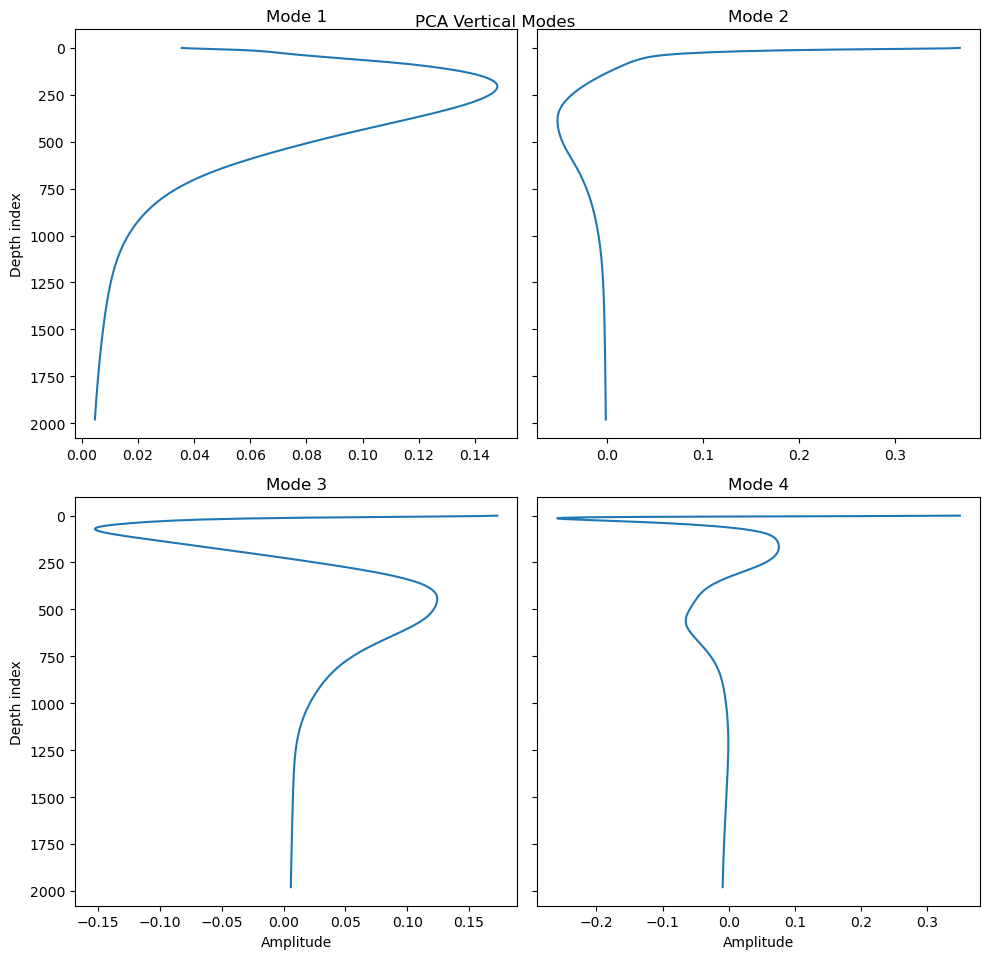

In [ ]:
modes = pca.components_  # (n_components, depth)

fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.plot(modes[i], depth_array, label=f"Mode {i+1}")
    ax.set_title(f"Mode {i+1}")

# Keep depth orientation
axs[0].invert_yaxis()

# Axis labels
axs[0].set_ylabel("Depth index")
axs[2].set_ylabel("Depth index")
axs[2].set_xlabel("Amplitude")
axs[3].set_xlabel("Amplitude")

fig.suptitle("PCA Vertical Modes", y=0.95)
plt.tight_layout()
plt.show()


In [ ]:
truth_pca.shape, ae_pca.shape

((5384448, 10), (5384448, 10))

### PCA profiles

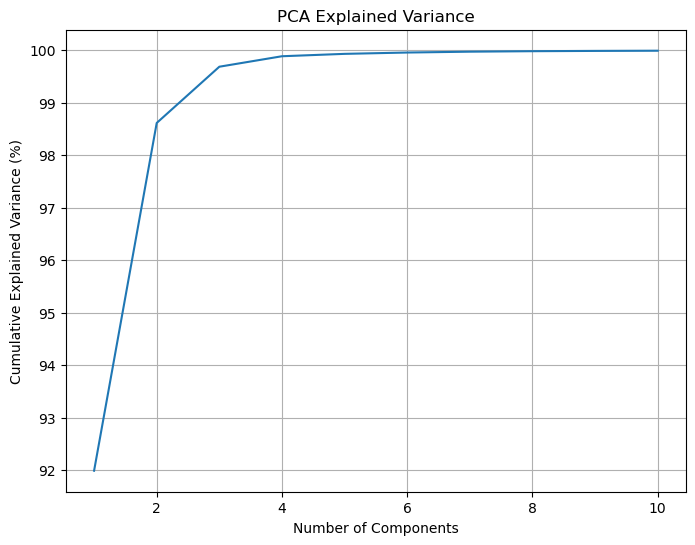

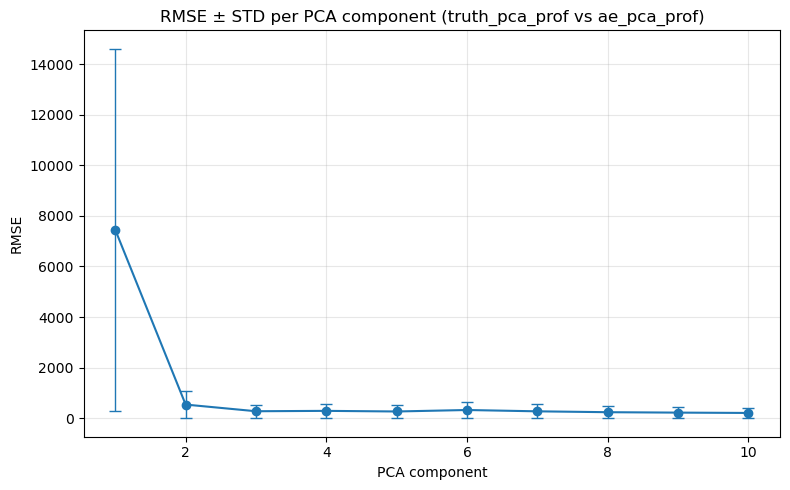

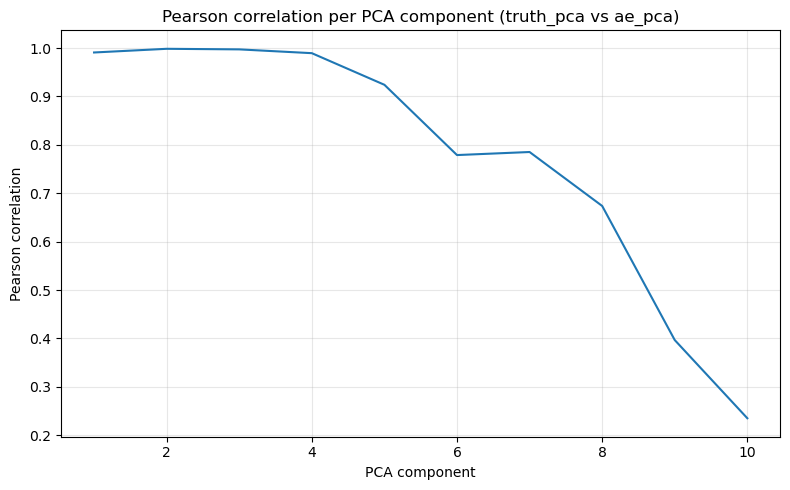

In [ ]:
n_components = 10
pca = PCA(n_components=n_components, svd_solver='auto')
truth_pca_prof = pca.fit_transform(ssp_truth.transpose(1,0,2,3).reshape(ssp_truth.shape[1], -1))
ae_pca_prof = pca.transform(ssp_ae.transpose(1,0,2,3).reshape(ssp_ae.shape[1], -1))

plt.figure(figsize=(8,6))
plt.plot(np.linspace(1, len(pca.explained_variance_ratio_), len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')
plt.grid()

# Errorbar plot of PCA reconstruction RMSE per component
err = truth_pca_prof - ae_pca_prof
sq_err = err ** 2

rmse_per_comp = np.sqrt(np.mean(sq_err, axis=0))
std_per_comp = np.std(err, axis=0)  # std of reconstruction error

components = np.arange(1, rmse_per_comp.shape[0] + 1)

plt.figure(figsize=(8, 5))
plt.errorbar(
    components,
    rmse_per_comp,
    yerr=std_per_comp,
    fmt='o-',
    capsize=4,
    elinewidth=1,
    linewidth=1.5
)
plt.xlabel("PCA component")
plt.ylabel("RMSE")
plt.title("RMSE ± STD per PCA component (truth_pca_prof vs ae_pca_prof)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
pears_pca = pearsonr(truth_pca_prof, ae_pca_prof)
pears_pca.statistic.min(), pears_pca.statistic.max(), pears_pca.statistic.mean(), pears_pca.statistic.shape
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(pears_pca.statistic)+1), pears_pca.statistic)
plt.xlabel("PCA component")
plt.ylabel("Pearson correlation")
plt.title("Pearson correlation per PCA component (truth_pca vs ae_pca)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ssp_ae.shape,ssp_truth.transpose(1,0,2,3).reshape(ssp_truth.shape[1], -1).shape

((164, 157, 152, 216), (157, 5384448))

In [ ]:
truth_pca_prof[:,0].min(), truth_pca_prof[:,0].max(), truth_pca_prof[:,0].mean()

(np.float32(-42103.145), np.float32(44682.234), np.float32(-0.0031847134))

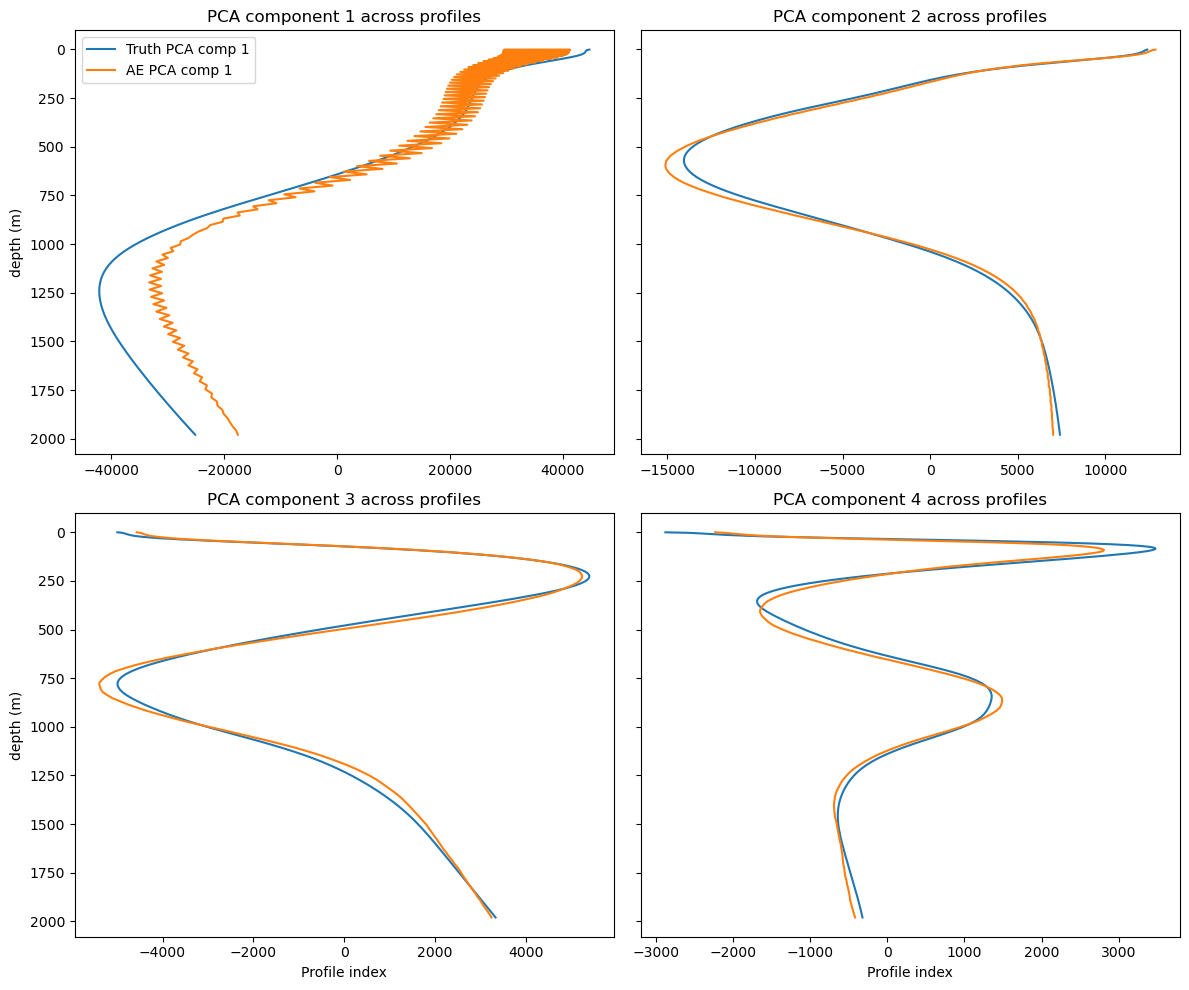

In [ ]:
fig,axs=plt.subplots(2,2, figsize=(12,10), sharey=True)
axs[0,0].plot(truth_pca_prof[:,0], depth_array, label="Truth PCA comp 1")
axs[0,0].plot(ae_pca_prof[:,0], depth_array, label="AE PCA comp 1")

axs[0,1].plot(truth_pca_prof[:,1], depth_array, label="Truth PCA comp 2")
axs[0,1].plot(ae_pca_prof[:,1], depth_array, label="AE PCA comp 2")

axs[1,0].plot(truth_pca_prof[:,2], depth_array, label="Truth PCA comp 3")
axs[1,0].plot(ae_pca_prof[:,2], depth_array, label="AE PCA comp 3")

axs[1,1].plot(truth_pca_prof[:,3], depth_array, label="Truth PCA comp 4")
axs[1,1].plot(ae_pca_prof[:,3], depth_array, label="AE PCA comp 4")




axs[0,0].set_ylabel("depth (m)")
axs[0,0].invert_yaxis()  # Invert y-axis to have depth
axs[0,0].legend()
axs[0,0].set_title("PCA component 1 across profiles")

axs[1,0].set_xlabel("Profile index")
axs[1,0].set_ylabel("depth (m)")
axs[1,0].set_title("PCA component 3 across profiles")
#axs[1,0].invert_yaxis()  # Invert y-axis to have depth


axs[0,1].set_title("PCA component 2 across profiles")

axs[1,1].set_xlabel("Profile index")
axs[1,1].set_title("PCA component 4 across profiles")


plt.tight_layout()
plt.show()

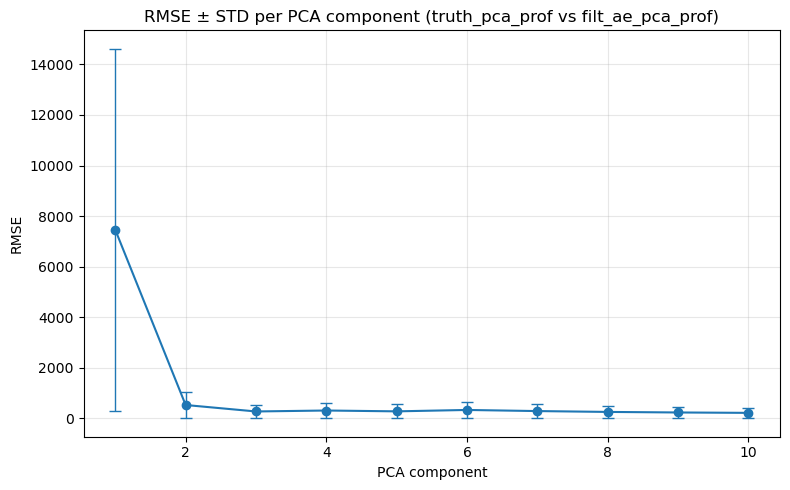

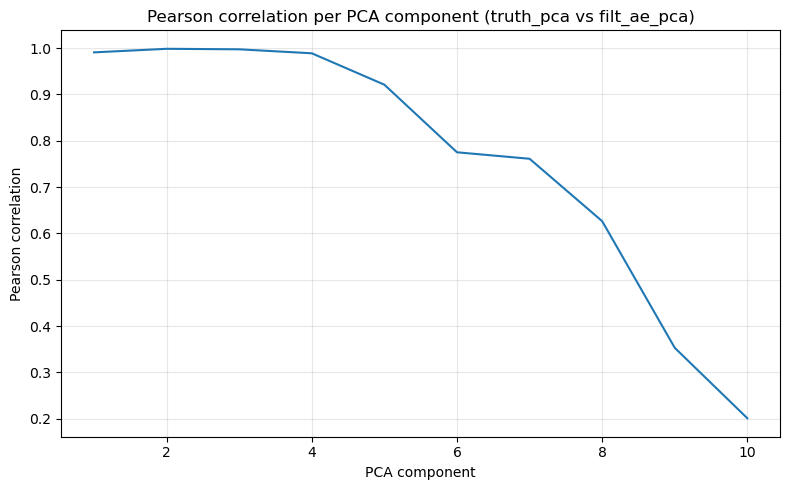

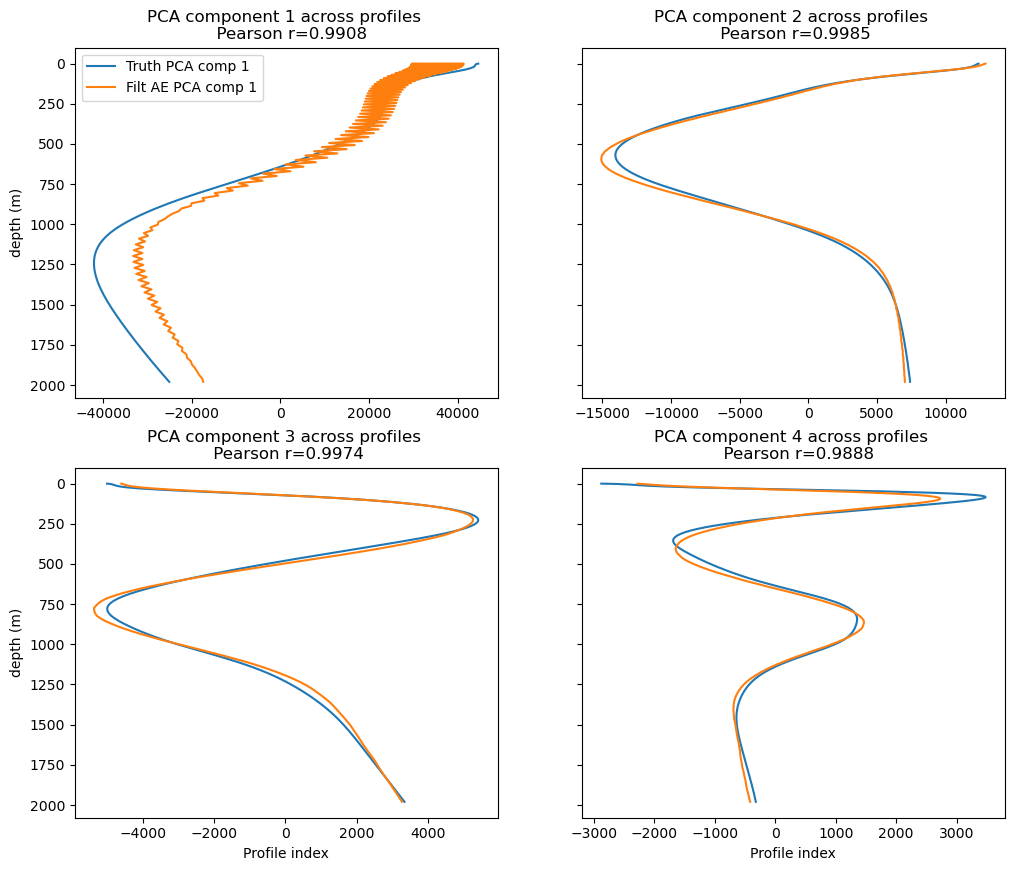

In [ ]:
n_components = 10
pca = PCA(n_components=n_components, svd_solver='auto')
truth_pca_prof = pca.fit_transform(ssp_truth.transpose(1,0,2,3).reshape(ssp_truth.shape[1], -1))
filt_ae_pca_prof = pca.transform(filt_ae.transpose(1,0,2,3).reshape(ssp_ae.shape[1], -1))



# Errorbar plot of PCA reconstruction RMSE per component
err = truth_pca_prof - filt_ae_pca_prof
sq_err = err ** 2

rmse_per_comp = np.sqrt(np.mean(sq_err, axis=0))
std_per_comp = np.std(err, axis=0)  # std of reconstruction error

components = np.arange(1, rmse_per_comp.shape[0] + 1)

plt.figure(figsize=(8, 5))
plt.errorbar(
    components,
    rmse_per_comp,
    yerr=std_per_comp,
    fmt='o-',
    capsize=4,
    elinewidth=1,
    linewidth=1.5
)
plt.xlabel("PCA component")
plt.ylabel("RMSE")
plt.title("RMSE ± STD per PCA component (truth_pca_prof vs filt_ae_pca_prof)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
pears_pca = pearsonr(truth_pca_prof, filt_ae_pca_prof)
pears_pca.statistic.min(), pears_pca.statistic.max(), pears_pca.statistic.mean(), pears_pca.statistic.shape
plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(pears_pca.statistic)+1), pears_pca.statistic)
plt.xlabel("PCA component")
plt.ylabel("Pearson correlation")
plt.title("Pearson correlation per PCA component (truth_pca vs filt_ae_pca)")
plt.grid(alpha=0.3)
plt.tight_layout()




fig,axs=plt.subplots(2,2, figsize=(12,10), sharey=True)
axs[0,0].plot(truth_pca_prof[:,0], depth_array, label="Truth PCA comp 1")
axs[0,0].plot(filt_ae_pca_prof[:,0], depth_array, label="Filt AE PCA comp 1")
mse_1 = np.mean((truth_pca_prof[:,0] - filt_ae_pca_prof[:,0])**2)
pears_1 = pearsonr(truth_pca_prof[:,0], filt_ae_pca_prof[:,0])

axs[0,1].plot(truth_pca_prof[:,1], depth_array, label="Truth PCA comp 2")
axs[0,1].plot(filt_ae_pca_prof[:,1], depth_array, label="Filt AE PCA comp 2")
mse_2 = np.mean((truth_pca_prof[:,1] - filt_ae_pca_prof[:,1])**2)
pears_2 = pearsonr(truth_pca_prof[:,1], filt_ae_pca_prof[:,1])

axs[1,0].plot(truth_pca_prof[:,2], depth_array, label="Truth PCA comp 3")
axs[1,0].plot(filt_ae_pca_prof[:,2], depth_array, label="Filt AE PCA comp 3")
mse_3 = np.mean((truth_pca_prof[:,2] - filt_ae_pca_prof[:,2])**2)
pears_3 = pearsonr(truth_pca_prof[:,2], filt_ae_pca_prof[:,2])

axs[1,1].plot(truth_pca_prof[:,3], depth_array, label="Truth PCA comp 4")
axs[1,1].plot(filt_ae_pca_prof[:,3], depth_array, label="Filt AE PCA comp 4")
mse_4 = np.mean((truth_pca_prof[:,3] - filt_ae_pca_prof[:,3])**2)
pears_4 = pearsonr(truth_pca_prof[:,3], filt_ae_pca_prof[:,3])




axs[0,0].set_ylabel("depth (m)")
axs[0,0].invert_yaxis()  # Invert y-axis to have depth
axs[0,0].legend()
axs[0,0].set_title(f"PCA component 1 across profiles \n  Pearson r={pears_1.statistic:.4f}")

axs[1,0].set_xlabel("Profile index")
axs[1,0].set_ylabel("depth (m)")
axs[1,0].set_title(f"PCA component 3 across profiles \n Pearson r={pears_3.statistic:.4f}")
#axs[1,0].invert_yaxis()  # Invert y-axis to have depth


axs[0,1].set_title(f"PCA component 2 across profiles \n Pearson r={pears_2.statistic:.4f}")

axs[1,1].set_xlabel("Profile index")
axs[1,1].set_title(f"PCA component 4 across profiles \n  Pearson r={pears_4.statistic:.4f}")



plt.show()

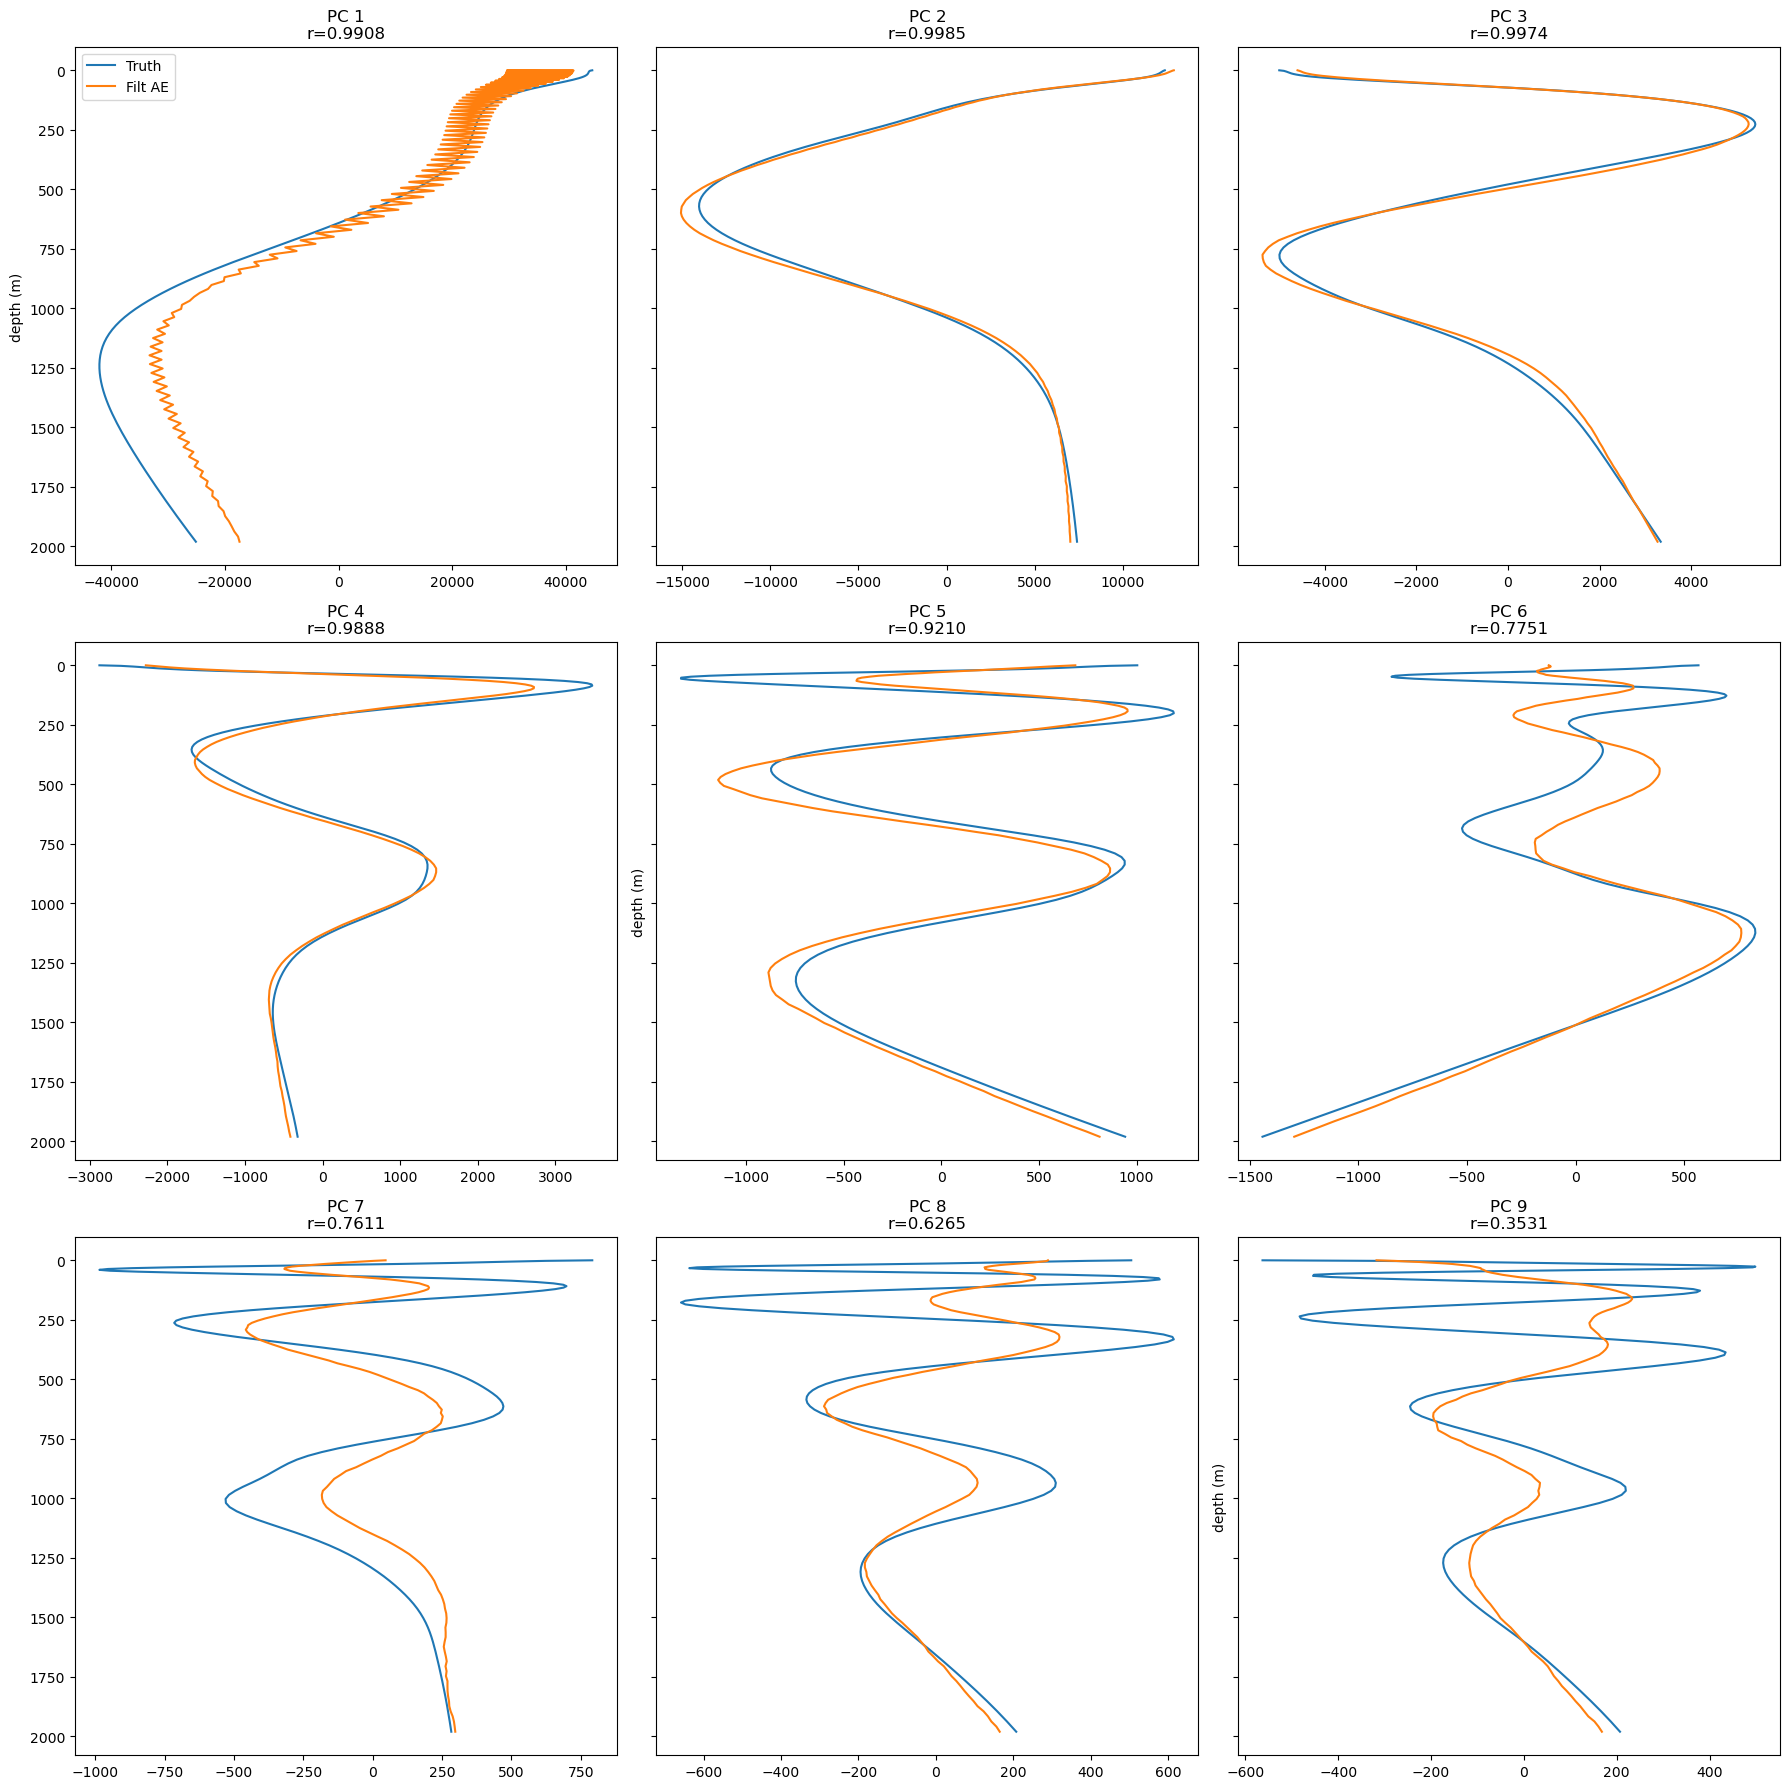

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(18, 18), sharey=True)
axs = axs.ravel()

n_plot = 9
n_available = truth_pca_prof.shape[1]

for i in range(n_plot):
    ax = axs[i]
    if i < n_available:
        ax.plot(truth_pca_prof[:, i], depth_array, label="Truth")
        ax.plot(filt_ae_pca_prof[:, i], depth_array, label="Filt AE")

        pears_i = pearsonr(truth_pca_prof[:, i], filt_ae_pca_prof[:, i])
        mse_i = np.mean((truth_pca_prof[:, i] - filt_ae_pca_prof[:, i]) ** 2)

        ax.set_title(f"PC {i+1}\nr={pears_i.statistic:.4f}")  #, MSE={mse_i:.2f}
    else:
        ax.axis("off")

    if i % 4 == 0:
        ax.set_ylabel("depth (m)")
    if i >= 12:
        ax.set_xlabel("PCA value")

axs[0].invert_yaxis()
axs[0].legend()
plt.tight_layout()
plt.show()


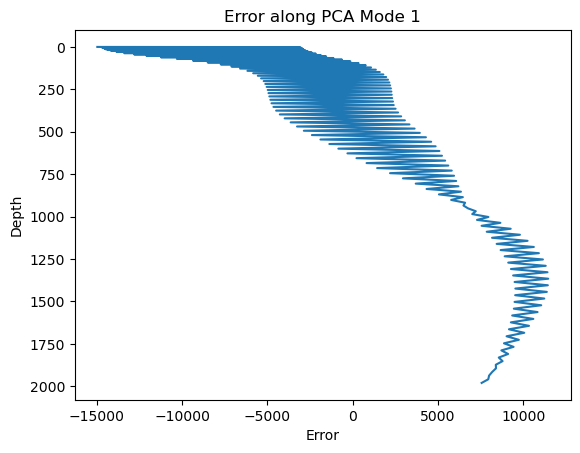

In [ ]:
error = ae_pca_prof - truth_pca_prof

plt.plot(error[:, 0], depth_array)
plt.gca().invert_yaxis()
plt.title("Error along PCA Mode 1")
plt.xlabel("Error")
plt.ylabel("Depth")
plt.show()

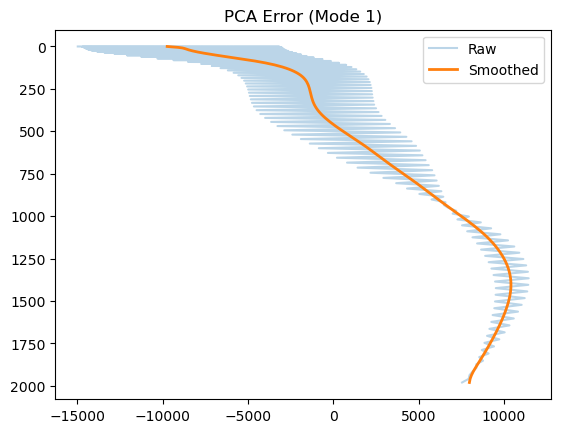

In [ ]:
from scipy.ndimage import gaussian_filter1d

error_mode1 = error[:, 0]

error_smooth = gaussian_filter1d(error_mode1, sigma=3)

plt.plot(error_mode1, depth_array, alpha=0.3, label="Raw")
plt.plot(error_smooth, depth_array, linewidth=2, label="Smoothed")

plt.gca().invert_yaxis()
plt.legend()
plt.title("PCA Error (Mode 1)")
plt.show()

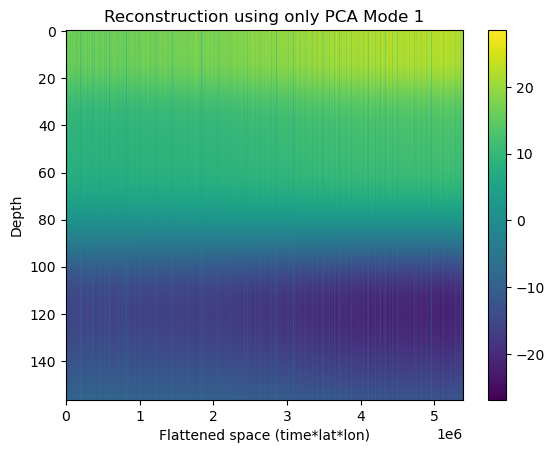

In [ ]:
# reconstruct using only mode 1
mode1 = pca.components_[0]

recon_mode1 = np.outer(truth_pca_prof[:, 0], mode1)

plt.imshow(recon_mode1, aspect='auto')
plt.colorbar()
plt.title("Reconstruction using only PCA Mode 1")
plt.xlabel("Flattened space (time*lat*lon)")
plt.ylabel("Depth")
plt.show()

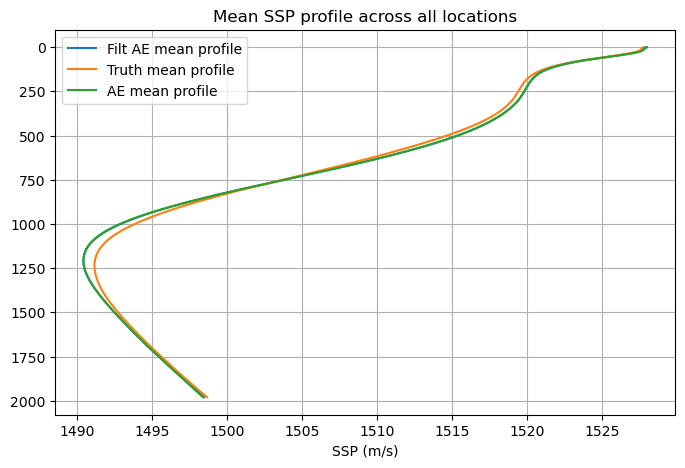

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(filt_ae.mean(axis=(0,2,3)), depth_array, label="Filt AE mean profile")
plt.plot(ssp_truth.mean(axis=(0,2,3)), depth_array, label="Truth mean profile")
plt.plot(ssp_ae.mean(axis=(0,2,3)), depth_array, label="AE mean profile")
plt.xlabel("SSP (m/s)")
plt.gca().invert_yaxis()  # Invert y-axis to have depth
plt.legend()
plt.title("Mean SSP profile across all locations")
plt.grid()
plt.show()

# Cluster

In [24]:


#data = []

# for t,lat,lon in zip(df_low_rmse.iloc[:]["time_idx"], df_low_rmse.iloc[:]["lat_idx"], df_low_rmse.iloc[:]["lon_idx"]):
#     profile = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
#     data.append(profile)



# # Remove profiles with NaNs
# valid_mask = ~np.isnan(profiles).any(axis=1)
# profiles_valid = profiles[valid_mask]

# Standardize profiles (important for shape-based clustering)
scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(ssp_truth_da.data.transpose(0,2,3,1).reshape(-1,ssp_truth_da.shape[1]))  # (n_profiles, depth)


# Fit with chosen k
k_opt = 10  # adjust based on elbow plot
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(profiles_scaled)

# Plot cluster centroids (mean profile shapes)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # back to original scale
depth = ssp_truth_da.z.values

plt.figure(figsize=(6, 8))
for i in range(k_opt):
    plt.plot(centroids[i], depth, label=f"Cluster {i+1} (n={np.sum(labels==i)})")
plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Cluster Centroids (Mean SSP per cluster)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [24]:
# Build dictionary of coordinates per cluster
shape_cluster_coords = {}
coords = [
    (int(t), int(lat), int(lon))
    for t in range(ssp_truth_da.sizes["time"])
    for lat in range(ssp_truth_da.sizes["lat"])
    for lon in range(ssp_truth_da.sizes["lon"])
]
assert len(coords) == len(labels), "Cluster labels length does not match number of profiles"
for label, coord in zip(labels, coords):
    shape_cluster_coords.setdefault(int(label) + 1, []).append(coord)

for cluster_id, pts in shape_cluster_coords.items():
    print(f"Cluster {cluster_id}: {len(pts)} profiles")



Cluster 6: 1078154 profiles
Cluster 1: 564196 profiles
Cluster 10: 683985 profiles
Cluster 7: 283018 profiles
Cluster 9: 282174 profiles
Cluster 5: 321756 profiles
Cluster 8: 682447 profiles
Cluster 2: 260501 profiles
Cluster 4: 769070 profiles
Cluster 3: 459147 profiles


In [25]:
import pickle

# Save shape_cluster_coords to pickle file
with open('/Odyssey/private/o23gauvr/code/FASCINATION/pickle/shape_cluster_coords.pkl', 'wb') as f:
    pickle.dump(shape_cluster_coords, f)

print(f"✓ Saved shape_cluster_coords to pickle file")
print(f"  Keys: {list(shape_cluster_coords.keys())}")

✓ Saved shape_cluster_coords to pickle file
  Keys: [6, 1, 10, 7, 9, 5, 8, 2, 4, 3]


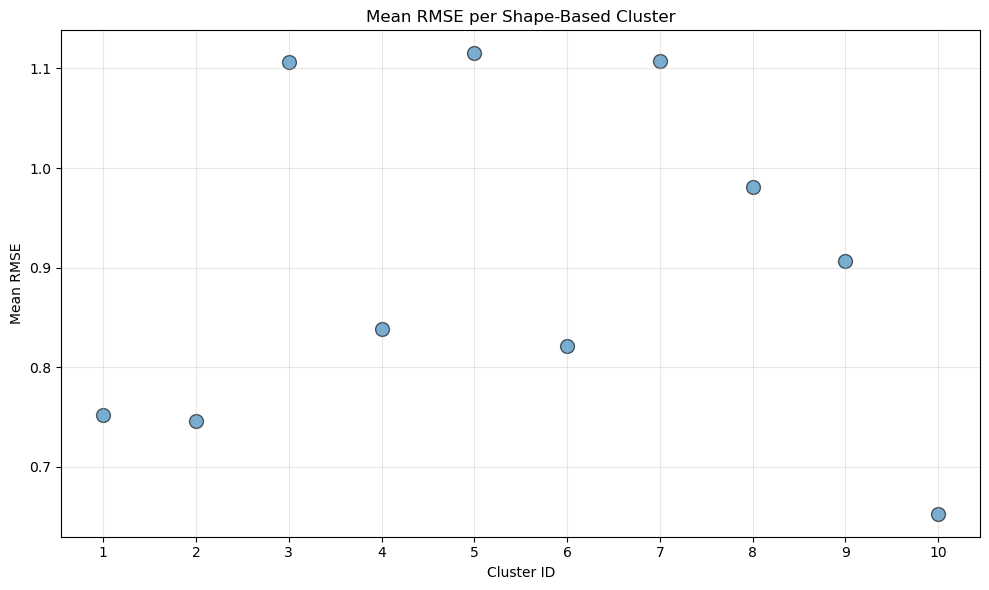

Cluster 10: Mean RMSE = 0.6526
Cluster 1: Mean RMSE = 0.7519
Cluster 2: Mean RMSE = 0.7457
Cluster 5: Mean RMSE = 1.1152
Cluster 7: Mean RMSE = 1.1079
Cluster 8: Mean RMSE = 0.9808
Cluster 6: Mean RMSE = 0.8209
Cluster 3: Mean RMSE = 1.1070
Cluster 4: Mean RMSE = 0.8386
Cluster 9: Mean RMSE = 0.9067


In [ ]:
# Calculate mean RMSE per cluster and create scatter plot
cluster_ids = []
mean_rmses = []

for cluster_id, coords_list in shape_cluster_coords.items():
    rmse_values = []
    for t, lat, lon in coords_list:
        # Extract RMSE value at this coordinate
        rmse_val = rmse_z.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(rmse_val):
            rmse_values.append(rmse_val)
    
    if len(rmse_values) > 0:
        mean_rmse = np.mean(rmse_values)
        cluster_ids.append(cluster_id)
        mean_rmses.append(mean_rmse)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_rmses, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean RMSE")
plt.title("Mean RMSE per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_rmses):
    print(f"Cluster {cid}: Mean RMSE = {mr:.4f}")

100%|██████████| 10/10 [08:30<00:00, 51.03s/it]


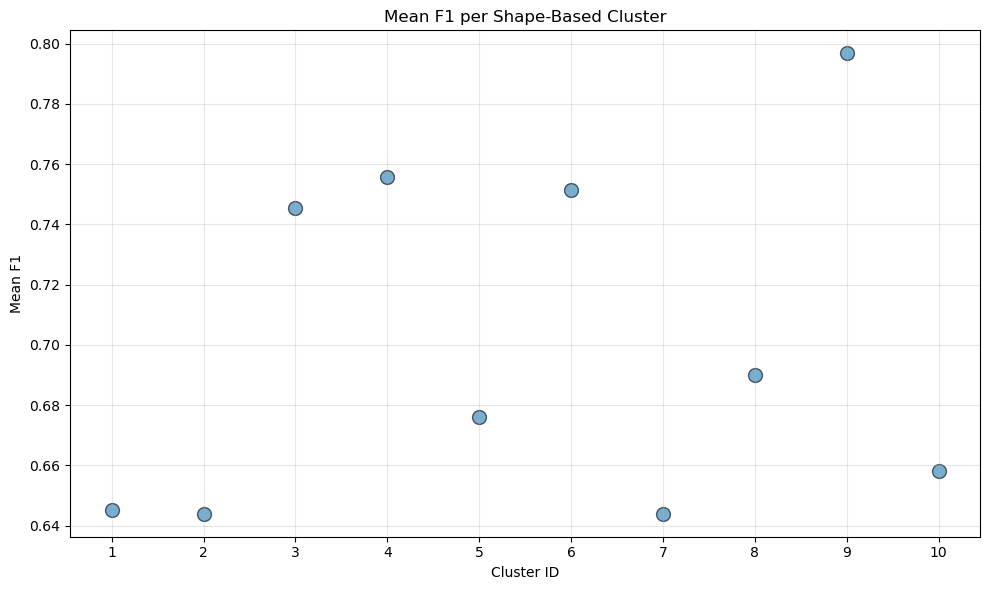

Cluster 10: Mean F1 = 0.6582
Cluster 1: Mean F1 = 0.6453
Cluster 2: Mean F1 = 0.6439
Cluster 5: Mean F1 = 0.6762
Cluster 7: Mean F1 = 0.6439
Cluster 8: Mean F1 = 0.6901
Cluster 6: Mean F1 = 0.7516
Cluster 3: Mean F1 = 0.7453
Cluster 4: Mean F1 = 0.7556
Cluster 9: Mean F1 = 0.7968


In [ ]:
# Calculate mean RMSE per cluster and create scatter plot
cluster_ids = []
mean_rmses = []

for cluster_id, coords_list in tqdm(shape_cluster_coords.items()):
    f1_values = []
    for t, lat, lon in coords_list:
        # Extract F1 value at this coordinate
        f1_val = f1_da.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(f1_val):
            f1_values.append(f1_val)
    
    if len(f1_values) > 0:
        mean_f1 = np.mean(f1_values)
        cluster_ids.append(cluster_id)
        mean_rmses.append(mean_f1)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_rmses, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean F1")
plt.title("Mean F1 per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_rmses):
    print(f"Cluster {cid}: Mean F1 = {mr:.4f}")

100%|██████████| 10/10 [08:38<00:00, 51.80s/it]


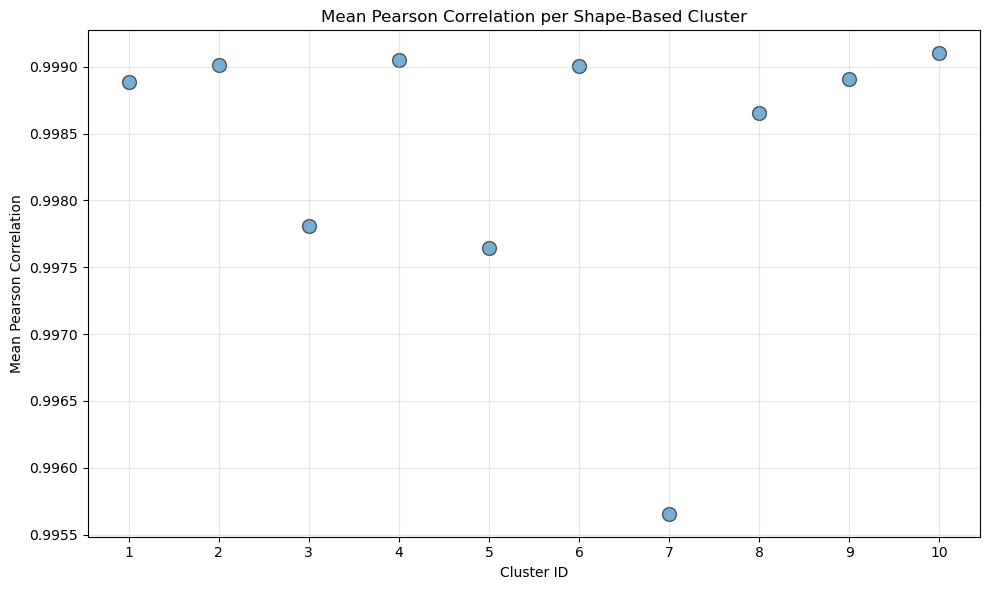

Cluster 10: Mean Pearson Correlation = 0.9991
Cluster 1: Mean Pearson Correlation = 0.9989
Cluster 2: Mean Pearson Correlation = 0.9990
Cluster 5: Mean Pearson Correlation = 0.9976
Cluster 7: Mean Pearson Correlation = 0.9957
Cluster 8: Mean Pearson Correlation = 0.9987
Cluster 6: Mean Pearson Correlation = 0.9990
Cluster 3: Mean Pearson Correlation = 0.9978
Cluster 4: Mean Pearson Correlation = 0.9990
Cluster 9: Mean Pearson Correlation = 0.9989


In [ ]:
# Calculate mean RMSE per cluster and create scatter plot
cluster_ids = []
mean_pearson_list = []

for cluster_id, coords_list in tqdm(shape_cluster_coords.items()):
    pearson_values = []
    for t, lat, lon in coords_list:
        # Extract Pearson correlation value at this coordinate
        pearson_val = pearson_da.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(pearson_val):
            pearson_values.append(pearson_val)

    if len(pearson_values) > 0:
        mean_pearson = np.mean(pearson_values)
        cluster_ids.append(cluster_id)
        mean_pearson_list.append(mean_pearson)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_pearson_list, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean Pearson Correlation")
plt.title("Mean Pearson Correlation per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_pearson_list):
    print(f"Cluster {cid}: Mean Pearson Correlation = {mr:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [09:15<00:00, 55.59s/it]


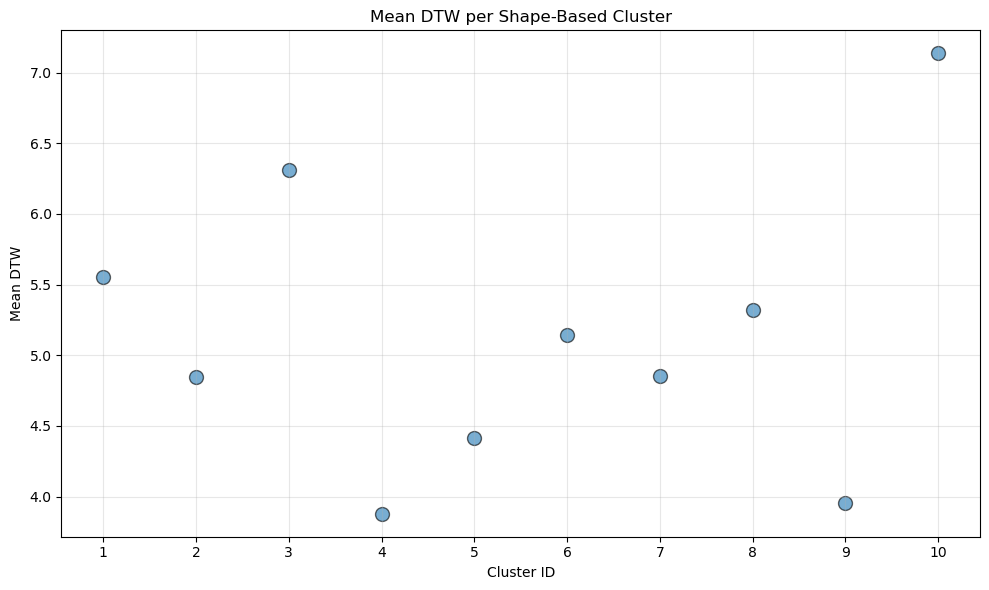

Cluster 4: Mean DTW = 3.8792
Cluster 9: Mean DTW = 3.9522
Cluster 7: Mean DTW = 4.8562
Cluster 1: Mean DTW = 5.5525
Cluster 10: Mean DTW = 7.1356
Cluster 6: Mean DTW = 5.1460
Cluster 5: Mean DTW = 4.4165
Cluster 3: Mean DTW = 6.3081
Cluster 2: Mean DTW = 4.8462
Cluster 8: Mean DTW = 5.3217


In [ ]:


# Calculate mean DTW per cluster and create scatter plot
cluster_ids = []
mean_dtw_list = []

for cluster_id, coords_list in tqdm(shape_cluster_coords.items()):
    dtw_values = []
    for t, lat, lon in coords_list:
        # Extract DTW value at this coordinate
        dtw_val = dtw_da.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(dtw_val):
            dtw_values.append(dtw_val)

    if len(dtw_values) > 0:
        mean_dtw = np.mean(dtw_values)
        cluster_ids.append(cluster_id)
        mean_dtw_list.append(mean_dtw)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_dtw_list, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean DTW")
plt.title("Mean DTW per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_dtw_list):
    print(f"Cluster {cid}: Mean DTW = {mr:.4f}")

100%|██████████| 10/10 [09:16<00:00, 55.66s/it]


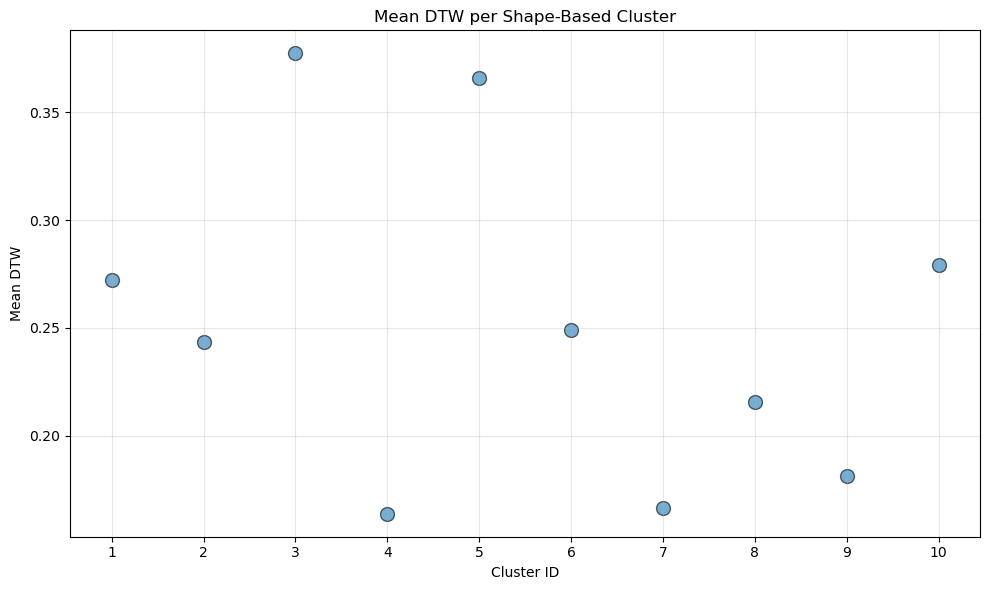

Cluster 4: Mean DTW = 0.1638
Cluster 9: Mean DTW = 0.1812
Cluster 7: Mean DTW = 0.1663
Cluster 1: Mean DTW = 0.2723
Cluster 10: Mean DTW = 0.2794
Cluster 6: Mean DTW = 0.2492
Cluster 5: Mean DTW = 0.3662
Cluster 3: Mean DTW = 0.3774
Cluster 2: Mean DTW = 0.2436
Cluster 8: Mean DTW = 0.2158


In [ ]:


# Calculate mean DTW per cluster and create scatter plot
cluster_ids = []
mean_dtw_dz_list = []

for cluster_id, coords_list in tqdm(shape_cluster_coords.items()):
    dtw_values = []
    for t, lat, lon in coords_list:
        # Extract DTW value at this coordinate
        dtw_dz_val = dtw_dz_da.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(dtw_dz_val):
            dtw_values.append(dtw_dz_val)

    if len(dtw_values) > 0:
        mean_dtw = np.mean(dtw_values)
        cluster_ids.append(cluster_id)
        mean_dtw_dz_list.append(mean_dtw)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_dtw_dz_list, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean DTW")
plt.title("Mean DTW per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_dtw_dz_list):
    print(f"Cluster {cid}: Mean DTW = {mr:.4f}")

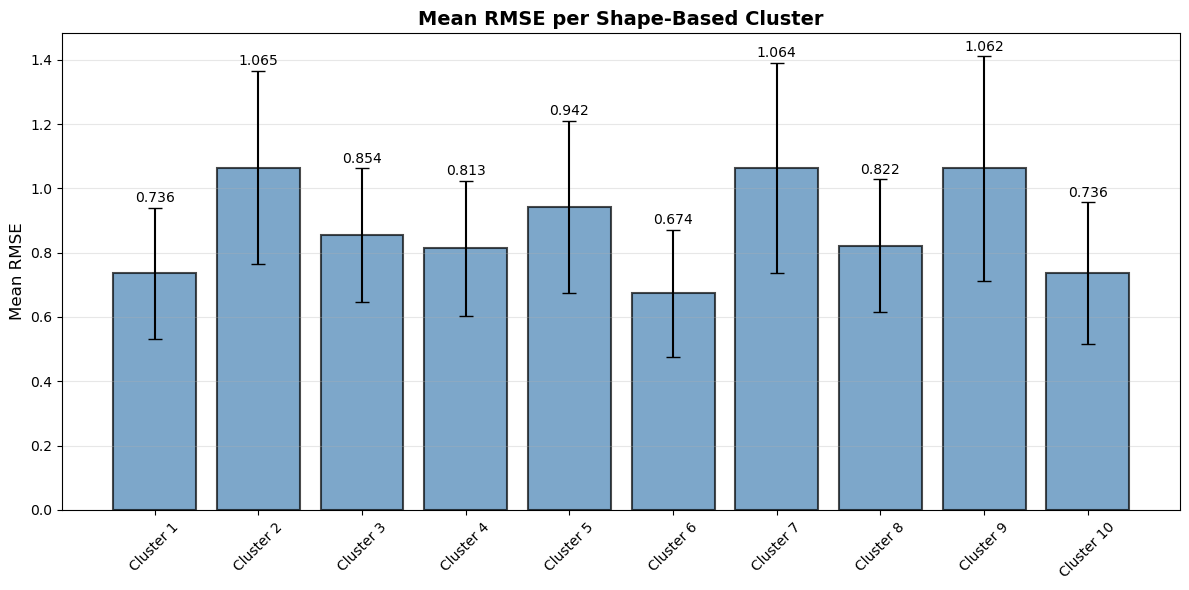

In [60]:

def plot_cluster_metric(shape_cluster_coords: dict, metric_da: xr.DataArray, title: str, ylabel: str):
    """
    Plot metric values per cluster defined by shape_cluster_coords.
    
    Args:
        shape_cluster_coords: dict with cluster_id -> list of (time, lat, lon) tuples
        metric_da: DataArray with shape (time, lat, lon)
        title: Plot title
        plot_path: Path to save plot
        ylabel: Label for y-axis
    """
    
    cluster_means = []
    cluster_stds = []
    cluster_ids = []
    
    for cluster_id, coords in shape_cluster_coords.items():
        # Extract values at cluster coordinates
        values = []
        for t, lat, lon in coords:
            try:
                val = metric_da.isel(time=t, lat=lat, lon=lon).values
                if np.isfinite(val).any():  # Only include finite values
                    if isinstance(val, np.ndarray):
                        values.extend(val[np.isfinite(val)])
                    else:
                        values.append(val)
            except (IndexError, KeyError):
                continue
        
        if values:
            cluster_means.append(np.nanmean(values))
            cluster_stds.append(np.nanstd(values))
            cluster_ids.append(cluster_id)

    cluster_df = pd.DataFrame({
        'cluster_id': cluster_ids,
        'mean': cluster_means,
        'std': cluster_stds
    })

    cluster_df = cluster_df.sort_values('cluster_id')
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(cluster_ids))
    
    ax.bar(cluster_df['cluster_id'], cluster_df['mean'], yerr=cluster_df['std'], capsize=5, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
    ax.set_xticks(cluster_df['cluster_id'])
    ax.set_xticklabels([f'Cluster {cid}' for cid in cluster_df['cluster_id']], rotation=45)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (mean, std) in enumerate(zip(cluster_df['mean'], cluster_df['std'])):
        ax.text(i+1, mean + std + 0.02*(max(cluster_df['mean'])-min(cluster_df['mean'])), 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plot_name = title.lower().replace(' ', '_').replace('/', '_') + '.png'
    plt.show()
    
    return cluster_df


df = plot_cluster_metric(shape_cluster_coords, rmse_z, title="Mean RMSE per Shape-Based Cluster", ylabel="Mean RMSE")

In [59]:
df

,cluster_id,mean,std
1,1,0.735904,0.203467
7,2,1.064703,0.300714
9,3,0.854016,0.208973
8,4,0.813249,0.210909
5,5,0.942360,0.268058
0,6,0.673644,0.197637
3,7,1.063709,0.326552
6,8,0.821777,0.205848
4,9,1.061824,0.349551
2,10,0.735776,0.220708


Text(0, 0.5, 'Mean RMSE')

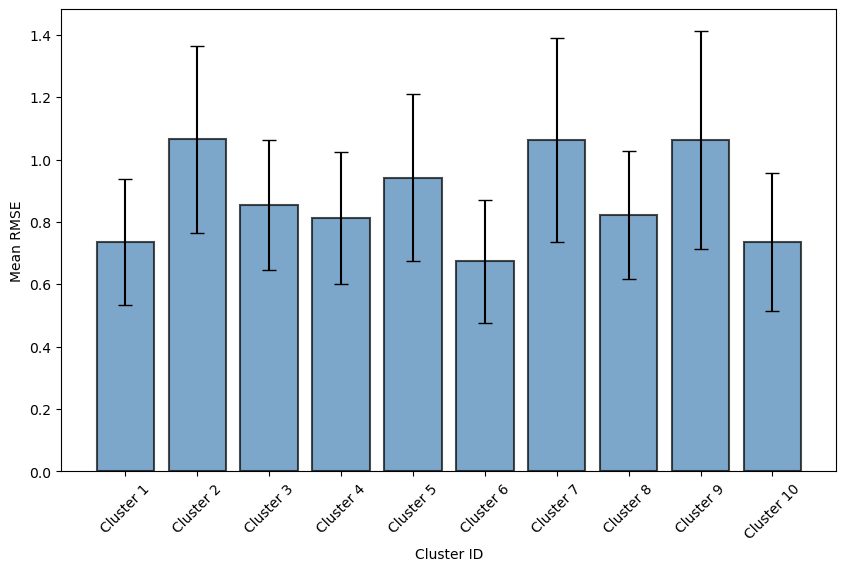

In [57]:
df = df.sort_values('cluster_id')
plt.figure(figsize=(10, 6))
plt.bar(df['cluster_id'], df['mean'], yerr=df['std'], capsize=5, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
plt.xticks(df['cluster_id'], [f'Cluster {cid}' for cid in df['cluster_id']], rotation=45)
plt.xlabel("Cluster ID")
plt.ylabel("Mean RMSE") 

100%|██████████| 10/10 [28:04<00:00, 168.48s/it]


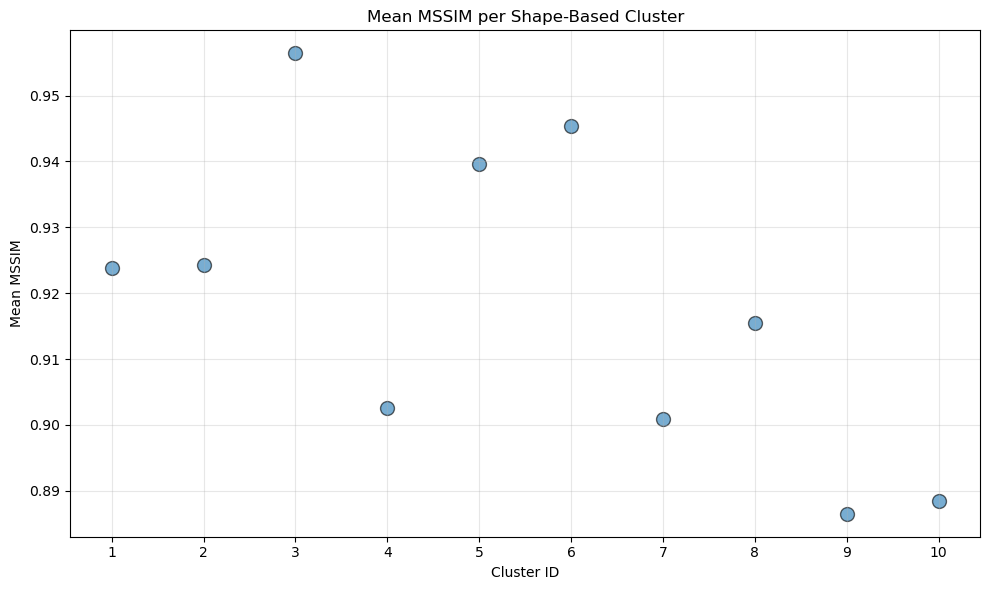

Cluster 4: Mean MSSIM = 0.9026
Cluster 9: Mean MSSIM = 0.8865
Cluster 7: Mean MSSIM = 0.9009
Cluster 1: Mean MSSIM = 0.9238
Cluster 10: Mean MSSIM = 0.8884
Cluster 6: Mean MSSIM = 0.9454
Cluster 5: Mean MSSIM = 0.9396
Cluster 3: Mean MSSIM = 0.9564
Cluster 2: Mean MSSIM = 0.9243
Cluster 8: Mean MSSIM = 0.9154


In [ ]:


# Calculate mean MSSIM per cluster and create scatter plot
cluster_ids = []
mean_mssim_list = []

for cluster_id, coords_list in tqdm(shape_cluster_coords.items()):
    mssim_values = []
    for t, lat, lon in coords_list:
        # Extract MSSIM value at this coordinate
        mssim_val = mssim_da.isel(time=t, lat=lat, lon=lon).values
        # Only include valid (non-NaN) values
        if np.isfinite(mssim_val):
            mssim_values.append(mssim_val)

    if len(mssim_values) > 0:
        mean_mssim = np.mean(mssim_values)
        cluster_ids.append(cluster_id)
        mean_mssim_list.append(mean_mssim)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(cluster_ids, mean_mssim_list, s=100, alpha=0.6, edgecolors='black')
plt.xlabel("Cluster ID")
plt.ylabel("Mean MSSIM")
plt.title("Mean MSSIM per Shape-Based Cluster")
plt.grid(alpha=0.3)
plt.xticks(cluster_ids)
plt.tight_layout()
plt.show()

# Print summary
for cid, mr in zip(cluster_ids, mean_mssim_list):
    print(f"Cluster {cid}: Mean MSSIM = {mr:.4f}")

=== Clustering by First Value (Surface SSP) ===
Cluster 5: 815117 profiles
Cluster 1: 599994 profiles
Cluster 3: 619582 profiles
Cluster 8: 151686 profiles
Cluster 9: 503611 profiles
Cluster 6: 68342 profiles
Cluster 4: 461619 profiles
Cluster 10: 511561 profiles
Cluster 2: 777638 profiles
Cluster 7: 875298 profiles


/tmp/ipykernel_1860326/1532796718.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


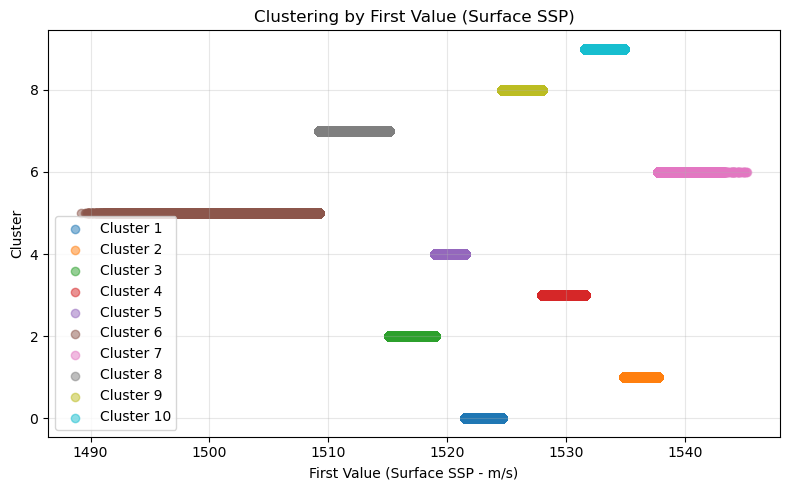

In [ ]:
# Cluster by first value (surface SSP)
profiles_flat = ssp_truth_da.data.transpose(0,2,3,1).reshape(-1, ssp_truth_da.shape[1])
first_values = profiles_flat[:, 0].reshape(-1, 1)  # First depth level for each profile

k_opt_first = 10
kmeans_first = KMeans(n_clusters=k_opt_first, random_state=42, n_init=10)
labels_first = kmeans_first.fit_predict(first_values)

# Build coordinates dictionary
cluster_coords_first = {}
for label, coord in zip(labels_first, coords):
    cluster_coords_first.setdefault(int(label) + 1, []).append(coord)

print("=== Clustering by First Value (Surface SSP) ===")
for cluster_id, pts in cluster_coords_first.items():
    print(f"Cluster {cluster_id}: {len(pts)} profiles")

# Plot
plt.figure(figsize=(8, 5))
for i in range(k_opt_first):
    mask = labels_first == i
    plt.scatter(first_values[mask], [i] * np.sum(mask), alpha=0.5, label=f"Cluster {i+1}")
plt.xlabel("First Value (Surface SSP - m/s)")
plt.ylabel("Cluster")
plt.title("Clustering by First Value (Surface SSP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

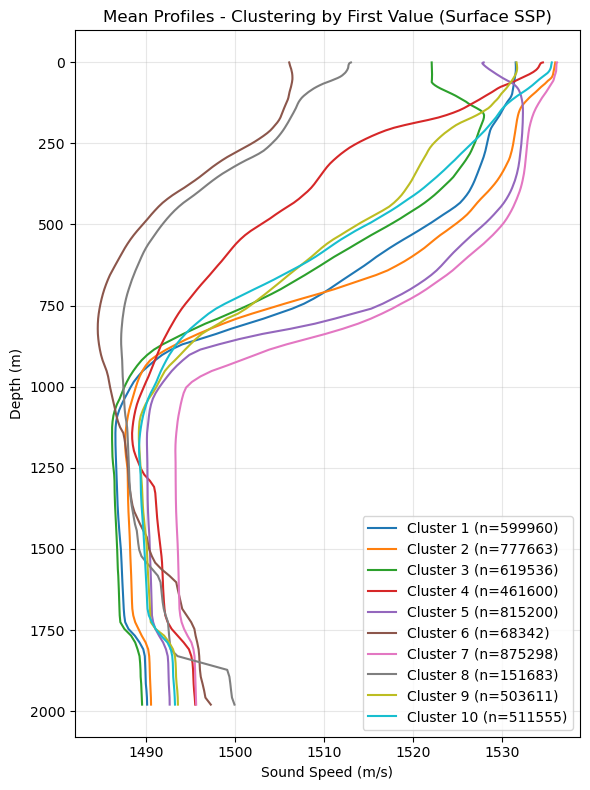

In [ ]:
plt.figure(figsize=(6, 8))
for i in range(k_opt_first):
    mask = labels_first == i
    cluster_profiles = profiles_flat[mask]
    mean_profile = cluster_profiles.mean(axis=0)
    plt.plot(mean_profile, depth, label=f"Cluster {i+1} (n={np.sum(mask)})")

plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Mean Profiles - Clustering by First Value (Surface SSP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Build dictionary of coordinates per cluster
surface_cluster_coords = {}
coords = [
    (int(t), int(lat), int(lon))
    for t in range(ssp_truth_da.sizes["time"])
    for lat in range(ssp_truth_da.sizes["lat"])
    for lon in range(ssp_truth_da.sizes["lon"])
]
assert len(coords) == len(labels_first), "Cluster labels length does not match number of profiles"
for label, coord in zip(labels_first, coords):
    surface_cluster_coords.setdefault(int(label) + 1, []).append(coord)

for cluster_id, pts in surface_cluster_coords.items():
    print(f"Cluster {cluster_id}: {len(pts)} profiles")



Cluster 5: 815200 profiles
Cluster 1: 599960 profiles
Cluster 3: 619536 profiles
Cluster 8: 151683 profiles
Cluster 9: 503611 profiles
Cluster 6: 68342 profiles
Cluster 4: 461600 profiles
Cluster 10: 511555 profiles
Cluster 2: 777663 profiles
Cluster 7: 875298 profiles


=== Clustering by Standard Deviation ===
Cluster 3: 724500 profiles
Cluster 6: 646715 profiles
Cluster 8: 1083648 profiles
Cluster 1: 638798 profiles
Cluster 9: 175020 profiles
Cluster 4: 104550 profiles
Cluster 10: 691760 profiles
Cluster 2: 664674 profiles
Cluster 7: 514765 profiles
Cluster 5: 140018 profiles


/tmp/ipykernel_493052/3822539638.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


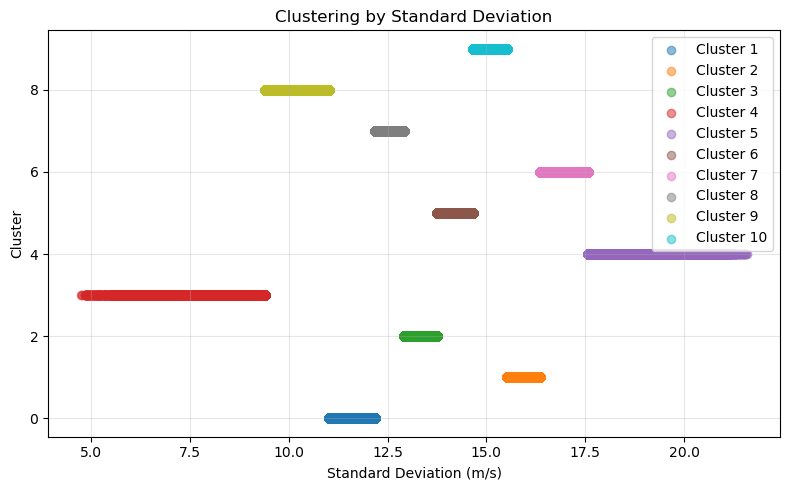

In [ ]:
# Cluster by standard deviation
std_values = profiles_flat.std(axis=1).reshape(-1, 1)  # Std for each profile

k_opt_std = 10
kmeans_std = KMeans(n_clusters=k_opt_std, random_state=42, n_init=10)
labels_std = kmeans_std.fit_predict(std_values)

# Build coordinates dictionary
cluster_coords_std = {}
for label, coord in zip(labels_std, coords):
    cluster_coords_std.setdefault(int(label) + 1, []).append(coord)

print("=== Clustering by Standard Deviation ===")
for cluster_id, pts in cluster_coords_std.items():
    print(f"Cluster {cluster_id}: {len(pts)} profiles")

# Plot
plt.figure(figsize=(8, 5))
for i in range(k_opt_std):
    mask = labels_std == i
    plt.scatter(std_values[mask], [i] * np.sum(mask), alpha=0.5, label=f"Cluster {i+1}")
plt.xlabel("Standard Deviation (m/s)")
plt.ylabel("Cluster")
plt.title("Clustering by Standard Deviation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

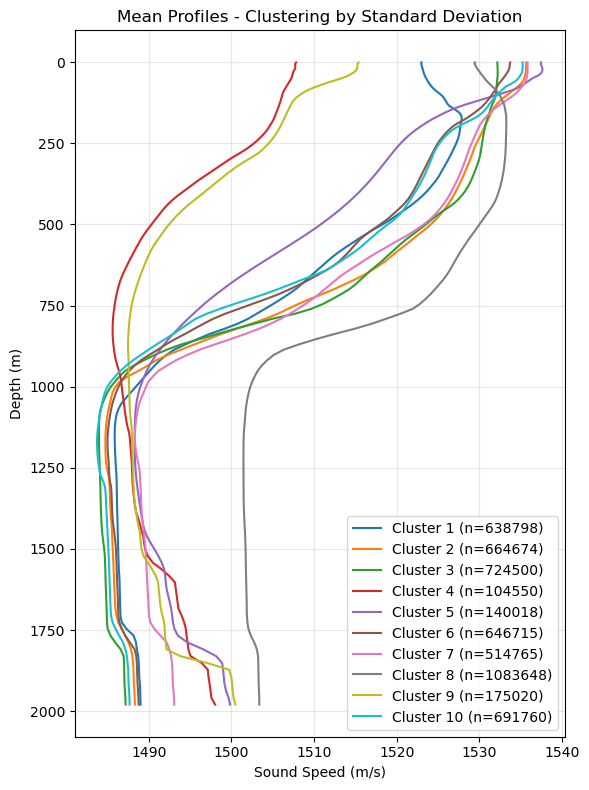

In [ ]:
plt.figure(figsize=(6, 8))
for i in range(k_opt_std):
    mask = labels_std == i
    cluster_profiles = profiles_flat[mask]
    mean_profile = cluster_profiles.mean(axis=0)
    plt.plot(mean_profile, depth, label=f"Cluster {i+1} (n={np.sum(mask)})")

plt.gca().invert_yaxis()
plt.xlabel("Sound Speed (m/s)")
plt.ylabel("Depth (m)")
plt.title("Mean Profiles - Clustering by Standard Deviation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Build dictionary of coordinates per cluster
std_cluster_coords = {}
coords = [
    (int(t), int(lat), int(lon))
    for t in range(ssp_truth_da.sizes["time"])
    for lat in range(ssp_truth_da.sizes["lat"])
    for lon in range(ssp_truth_da.sizes["lon"])
]
assert len(coords) == len(labels_std), "Cluster labels length does not match number of profiles"
for label, coord in zip(labels_std, coords):
    std_cluster_coords.setdefault(int(label) + 1, []).append(coord)

for cluster_id, pts in std_cluster_coords.items():
    print(f"Cluster {cluster_id}: {len(pts)} profiles")



Cluster 3: 724500 profiles
Cluster 6: 646715 profiles
Cluster 8: 1083648 profiles
Cluster 1: 638798 profiles
Cluster 9: 175020 profiles
Cluster 4: 104550 profiles
Cluster 10: 691760 profiles
Cluster 2: 664674 profiles
Cluster 7: 514765 profiles
Cluster 5: 140018 profiles


# Analysis

In [ ]:
# data = (ssp_truth_tens.detach().cpu().numpy().transpose(0,2,3,1).reshape(-1,len(depth_array)))  # shape: (n_samples, n_depths)
# data.shape

In [ ]:

# data = ssp_truth_tens.detach().cpu().numpy().transpose(0,2,3,1).reshape(-1,len(depth_array))  # shape: (n_samples, n_depths)

# # # Remove profiles with NaNs
# # valid_mask = ~np.isnan(profiles).any(axis=1)
# # profiles_valid = profiles[valid_mask]

# # Standardize profiles (important for shape-based clustering)
# scaler = StandardScaler()
# profiles_scaled = scaler.fit_transform(data)


# # Fit with chosen k
# k_opt = 4  # adjust based on elbow plot
# kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
# labels = kmeans.fit_predict(profiles_scaled)

# # Plot cluster centroids (mean profile shapes)
# centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # back to original scale
# depth = ssp_truth_da.z.values

# plt.figure(figsize=(6, 8))
# for i in range(k_opt):
#     plt.plot(centroids[i], depth, label=f"Cluster {i} (n={np.sum(labels==i)})")
# plt.gca().invert_yaxis()
# plt.xlabel("Sound Speed (m/s)")
# plt.ylabel("Depth (m)")
# plt.title("Cluster Centroids (Mean SSP per cluster)")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
# plt.figure(figsize=(6, 8))
# for i in range(k_opt):
#     plt.plot(unorm_ssp_arr_3D(centroids[i], test_norm), depth, label=f"Cluster {i} (n={np.sum(labels==i)})")
# plt.gca().invert_yaxis()
# plt.xlabel("Sound Speed (m/s)")
# plt.ylabel("Depth (m)")
# plt.title("Cluster Centroids (Mean SSP per cluster)")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
# fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# axs[0].plot(test_norm['params']['mean_along_depth'].squeeze(), depth)
# axs[1].plot(test_norm['params']['std_along_depth'].squeeze(), depth)

# axs[0].invert_yaxis()
# # axs[1].invert_yaxis()

# axs[0].set_xlabel("Mean Sound Speed (m/s)")
# axs[1].set_xlabel("Std Sound Speed (m/s)")
# axs[0].set_ylabel("Depth (m)")

# axs[0].set_title("Mean along depth used for normalization")
# axs[1].set_title("Std along depth used for normalization")

# # hide y-axis display on second subplot
# axs[1].tick_params(axis='y', which='both', left=False, labelleft=False)

# axs[0].grid(alpha=0.3)
# axs[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()